# Step 16 — Leakage-Safe Recursive XGBoost Forecasting

This notebook trains and evaluates XGBoost using five expanding walk-forward folds and a 28-day recursive forecasting horizon.

The implementation prevents target leakage by constructing test-period lag and rolling features only from:

- observed training sales; and
- predictions generated earlier within the same 28-day forecast horizon.

Actual test-period sales are used only after forecasting for evaluation.

The analysis is performed separately for smooth, erratic, intermittent and lumpy demand.

In [1]:
# Cell 1: Imports, reproducibility and project paths

from pathlib import Path
import importlib.metadata
import json
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Detect project root whether Jupyter was opened from the project root
# or directly from the notebooks folder.
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_RESULTS_DIR = OUTPUT_DIR / "model_results"
MODEL_DIR = PROJECT_ROOT / "models"

for directory in [
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_RESULTS_DIR,
    MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


def package_version(package_name: str) -> str:
    """Return an installed package version without failing the notebook."""
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "Not installed"


environment_info = {
    "project_root": str(PROJECT_ROOT),
    "python_seed": SEED,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "xgboost_version": package_version("xgboost"),
    "scikit_learn_version": package_version("scikit-learn"),
}

print("Step 16 environment")
print("-" * 60)

for key, value in environment_info.items():
    print(f"{key}: {value}")

Step 16 environment
------------------------------------------------------------
project_root: C:\Users\gamec\Documents\MSc_Dissertation_M5
python_seed: 42
pandas_version: 2.2.3
numpy_version: 2.1.3
xgboost_version: 3.3.0
scikit_learn_version: 1.6.1


In [2]:
# Cell 2: Inspect available processed datasets

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed-data directory was not found:\n{PROCESSED_DIR}"
    )

candidate_files = sorted(
    [
        path
        for path in PROCESSED_DIR.rglob("*")
        if path.is_file()
        and path.suffix.lower() in {".parquet", ".csv", ".pkl", ".pickle"}
    ]
)

print(f"Processed directory: {PROCESSED_DIR}")
print(f"Candidate files found: {len(candidate_files)}")
print("-" * 80)

for path in candidate_files:
    relative_path = path.relative_to(PROJECT_ROOT)
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{relative_path} | {size_mb:.3f} MB")

Processed directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\data\processed
Candidate files found: 31
--------------------------------------------------------------------------------
data\processed\category_by_demand_type.csv | 0.000 MB
data\processed\category_by_demand_type_percentage.csv | 0.000 MB
data\processed\demand_classification.csv | 4.228 MB
data\processed\demand_type_summary.csv | 0.000 MB
data\processed\m5_merged_base.parquet | 196.161 MB
data\processed\merged_by_store\CA_1_merged.parquet | 19.773 MB
data\processed\merged_by_store\CA_2_merged.parquet | 19.569 MB
data\processed\merged_by_store\CA_3_merged.parquet | 20.151 MB
data\processed\merged_by_store\CA_4_merged.parquet | 19.387 MB
data\processed\merged_by_store\TX_1_merged.parquet | 19.510 MB
data\processed\merged_by_store\TX_2_merged.parquet | 19.735 MB
data\processed\merged_by_store\TX_3_merged.parquet | 19.550 MB
data\processed\merged_by_store\WI_1_merged.parquet | 19.594 MB
data\processed\merged_by_store\WI_2_

In [3]:
# Cell 3: Install XGBoost into the active Jupyter environment

%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -- ------------------------------------- 3.7/69.5 MB 34.3 MB/s eta 0:00:02
   ------- -------------------------------- 13.6/69.5 MB 45.1 MB/s eta 0:00:02
   ------------- -------------------------- 23.9/69.5 MB 46.1 MB/s eta 0:00:01
   ------------------- -------------------- 33.8/69.5 MB 45.9 MB/s eta 0:00:01
   ------------------------- -------------- 43.5/69.5 MB 45.8 MB/s eta 0:00:01
   ------------------------------ --------- 53.5/69.5 MB 45.9 MB/s eta 0:00:01
   ------------------------------------ --- 63.2/69.5 MB 46.1 MB/s eta 0:00:01
   ---------------------------------------  69.5/69.5 MB 46.2 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 41.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 4: Verify XGBoost installation

import xgboost as xgb
from xgboost import XGBRegressor

print("XGBoost imported successfully.")
print(f"XGBoost version: {xgb.__version__}")
print(f"XGBRegressor available: {XGBRegressor is not None}")

XGBoost imported successfully.
XGBoost version: 3.3.0
XGBRegressor available: True


In [4]:
# Cell 5: Load the validated Step 14 modelling dataset

MODELLING_FILE = PROCESSED_DIR / "modelling_dataset.parquet"

if not MODELLING_FILE.exists():
    raise FileNotFoundError(
        f"Validated modelling dataset was not found:\n{MODELLING_FILE}"
    )

modelling_df = pd.read_parquet(MODELLING_FILE)

print("Validated modelling dataset loaded.")
print("-" * 60)
print(f"File: {MODELLING_FILE}")
print(f"Rows: {len(modelling_df):,}")
print(f"Columns: {modelling_df.shape[1]:,}")
print(f"Memory usage: {modelling_df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB")

Validated modelling dataset loaded.
------------------------------------------------------------
File: C:\Users\gamec\Documents\MSc_Dissertation_M5\data\processed\modelling_dataset.parquet
Rows: 1,552,800
Columns: 39
Memory usage: 385.54 MB


In [5]:
# Cell 6: Inspect modelling dataset schema

schema_table = pd.DataFrame(
    {
        "column": modelling_df.columns,
        "dtype": modelling_df.dtypes.astype(str).values,
        "missing_count": modelling_df.isna().sum().values,
        "missing_percentage": (
            modelling_df.isna().mean().values * 100
        ).round(4),
        "unique_values": [
            modelling_df[column].nunique(dropna=False)
            for column in modelling_df.columns
        ],
    }
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

display(schema_table)

,column,dtype,missing_count,missing_percentage,unique_values
0,id,category,0,0.0000,800
1,item_id,category,0,0.0000,574
2,dept_id,category,0,0.0000,7
3,cat_id,category,0,0.0000,3
4,store_id,category,0,0.0000,10
5,state_id,category,0,0.0000,3
6,d,object,0,0.0000,1941
7,sales,int32,0,0.0000,171
8,date,datetime64[ns],0,0.0000,1941
9,wm_yr_wk,int32,0,0.0000,278


In [6]:
# Cell 7: Identify important columns and inspect dataset coverage

possible_date_columns = [
    column
    for column in modelling_df.columns
    if "date" in column.lower()
]

possible_target_columns = [
    column
    for column in modelling_df.columns
    if column.lower() in {"sales", "demand", "target", "y"}
]

possible_series_columns = [
    column
    for column in modelling_df.columns
    if column.lower() in {
        "id",
        "series_id",
        "item_store_id",
        "unique_id",
    }
]

possible_demand_type_columns = [
    column
    for column in modelling_df.columns
    if "demand_type" in column.lower()
    or column.lower() == "demandtype"
]

print("Possible date columns:")
print(possible_date_columns)

print("\nPossible target columns:")
print(possible_target_columns)

print("\nPossible series identifier columns:")
print(possible_series_columns)

print("\nPossible demand-type columns:")
print(possible_demand_type_columns)

Possible date columns:
['date']

Possible target columns:
['sales']

Possible series identifier columns:
['id']

Possible demand-type columns:
['demand_type']


In [7]:
# Cell 8: Lock the experimental design, feature groups and fold dates

from pandas.api.types import is_numeric_dtype

# Recover the actual category labels while enforcing the intended order.
expected_demand_order = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]

actual_demand_values = (
    modelling_df["demand_type"]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

demand_value_lookup = {
    value.lower(): value
    for value in actual_demand_values
}

missing_demand_types = [
    demand_type
    for demand_type in expected_demand_order
    if demand_type not in demand_value_lookup
]

if missing_demand_types:
    raise ValueError(
        "Expected demand types were not found: "
        f"{missing_demand_types}\n"
        f"Available values: {actual_demand_values}"
    )

DEMAND_TYPES = [
    demand_value_lookup[demand_type]
    for demand_type in expected_demand_order
]

# Locked Step 14 feature groups
SALES_HISTORY_FEATURES = [
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_56",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_28",
    "rolling_std_28",
]

CALENDAR_FEATURES = [
    "is_weekend",
    "weekday",
    "month",
    "year",
]

EVENT_SNAP_FEATURES = [
    "event_flag",
    "event_type_encoded",
    "snap_flag",
]

PRICE_FEATURES = [
    "sell_price",
    "price_change",
    "price_vs_28d_avg",
]

MODEL_FEATURES = (
    SALES_HISTORY_FEATURES
    + CALENDAR_FEATURES
    + EVENT_SNAP_FEATURES
    + PRICE_FEATURES
)

TARGET_COLUMN = "sales"
SERIES_COLUMN = "id"
DATE_COLUMN = "date"
DEMAND_TYPE_COLUMN = "demand_type"

expected_feature_count = 18

missing_features = [
    feature
    for feature in MODEL_FEATURES
    if feature not in modelling_df.columns
]

if missing_features:
    raise ValueError(
        f"Required model features are missing: {missing_features}"
    )

if len(MODEL_FEATURES) != expected_feature_count:
    raise AssertionError(
        f"Expected {expected_feature_count} features, "
        f"but found {len(MODEL_FEATURES)}."
    )

non_numeric_features = [
    feature
    for feature in MODEL_FEATURES
    if not is_numeric_dtype(modelling_df[feature])
]

forbidden_model_columns = {
    TARGET_COLUMN,
    SERIES_COLUMN,
    DATE_COLUMN,
    DEMAND_TYPE_COLUMN,
    "d",
    "ADI",
    "CV2",
    "zero_rate",
}

forbidden_overlap = sorted(
    set(MODEL_FEATURES).intersection(forbidden_model_columns)
)

if forbidden_overlap:
    raise AssertionError(
        f"Forbidden columns entered the feature list: {forbidden_overlap}"
    )

# Outer walk-forward folds must match the verified baseline notebook.
FOLD_CONFIG = pd.DataFrame(
    [
        {
            "fold": 1,
            "outer_train_end": "2016-01-03",
            "outer_test_start": "2016-01-04",
            "outer_test_end": "2016-01-31",
        },
        {
            "fold": 2,
            "outer_train_end": "2016-01-31",
            "outer_test_start": "2016-02-01",
            "outer_test_end": "2016-02-28",
        },
        {
            "fold": 3,
            "outer_train_end": "2016-02-28",
            "outer_test_start": "2016-02-29",
            "outer_test_end": "2016-03-27",
        },
        {
            "fold": 4,
            "outer_train_end": "2016-03-27",
            "outer_test_start": "2016-03-28",
            "outer_test_end": "2016-04-24",
        },
        {
            "fold": 5,
            "outer_train_end": "2016-04-24",
            "outer_test_start": "2016-04-25",
            "outer_test_end": "2016-05-22",
        },
    ]
)

for date_column in [
    "outer_train_end",
    "outer_test_start",
    "outer_test_end",
]:
    FOLD_CONFIG[date_column] = pd.to_datetime(
        FOLD_CONFIG[date_column]
    )

# Reserve the final 28 training days for early stopping.
FOLD_CONFIG["inner_val_end"] = FOLD_CONFIG["outer_train_end"]

FOLD_CONFIG["inner_val_start"] = (
    FOLD_CONFIG["inner_val_end"]
    - pd.Timedelta(days=27)
)

FOLD_CONFIG["fit_train_end"] = (
    FOLD_CONFIG["inner_val_start"]
    - pd.Timedelta(days=1)
)

print("Locked Step 16 design")
print("-" * 70)
print(f"Demand types: {DEMAND_TYPES}")
print(f"Number of demand types: {len(DEMAND_TYPES)}")
print(f"Number of folds: {len(FOLD_CONFIG)}")
print(f"Models to be fitted: {len(DEMAND_TYPES) * len(FOLD_CONFIG)}")
print(f"Model features: {len(MODEL_FEATURES)}")
print(f"Non-numeric model features: {non_numeric_features}")
print(f"Forbidden feature overlap: {forbidden_overlap}")

feature_group_table = pd.DataFrame(
    {
        "feature_group": (
            ["Sales history"] * len(SALES_HISTORY_FEATURES)
            + ["Calendar"] * len(CALENDAR_FEATURES)
            + ["Event and SNAP"] * len(EVENT_SNAP_FEATURES)
            + ["Price"] * len(PRICE_FEATURES)
        ),
        "feature": MODEL_FEATURES,
    }
)

display(feature_group_table)
display(FOLD_CONFIG)

Locked Step 16 design
----------------------------------------------------------------------
Demand types: ['smooth', 'erratic', 'intermittent', 'lumpy']
Number of demand types: 4
Number of folds: 5
Models to be fitted: 20
Model features: 18
Non-numeric model features: []
Forbidden feature overlap: []


,feature_group,feature
0,Sales history,lag_7
1,Sales history,lag_14
2,Sales history,lag_28
3,Sales history,lag_56
4,Sales history,rolling_mean_7
5,Sales history,rolling_std_7
6,Sales history,rolling_mean_28
7,Sales history,rolling_std_28
8,Calendar,is_weekend
9,Calendar,weekday


,fold,outer_train_end,outer_test_start,outer_test_end,inner_val_end,inner_val_start,fit_train_end
0,1,2016-01-03,2016-01-04,2016-01-31,2016-01-03,2015-12-07,2015-12-06
1,2,2016-01-31,2016-02-01,2016-02-28,2016-01-31,2016-01-04,2016-01-03
2,3,2016-02-28,2016-02-29,2016-03-27,2016-02-28,2016-02-01,2016-01-31
3,4,2016-03-27,2016-03-28,2016-04-24,2016-03-27,2016-02-29,2016-02-28
4,5,2016-04-24,2016-04-25,2016-05-22,2016-04-24,2016-03-28,2016-03-27


In [8]:
# Cell 9: Validate series, dates, demand types and target integrity

model_df = (
    modelling_df
    .sort_values(
        [SERIES_COLUMN, DATE_COLUMN],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

duplicate_series_dates = model_df.duplicated(
    subset=[SERIES_COLUMN, DATE_COLUMN]
).sum()

series_row_counts = (
    model_df
    .groupby(SERIES_COLUMN, observed=True)
    .size()
)

series_unique_date_counts = (
    model_df
    .groupby(SERIES_COLUMN, observed=True)[DATE_COLUMN]
    .nunique()
)

demand_types_per_series = (
    model_df
    .groupby(SERIES_COLUMN, observed=True)[DEMAND_TYPE_COLUMN]
    .nunique()
)

series_demand_mapping = (
    model_df[
        [SERIES_COLUMN, DEMAND_TYPE_COLUMN]
    ]
    .drop_duplicates()
)

series_by_demand_type = (
    series_demand_mapping
    .groupby(DEMAND_TYPE_COLUMN, observed=True)
    .size()
    .reindex(DEMAND_TYPES)
)

total_unique_dates = model_df[DATE_COLUMN].nunique()
minimum_date = model_df[DATE_COLUMN].min()
maximum_date = model_df[DATE_COLUMN].max()
negative_sales_rows = int((model_df[TARGET_COLUMN] < 0).sum())
missing_sales_rows = int(model_df[TARGET_COLUMN].isna().sum())

print("Panel integrity audit")
print("-" * 70)
print(f"Rows: {len(model_df):,}")
print(f"Series: {model_df[SERIES_COLUMN].nunique():,}")
print(f"Unique dates: {total_unique_dates:,}")
print(f"Date range: {minimum_date.date()} to {maximum_date.date()}")
print(f"Duplicate series-date rows: {duplicate_series_dates:,}")
print(f"Minimum rows per series: {series_row_counts.min():,}")
print(f"Maximum rows per series: {series_row_counts.max():,}")
print(
    "Minimum unique dates per series: "
    f"{series_unique_date_counts.min():,}"
)
print(
    "Maximum unique dates per series: "
    f"{series_unique_date_counts.max():,}"
)
print(
    "Maximum demand types assigned to one series: "
    f"{demand_types_per_series.max():,}"
)
print(f"Missing sales rows: {missing_sales_rows:,}")
print(f"Negative sales rows: {negative_sales_rows:,}")

print("\nSeries by demand type:")
display(
    series_by_demand_type
    .rename("series_count")
    .reset_index()
)

assert len(model_df) == 1_552_800
assert model_df[SERIES_COLUMN].nunique() == 800
assert total_unique_dates == 1_941
assert duplicate_series_dates == 0
assert series_row_counts.min() == 1_941
assert series_row_counts.max() == 1_941
assert series_unique_date_counts.min() == 1_941
assert series_unique_date_counts.max() == 1_941
assert demand_types_per_series.max() == 1
assert missing_sales_rows == 0
assert negative_sales_rows == 0
assert (series_by_demand_type == 200).all()

print("\nAll panel integrity checks passed.")

Panel integrity audit
----------------------------------------------------------------------
Rows: 1,552,800
Series: 800
Unique dates: 1,941
Date range: 2011-01-29 to 2016-05-22
Duplicate series-date rows: 0
Minimum rows per series: 1,941
Maximum rows per series: 1,941
Minimum unique dates per series: 1,941
Maximum unique dates per series: 1,941
Maximum demand types assigned to one series: 1
Missing sales rows: 0
Negative sales rows: 0

Series by demand type:


,demand_type,series_count
0,smooth,200
1,erratic,200
2,intermittent,200
3,lumpy,200



All panel integrity checks passed.


In [9]:
# Cell 10: Audit lag and rolling-feature definitions

# Select three deterministic series from each demand type.
audit_series_ids = []

for demand_type in DEMAND_TYPES:
    type_ids = (
        series_demand_mapping.loc[
            series_demand_mapping[DEMAND_TYPE_COLUMN]
            == demand_type,
            SERIES_COLUMN,
        ]
        .astype(str)
        .sort_values()
        .head(3)
        .tolist()
    )

    audit_series_ids.extend(type_ids)

audit_df = (
    model_df.loc[
        model_df[SERIES_COLUMN]
        .astype(str)
        .isin(audit_series_ids)
    ]
    .copy()
    .sort_values([SERIES_COLUMN, DATE_COLUMN])
    .reset_index(drop=True)
)

def feature_difference_summary(
    stored: pd.Series,
    expected: pd.Series,
) -> dict:
    """Compare stored and independently reconstructed features."""

    stored_numeric = pd.to_numeric(stored, errors="coerce")
    expected_numeric = pd.to_numeric(expected, errors="coerce")

    nan_pattern_mismatches = int(
        (
            stored_numeric.isna()
            != expected_numeric.isna()
        ).sum()
    )

    valid_mask = (
        stored_numeric.notna()
        & expected_numeric.notna()
    )

    if valid_mask.any():
        max_absolute_difference = float(
            np.max(
                np.abs(
                    stored_numeric.loc[valid_mask].to_numpy()
                    - expected_numeric.loc[valid_mask].to_numpy()
                )
            )
        )
    else:
        max_absolute_difference = np.nan

    return {
        "compared_rows": int(valid_mask.sum()),
        "nan_pattern_mismatches": nan_pattern_mismatches,
        "max_absolute_difference": max_absolute_difference,
    }


audit_results = []

# Lag features
for lag in [7, 14, 28, 56]:
    feature_name = f"lag_{lag}"

    expected_values = (
        audit_df
        .groupby(SERIES_COLUMN, observed=True)[TARGET_COLUMN]
        .shift(lag)
    )

    result = feature_difference_summary(
        stored=audit_df[feature_name],
        expected=expected_values,
    )

    audit_results.append(
        {
            "feature": feature_name,
            "definition": f"sales shifted by {lag} days",
            **result,
        }
    )

# Shift sales once before calculating rolling statistics.
audit_df["_sales_shifted_1"] = (
    audit_df
    .groupby(SERIES_COLUMN, observed=True)[TARGET_COLUMN]
    .shift(1)
)

for window in [7, 28]:
    expected_mean = (
        audit_df
        .groupby(SERIES_COLUMN, observed=True)["_sales_shifted_1"]
        .transform(
            lambda series: series.rolling(
                window=window,
                min_periods=window,
            ).mean()
        )
    )

    mean_result = feature_difference_summary(
        stored=audit_df[f"rolling_mean_{window}"],
        expected=expected_mean,
    )

    audit_results.append(
        {
            "feature": f"rolling_mean_{window}",
            "definition": (
                f"shift(1), rolling({window}), mean"
            ),
            **mean_result,
        }
    )

    # Check both standard-deviation conventions.
    for degrees_of_freedom in [1, 0]:
        expected_std = (
            audit_df
            .groupby(
                SERIES_COLUMN,
                observed=True,
            )["_sales_shifted_1"]
            .transform(
                lambda series: series.rolling(
                    window=window,
                    min_periods=window,
                ).std(ddof=degrees_of_freedom)
            )
        )

        std_result = feature_difference_summary(
            stored=audit_df[f"rolling_std_{window}"],
            expected=expected_std,
        )

        audit_results.append(
            {
                "feature": f"rolling_std_{window}",
                "definition": (
                    f"shift(1), rolling({window}), "
                    f"std(ddof={degrees_of_freedom})"
                ),
                **std_result,
            }
        )

lag_rolling_audit = pd.DataFrame(audit_results)

print(f"Audit series: {len(audit_series_ids)}")
print(f"Audit rows: {len(audit_df):,}")

display(lag_rolling_audit)

Audit series: 12
Audit rows: 23,292


,feature,definition,compared_rows,nan_pattern_mismatches,max_absolute_difference
0,lag_7,sales shifted by 7 days,23208,0,0.000000e+00
1,lag_14,sales shifted by 14 days,23124,0,0.000000e+00
2,lag_28,sales shifted by 28 days,22956,0,0.000000e+00
3,lag_56,sales shifted by 56 days,22620,0,0.000000e+00
4,rolling_mean_7,"shift(1), rolling(7), mean",23208,0,1.634870e-06
5,rolling_std_7,"shift(1), rolling(7), std(ddof=1)",23208,0,1.686054e+00
6,rolling_std_7,"shift(1), rolling(7), std(ddof=0)",23208,0,8.984013e-07
7,rolling_mean_28,"shift(1), rolling(28), mean",22956,0,8.174351e-07
8,rolling_std_28,"shift(1), rolling(28), std(ddof=1)",22956,0,3.272622e-01
9,rolling_std_28,"shift(1), rolling(28), std(ddof=0)",22956,0,8.715972e-07


In [10]:
# Cell 11: Validate fold boundaries and row counts

fold_audit_records = []

complete_history_mask = (
    model_df[SALES_HISTORY_FEATURES]
    .notna()
    .all(axis=1)
)

for fold_row in FOLD_CONFIG.itertuples(index=False):
    fold_number = int(fold_row.fold)

    fit_train_end = pd.Timestamp(fold_row.fit_train_end)
    inner_val_start = pd.Timestamp(fold_row.inner_val_start)
    inner_val_end = pd.Timestamp(fold_row.inner_val_end)
    outer_test_start = pd.Timestamp(fold_row.outer_test_start)
    outer_test_end = pd.Timestamp(fold_row.outer_test_end)

    assert fit_train_end < inner_val_start
    assert inner_val_start <= inner_val_end
    assert inner_val_end < outer_test_start
    assert outer_test_start <= outer_test_end

    assert (
        inner_val_end - inner_val_start
    ).days + 1 == 28

    assert (
        outer_test_end - outer_test_start
    ).days + 1 == 28

    assert outer_test_start == inner_val_end + pd.Timedelta(days=1)

    for demand_type in DEMAND_TYPES:
        type_mask = (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )

        fit_mask = (
            type_mask
            & (model_df[DATE_COLUMN] <= fit_train_end)
            & complete_history_mask
        )

        validation_mask = (
            type_mask
            & model_df[DATE_COLUMN].between(
                inner_val_start,
                inner_val_end,
                inclusive="both",
            )
        )

        test_mask = (
            type_mask
            & model_df[DATE_COLUMN].between(
                outer_test_start,
                outer_test_end,
                inclusive="both",
            )
        )

        fit_rows = int(fit_mask.sum())
        validation_rows = int(validation_mask.sum())
        test_rows = int(test_mask.sum())

        validation_missing_history = int(
            model_df.loc[
                validation_mask,
                SALES_HISTORY_FEATURES,
            ]
            .isna()
            .any(axis=1)
            .sum()
        )

        test_missing_history = int(
            model_df.loc[
                test_mask,
                SALES_HISTORY_FEATURES,
            ]
            .isna()
            .any(axis=1)
            .sum()
        )

        fold_audit_records.append(
            {
                "fold": fold_number,
                "demand_type": demand_type,
                "fit_train_end": fit_train_end.date(),
                "inner_val_start": inner_val_start.date(),
                "inner_val_end": inner_val_end.date(),
                "outer_test_start": outer_test_start.date(),
                "outer_test_end": outer_test_end.date(),
                "fit_rows": fit_rows,
                "validation_rows": validation_rows,
                "test_rows": test_rows,
                "validation_missing_history": (
                    validation_missing_history
                ),
                "test_missing_history": test_missing_history,
            }
        )

fold_boundary_audit = pd.DataFrame(fold_audit_records)

display(fold_boundary_audit)

expected_validation_rows_per_type = 200 * 28
expected_test_rows_per_type = 200 * 28

assert (
    fold_boundary_audit["validation_rows"]
    == expected_validation_rows_per_type
).all()

assert (
    fold_boundary_audit["test_rows"]
    == expected_test_rows_per_type
).all()

assert (
    fold_boundary_audit["validation_missing_history"]
    == 0
).all()

assert (
    fold_boundary_audit["test_missing_history"]
    == 0
).all()

print("Fold-boundary checks passed.")
print(
    "Each demand type has "
    f"{expected_validation_rows_per_type:,} validation rows "
    "and "
    f"{expected_test_rows_per_type:,} test rows per fold."
)

,fold,demand_type,fit_train_end,inner_val_start,inner_val_end,outer_test_start,outer_test_end,fit_rows,validation_rows,test_rows,validation_missing_history,test_missing_history
0,1,smooth,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,343400,5600,5600,0,0
1,1,erratic,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,343400,5600,5600,0,0
2,1,intermittent,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,343400,5600,5600,0,0
3,1,lumpy,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,343400,5600,5600,0,0
4,2,smooth,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,349000,5600,5600,0,0
5,2,erratic,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,349000,5600,5600,0,0
6,2,intermittent,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,349000,5600,5600,0,0
7,2,lumpy,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,349000,5600,5600,0,0
8,3,smooth,2016-01-31,2016-02-01,2016-02-28,2016-02-29,2016-03-27,354600,5600,5600,0,0
9,3,erratic,2016-01-31,2016-02-01,2016-02-28,2016-02-29,2016-03-27,354600,5600,5600,0,0


Fold-boundary checks passed.
Each demand type has 5,600 validation rows and 5,600 test rows per fold.


In [11]:
 # Cell 12: Leakage-safe recursive forecasting engine

FORECAST_HORIZON = 28
HISTORY_LENGTH = 56

SCHEDULED_FEATURES = (
    CALENDAR_FEATURES
    + EVENT_SNAP_FEATURES
    + PRICE_FEATURES
)

assert len(SALES_HISTORY_FEATURES) == 8
assert len(SCHEDULED_FEATURES) == 10
assert len(MODEL_FEATURES) == 18
assert MODEL_FEATURES == SALES_HISTORY_FEATURES + SCHEDULED_FEATURES


def prepare_recursive_inputs(
    panel_df,
    demand_type,
    train_end,
    forecast_start,
    forecast_end,
):
    """
    Prepare the final 56 observed sales values and known future
    covariates for one demand type and one forecast window.

    Actual forecast-period sales are deliberately excluded.
    """

    train_end = pd.Timestamp(train_end)
    forecast_start = pd.Timestamp(forecast_start)
    forecast_end = pd.Timestamp(forecast_end)

    forecast_dates = pd.date_range(
        start=forecast_start,
        end=forecast_end,
        freq="D",
    )

    if len(forecast_dates) != FORECAST_HORIZON:
        raise ValueError(
            f"Expected {FORECAST_HORIZON} forecast dates, "
            f"but found {len(forecast_dates)}."
        )

    type_df = panel_df.loc[
        panel_df[DEMAND_TYPE_COLUMN] == demand_type
    ].copy()

    series_ids = sorted(
        type_df[SERIES_COLUMN]
        .astype(str)
        .unique()
        .tolist()
    )

    if len(series_ids) != 200:
        raise AssertionError(
            f"{demand_type}: expected 200 series, "
            f"but found {len(series_ids)}."
        )

    history_dates = pd.date_range(
        end=train_end,
        periods=HISTORY_LENGTH,
        freq="D",
    )

    history_slice = type_df.loc[
        type_df[DATE_COLUMN].isin(history_dates),
        [SERIES_COLUMN, DATE_COLUMN, TARGET_COLUMN],
    ].copy()

    history_slice["_series_id"] = (
        history_slice[SERIES_COLUMN].astype(str)
    )

    history_wide = (
        history_slice
        .pivot(
            index="_series_id",
            columns=DATE_COLUMN,
            values=TARGET_COLUMN,
        )
        .reindex(
            index=series_ids,
            columns=history_dates,
        )
    )

    if history_wide.shape != (200, HISTORY_LENGTH):
        raise AssertionError(
            f"Unexpected history shape: {history_wide.shape}"
        )

    if history_wide.isna().any().any():
        raise AssertionError(
            "Missing sales values were found in the "
            "56-day history matrix."
        )

    future_slice = type_df.loc[
        type_df[DATE_COLUMN].between(
            forecast_start,
            forecast_end,
            inclusive="both",
        ),
        [
            SERIES_COLUMN,
            DATE_COLUMN,
            *SCHEDULED_FEATURES,
        ],
    ].copy()

    future_slice["_series_id"] = (
        future_slice[SERIES_COLUMN].astype(str)
    )

    future_covariates = future_slice[
        [
            "_series_id",
            DATE_COLUMN,
            *SCHEDULED_FEATURES,
        ]
    ].copy()

    if TARGET_COLUMN in future_covariates.columns:
        raise AssertionError(
            "Forecast-period sales entered the future covariates."
        )

    if len(future_covariates) != 200 * FORECAST_HORIZON:
        raise AssertionError(
            f"Expected {200 * FORECAST_HORIZON:,} future rows, "
            f"but found {len(future_covariates):,}."
        )

    duplicate_future_rows = future_covariates.duplicated(
        subset=["_series_id", DATE_COLUMN]
    ).sum()

    if duplicate_future_rows != 0:
        raise AssertionError(
            f"Found {duplicate_future_rows} duplicate future rows."
        )

    history_values = history_wide.to_numpy(
        dtype=np.float64,
        copy=True,
    )

    return {
        "history_values": history_values,
        "history_dates": history_dates,
        "future_covariates": future_covariates,
        "forecast_dates": forecast_dates,
        "series_ids": series_ids,
    }


def recursive_forecast(
    model,
    history_values,
    future_covariates,
    forecast_dates,
    series_ids,
    keep_feature_trace=False,
):
    """
    Generate a fixed-origin recursive forecast.

    For each new day:
    1. Create lag and rolling features from available history.
    2. Predict all series for that day.
    3. Append those predictions to history.
    4. Use them when later forecast days require them.
    """

    rolling_history = np.asarray(
        history_values,
        dtype=np.float64,
    ).copy()

    if rolling_history.shape != (
        len(series_ids),
        HISTORY_LENGTH,
    ):
        raise AssertionError(
            f"Unexpected recursive history shape: "
            f"{rolling_history.shape}"
        )

    prediction_frames = []
    feature_trace_frames = []

    for horizon, forecast_date in enumerate(
        forecast_dates,
        start=1,
    ):
        day_covariates = (
            future_covariates.loc[
                future_covariates[DATE_COLUMN]
                == forecast_date
            ]
            .set_index("_series_id")
            .reindex(series_ids)
        )

        if len(day_covariates) != len(series_ids):
            raise AssertionError(
                f"Incorrect series count on {forecast_date.date()}."
            )

        history_features = pd.DataFrame(
            {
                "lag_7": rolling_history[:, -7],
                "lag_14": rolling_history[:, -14],
                "lag_28": rolling_history[:, -28],
                "lag_56": rolling_history[:, -56],
                "rolling_mean_7": (
                    rolling_history[:, -7:].mean(axis=1)
                ),
                "rolling_std_7": (
                    rolling_history[:, -7:].std(
                        axis=1,
                        ddof=0,
                    )
                ),
                "rolling_mean_28": (
                    rolling_history[:, -28:].mean(axis=1)
                ),
                "rolling_std_28": (
                    rolling_history[:, -28:].std(
                        axis=1,
                        ddof=0,
                    )
                ),
            },
            index=series_ids,
        )

        X_day = pd.concat(
            [
                history_features,
                day_covariates[SCHEDULED_FEATURES],
            ],
            axis=1,
        )[MODEL_FEATURES]

        if TARGET_COLUMN in X_day.columns:
            raise AssertionError(
                "Actual sales entered the recursive feature matrix."
            )

        if X_day[SALES_HISTORY_FEATURES].isna().any().any():
            raise AssertionError(
                f"Missing recursive sales-history features "
                f"at horizon {horizon}."
            )

        raw_predictions = np.asarray(
            model.predict(X_day),
            dtype=np.float64,
        ).reshape(-1)

        if len(raw_predictions) != len(series_ids):
            raise AssertionError(
                f"Expected {len(series_ids)} predictions, "
                f"but received {len(raw_predictions)}."
            )

        if not np.isfinite(raw_predictions).all():
            raise ValueError(
                f"Non-finite predictions occurred at "
                f"horizon {horizon}."
            )

        predictions = np.clip(
            raw_predictions,
            a_min=0.0,
            a_max=None,
        )

        prediction_frames.append(
            pd.DataFrame(
                {
                    SERIES_COLUMN: series_ids,
                    DATE_COLUMN: forecast_date,
                    "horizon": horizon,
                    "prediction": predictions,
                }
            )
        )

        if keep_feature_trace:
            trace = X_day.reset_index(
                names=SERIES_COLUMN
            )

            trace[DATE_COLUMN] = forecast_date
            trace["horizon"] = horizon

            feature_trace_frames.append(trace)

        rolling_history = np.concatenate(
            [
                rolling_history[:, 1:],
                predictions.reshape(-1, 1),
            ],
            axis=1,
        )

    prediction_df = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    if keep_feature_trace:
        feature_trace_df = pd.concat(
            feature_trace_frames,
            ignore_index=True,
        )
    else:
        feature_trace_df = None

    return prediction_df, feature_trace_df


print("Recursive forecasting engine defined.")
print(f"History retained: {HISTORY_LENGTH} days")
print(f"Forecast horizon: {FORECAST_HORIZON} days")
print(f"Recursive features: {len(SALES_HISTORY_FEATURES)}")
print(f"Scheduled features: {len(SCHEDULED_FEATURES)}")

Recursive forecasting engine defined.
History retained: 56 days
Forecast horizon: 28 days
Recursive features: 8
Scheduled features: 10


In [12]:
# Cell 13: Single-window recursive unit test

class LagSevenEchoModel:
    """Dummy model returning the recursively generated lag-7 feature."""

    def predict(self, X):
        return X["lag_7"].to_numpy(dtype=np.float64)


dummy_model = LagSevenEchoModel()

test_fold = FOLD_CONFIG.iloc[0]
test_demand_type = DEMAND_TYPES[0]

single_test_inputs = prepare_recursive_inputs(
    panel_df=model_df,
    demand_type=test_demand_type,
    train_end=test_fold["outer_train_end"],
    forecast_start=test_fold["outer_test_start"],
    forecast_end=test_fold["outer_test_end"],
)

single_test_predictions, single_feature_trace = (
    recursive_forecast(
        model=dummy_model,
        history_values=single_test_inputs[
            "history_values"
        ],
        future_covariates=single_test_inputs[
            "future_covariates"
        ],
        forecast_dates=single_test_inputs[
            "forecast_dates"
        ],
        series_ids=single_test_inputs[
            "series_ids"
        ],
        keep_feature_trace=True,
    )
)

last_seven_actuals = single_test_inputs[
    "history_values"
][:, -7:]

expected_prediction_arrays = []

for horizon in range(1, FORECAST_HORIZON + 1):
    expected_prediction_arrays.append(
        last_seven_actuals[
            :,
            (horizon - 1) % 7,
        ]
    )

expected_predictions = np.concatenate(
    expected_prediction_arrays
)

maximum_prediction_difference = float(
    np.max(
        np.abs(
            single_test_predictions[
                "prediction"
            ].to_numpy()
            - expected_predictions
        )
    )
)

print("Single-window recursive test")
print("-" * 70)
print(f"Demand type: {test_demand_type}")
print(f"Fold: {int(test_fold['fold'])}")
print(
    f"Forecast origin: "
    f"{test_fold['outer_train_end'].date()}"
)
print(
    f"Prediction rows: "
    f"{len(single_test_predictions):,}"
)
print(
    f"Unique series: "
    f"{single_test_predictions[SERIES_COLUMN].nunique():,}"
)
print(
    f"Unique horizons: "
    f"{single_test_predictions['horizon'].nunique():,}"
)
print(
    f"Maximum difference from fixed-origin lag-7: "
    f"{maximum_prediction_difference:.12f}"
)
print(
    f"Negative predictions: "
    f"{(single_test_predictions['prediction'] < 0).sum():,}"
)
print(
    "Target present in future covariates: "
    f"{TARGET_COLUMN in single_test_inputs['future_covariates'].columns}"
)

assert len(single_test_predictions) == 5_600
assert (
    single_test_predictions[SERIES_COLUMN].nunique()
    == 200
)
assert (
    single_test_predictions["horizon"].nunique()
    == 28
)
assert maximum_prediction_difference == 0.0
assert (
    single_test_predictions["prediction"] < 0
).sum() == 0
assert (
    TARGET_COLUMN
    not in single_test_inputs[
        "future_covariates"
    ].columns
)

print("\nSingle-window recursive test passed.")

Single-window recursive test
----------------------------------------------------------------------
Demand type: smooth
Fold: 1
Forecast origin: 2016-01-03
Prediction rows: 5,600
Unique series: 200
Unique horizons: 28
Maximum difference from fixed-origin lag-7: 0.000000000000
Negative predictions: 0
Target present in future covariates: False

Single-window recursive test passed.


In [13]:
# Cell 14: Compare horizon-1 features with stored Step 14 features

first_forecast_date = pd.Timestamp(
    test_fold["outer_test_start"]
)

trace_day_one = single_feature_trace.loc[
    single_feature_trace["horizon"] == 1,
    [
        SERIES_COLUMN,
        DATE_COLUMN,
        *SALES_HISTORY_FEATURES,
    ],
].copy()

stored_day_one = model_df.loc[
    (
        model_df[DEMAND_TYPE_COLUMN]
        == test_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        == first_forecast_date
    ),
    [
        SERIES_COLUMN,
        DATE_COLUMN,
        *SALES_HISTORY_FEATURES,
    ],
].copy()

trace_day_one[SERIES_COLUMN] = (
    trace_day_one[SERIES_COLUMN].astype(str)
)

stored_day_one[SERIES_COLUMN] = (
    stored_day_one[SERIES_COLUMN].astype(str)
)

day_one_comparison = trace_day_one.merge(
    stored_day_one,
    on=[SERIES_COLUMN, DATE_COLUMN],
    how="inner",
    suffixes=("_recursive", "_stored"),
    validate="one_to_one",
)

day_one_audit_records = []

for feature in SALES_HISTORY_FEATURES:
    recursive_values = day_one_comparison[
        f"{feature}_recursive"
    ].to_numpy(dtype=np.float64)

    stored_values = day_one_comparison[
        f"{feature}_stored"
    ].to_numpy(dtype=np.float64)

    maximum_difference = float(
        np.max(
            np.abs(
                recursive_values - stored_values
            )
        )
    )

    day_one_audit_records.append(
        {
            "feature": feature,
            "compared_rows": len(day_one_comparison),
            "maximum_absolute_difference": (
                maximum_difference
            ),
        }
    )

day_one_feature_audit = pd.DataFrame(
    day_one_audit_records
)

display(day_one_feature_audit)

assert len(day_one_comparison) == 200

assert (
    day_one_feature_audit[
        "maximum_absolute_difference"
    ]
    < 1e-5
).all()

print("Horizon-1 feature reconstruction passed.")

,feature,compared_rows,maximum_absolute_difference
0,lag_7,200,0.000000e+00
1,lag_14,200,0.000000e+00
2,lag_28,200,0.000000e+00
3,lag_56,200,0.000000e+00
4,rolling_mean_7,200,1.634870e-06
5,rolling_std_7,200,3.017944e-07
6,rolling_mean_28,200,1.089914e-06
7,rolling_std_28,200,5.270931e-07


Horizon-1 feature reconstruction passed.


In [16]:
# Cell 15: Full recursive-engine audit across all 40 windows

recursive_audit_records = []

window_definitions = {
    "inner_validation": {
        "train_end_column": "fit_train_end",
        "forecast_start_column": "inner_val_start",
        "forecast_end_column": "inner_val_end",
    },
    "outer_test": {
        "train_end_column": "outer_train_end",
        "forecast_start_column": "outer_test_start",
        "forecast_end_column": "outer_test_end",
    },
}

for fold_row in FOLD_CONFIG.itertuples(index=False):
    for demand_type in DEMAND_TYPES:
        for window_name, columns in window_definitions.items():
            train_end = getattr(
                fold_row,
                columns["train_end_column"],
            )

            forecast_start = getattr(
                fold_row,
                columns["forecast_start_column"],
            )

            forecast_end = getattr(
                fold_row,
                columns["forecast_end_column"],
            )

            recursive_inputs = prepare_recursive_inputs(
                panel_df=model_df,
                demand_type=demand_type,
                train_end=train_end,
                forecast_start=forecast_start,
                forecast_end=forecast_end,
            )

            predictions, _ = recursive_forecast(
                model=dummy_model,
                history_values=recursive_inputs[
                    "history_values"
                ],
                future_covariates=recursive_inputs[
                    "future_covariates"
                ],
                forecast_dates=recursive_inputs[
                    "forecast_dates"
                ],
                series_ids=recursive_inputs[
                    "series_ids"
                ],
                keep_feature_trace=False,
            )

            last_seven = recursive_inputs[
                "history_values"
            ][:, -7:]

            expected = np.concatenate(
                [
                    last_seven[
                        :,
                        (horizon - 1) % 7,
                    ]
                    for horizon in range(
                        1,
                        FORECAST_HORIZON + 1,
                    )
                ]
            )

            maximum_difference = float(
                np.max(
                    np.abs(
                        predictions[
                            "prediction"
                        ].to_numpy()
                        - expected
                    )
                )
            )

            recursive_audit_records.append(
                {
                    "fold": int(fold_row.fold),
                    "demand_type": demand_type,
                    "window": window_name,
                    "train_end": pd.Timestamp(
                        train_end
                    ).date(),
                    "forecast_start": pd.Timestamp(
                        forecast_start
                    ).date(),
                    "forecast_end": pd.Timestamp(
                        forecast_end
                    ).date(),
                    "prediction_rows": len(
                        predictions
                    ),
                    "series_count": predictions[
                        SERIES_COLUMN
                    ].nunique(),
                    "horizon_count": predictions[
                        "horizon"
                    ].nunique(),
                    "maximum_lag7_difference": (
                        maximum_difference
                    ),
                    "non_finite_predictions": int(
                        np.count_nonzero(
                             ~np.isfinite(
                                 predictions["prediction"].to_numpy()
        )
    )
),
                    "negative_predictions": int(
                        (
                            predictions[
                                "prediction"
                            ]
                            < 0
                        ).sum()
                    ),
                }
            )

recursive_engine_audit = pd.DataFrame(
    recursive_audit_records
)

display(recursive_engine_audit)

assert len(recursive_engine_audit) == 40

assert (
    recursive_engine_audit[
        "prediction_rows"
    ] == 5_600
).all()

assert (
    recursive_engine_audit[
        "series_count"
    ] == 200
).all()

assert (
    recursive_engine_audit[
        "horizon_count"
    ] == 28
).all()

assert (
    recursive_engine_audit[
        "maximum_lag7_difference"
    ] == 0.0
).all()

assert (
    recursive_engine_audit[
        "non_finite_predictions"
    ] == 0
).all()

assert (
    recursive_engine_audit[
        "negative_predictions"
    ] == 0
).all()

print("\nFull recursive-engine audit passed.")
print(
    f"Windows checked: "
    f"{len(recursive_engine_audit):,}"
)
print(
    "Total dummy predictions checked: "
    f"{recursive_engine_audit['prediction_rows'].sum():,}"
)

,fold,demand_type,window,train_end,forecast_start,forecast_end,prediction_rows,series_count,horizon_count,maximum_lag7_difference,non_finite_predictions,negative_predictions
0,1,smooth,inner_validation,2015-12-06,2015-12-07,2016-01-03,5600,200,28,0.0,0,0
1,1,smooth,outer_test,2016-01-03,2016-01-04,2016-01-31,5600,200,28,0.0,0,0
2,1,erratic,inner_validation,2015-12-06,2015-12-07,2016-01-03,5600,200,28,0.0,0,0
3,1,erratic,outer_test,2016-01-03,2016-01-04,2016-01-31,5600,200,28,0.0,0,0
4,1,intermittent,inner_validation,2015-12-06,2015-12-07,2016-01-03,5600,200,28,0.0,0,0
5,1,intermittent,outer_test,2016-01-03,2016-01-04,2016-01-31,5600,200,28,0.0,0,0
6,1,lumpy,inner_validation,2015-12-06,2015-12-07,2016-01-03,5600,200,28,0.0,0,0
7,1,lumpy,outer_test,2016-01-03,2016-01-04,2016-01-31,5600,200,28,0.0,0,0
8,2,smooth,inner_validation,2016-01-03,2016-01-04,2016-01-31,5600,200,28,0.0,0,0
9,2,smooth,outer_test,2016-01-31,2016-02-01,2016-02-28,5600,200,28,0.0,0,0



Full recursive-engine audit passed.
Windows checked: 40
Total dummy predictions checked: 224,000


In [17]:
# Cell 16: Compact final verification of the recursive engine

expected_window_count = 5 * 4 * 2
expected_total_predictions = expected_window_count * 5_600

recursive_engine_checks = {
    "40 forecast windows created": (
        len(recursive_engine_audit) == expected_window_count
    ),
    "5,600 predictions in every window": (
        recursive_engine_audit["prediction_rows"] == 5_600
    ).all(),
    "200 series in every window": (
        recursive_engine_audit["series_count"] == 200
    ).all(),
    "28 horizons in every window": (
        recursive_engine_audit["horizon_count"] == 28
    ).all(),
    "Exact fixed-origin lag-7 reproduction": (
        recursive_engine_audit["maximum_lag7_difference"] == 0.0
    ).all(),
    "No non-finite predictions": (
        recursive_engine_audit["non_finite_predictions"] == 0
    ).all(),
    "No negative predictions": (
        recursive_engine_audit["negative_predictions"] == 0
    ).all(),
}

recursive_engine_check_table = pd.DataFrame(
    {
        "check": recursive_engine_checks.keys(),
        "passed": recursive_engine_checks.values(),
    }
)

display(recursive_engine_check_table)

compact_window_summary = (
    recursive_engine_audit
    .groupby("window", observed=True)
    .agg(
        windows=("fold", "size"),
        total_predictions=("prediction_rows", "sum"),
        minimum_series_count=("series_count", "min"),
        maximum_series_count=("series_count", "max"),
        minimum_horizon_count=("horizon_count", "min"),
        maximum_horizon_count=("horizon_count", "max"),
        maximum_lag7_difference=(
            "maximum_lag7_difference",
            "max",
        ),
        non_finite_predictions=(
            "non_finite_predictions",
            "sum",
        ),
        negative_predictions=(
            "negative_predictions",
            "sum",
        ),
    )
    .reset_index()
)

display(compact_window_summary)

failed_checks = [
    check
    for check, passed in recursive_engine_checks.items()
    if not passed
]

if failed_checks:
    raise AssertionError(
        "Recursive-engine audit failed:\n- "
        + "\n- ".join(failed_checks)
    )

actual_total_predictions = int(
    recursive_engine_audit["prediction_rows"].sum()
)

assert actual_total_predictions == expected_total_predictions

print("Full recursive-engine audit passed.")
print(f"Windows checked: {len(recursive_engine_audit):,}")
print(
    "Total dummy predictions checked: "
    f"{actual_total_predictions:,}"
)

,check,passed
0,40 forecast windows created,True
1,"5,600 predictions in every window",True
2,200 series in every window,True
3,28 horizons in every window,True
4,Exact fixed-origin lag-7 reproduction,True
5,No non-finite predictions,True
6,No negative predictions,True


,window,windows,total_predictions,minimum_series_count,maximum_series_count,minimum_horizon_count,maximum_horizon_count,maximum_lag7_difference,non_finite_predictions,negative_predictions
0,inner_validation,20,112000,200,200,28,28,0.0,0,0
1,outer_test,20,112000,200,200,28,28,0.0,0,0


Full recursive-engine audit passed.
Windows checked: 40
Total dummy predictions checked: 224,000


In [18]:
# Cell 17: Lock the initial XGBoost pilot configuration

import time
from sklearn.metrics import mean_absolute_error, mean_squared_error

N_THREADS = max(
    1,
    min(8, os.cpu_count() or 1),
)

PILOT_MAX_ROUNDS = 200

PILOT_CHECKPOINTS = [
    25,
    50,
    75,
    100,
    125,
    150,
    175,
    200,
]

XGB_PARAMS = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": 1.5,
    "eval_metric": "tweedie-nloglik",
    "booster": "gbtree",
    "tree_method": "hist",
    "device": "cpu",
    "eta": 0.05,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "max_bin": 256,
    "seed": SEED,
    "seed_per_iteration": True,
    "nthread": N_THREADS,
    "verbosity": 0,
}

print("Initial XGBoost pilot configuration")
print("-" * 70)

for parameter, value in XGB_PARAMS.items():
    print(f"{parameter}: {value}")

print(f"\nMaximum pilot rounds: {PILOT_MAX_ROUNDS}")
print(f"Checkpoints: {PILOT_CHECKPOINTS}")
print(f"CPU threads: {N_THREADS}")

assert XGB_PARAMS["objective"] == "reg:tweedie"
assert XGB_PARAMS["tweedie_variance_power"] == 1.5
assert XGB_PARAMS["seed"] == 42
assert max(PILOT_CHECKPOINTS) == PILOT_MAX_ROUNDS
assert PILOT_CHECKPOINTS == sorted(PILOT_CHECKPOINTS)

print("\nPilot configuration checks passed.")

Initial XGBoost pilot configuration
----------------------------------------------------------------------
objective: reg:tweedie
tweedie_variance_power: 1.5
eval_metric: tweedie-nloglik
booster: gbtree
tree_method: hist
device: cpu
eta: 0.05
max_depth: 6
min_child_weight: 1.0
subsample: 0.8
colsample_bytree: 0.8
gamma: 0.0
reg_alpha: 0.0
reg_lambda: 1.0
max_bin: 256
seed: 42
seed_per_iteration: True
nthread: 8
verbosity: 0

Maximum pilot rounds: 200
Checkpoints: [25, 50, 75, 100, 125, 150, 175, 200]
CPU threads: 8

Pilot configuration checks passed.


In [19]:
# Cell 18: Prepare the Fold 1 smooth-demand pilot training matrix

pilot_fold = FOLD_CONFIG.loc[
    FOLD_CONFIG["fold"] == 1
].iloc[0]

pilot_demand_type = DEMAND_TYPES[0]

pilot_fit_train_end = pd.Timestamp(
    pilot_fold["fit_train_end"]
)

pilot_validation_start = pd.Timestamp(
    pilot_fold["inner_val_start"]
)

pilot_validation_end = pd.Timestamp(
    pilot_fold["inner_val_end"]
)

pilot_fit_mask = (
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_fit_train_end
    )
    & complete_history_mask
)

X_pilot_fit = (
    model_df.loc[
        pilot_fit_mask,
        MODEL_FEATURES,
    ]
    .astype(np.float32)
    .copy()
)

y_pilot_fit = (
    model_df.loc[
        pilot_fit_mask,
        TARGET_COLUMN,
    ]
    .astype(np.float32)
    .to_numpy()
)

pilot_history_missing = int(
    X_pilot_fit[
        SALES_HISTORY_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)

pilot_price_missing = (
    X_pilot_fit[
        PRICE_FEATURES
    ]
    .isna()
    .sum()
    .rename("missing_rows")
    .reset_index()
    .rename(columns={"index": "feature"})
)

print("Pilot training dataset")
print("-" * 70)
print(f"Fold: {int(pilot_fold['fold'])}")
print(f"Demand type: {pilot_demand_type}")
print(
    f"Fit period ends: "
    f"{pilot_fit_train_end.date()}"
)
print(
    f"Recursive validation period: "
    f"{pilot_validation_start.date()} "
    f"to {pilot_validation_end.date()}"
)
print(f"Training rows: {len(X_pilot_fit):,}")
print(f"Features: {X_pilot_fit.shape[1]}")
print(
    f"Sales-history missing cells: "
    f"{pilot_history_missing:,}"
)
print(
    f"Target minimum: "
    f"{y_pilot_fit.min():.4f}"
)
print(
    f"Target maximum: "
    f"{y_pilot_fit.max():.4f}"
)
print(
    f"Target mean: "
    f"{y_pilot_fit.mean():.4f}"
)
print(
    f"Zero-target percentage: "
    f"{(y_pilot_fit == 0).mean() * 100:.4f}%"
)

print("\nRetained missing price values:")
display(pilot_price_missing)

assert len(X_pilot_fit) == 343_400
assert X_pilot_fit.shape[1] == 18
assert len(y_pilot_fit) == len(X_pilot_fit)
assert pilot_history_missing == 0
assert np.isfinite(y_pilot_fit).all()
assert (y_pilot_fit >= 0).all()

dtrain_pilot = xgb.DMatrix(
    data=X_pilot_fit,
    label=y_pilot_fit,
    feature_names=MODEL_FEATURES,
    missing=np.nan,
    nthread=N_THREADS,
)

assert dtrain_pilot.num_row() == 343_400
assert dtrain_pilot.num_col() == 18

print("\nPilot DMatrix created successfully.")

Pilot training dataset
----------------------------------------------------------------------
Fold: 1
Demand type: smooth
Fit period ends: 2015-12-06
Recursive validation period: 2015-12-07 to 2016-01-03
Training rows: 343,400
Features: 18
Sales-history missing cells: 0
Target minimum: 0.0000
Target maximum: 355.0000
Target mean: 6.4534
Zero-target percentage: 14.1645%

Retained missing price values:


,feature,missing_rows
0,sell_price,1316
1,price_change,1407
2,price_vs_28d_avg,1407



Pilot DMatrix created successfully.


In [21]:
# Cell 19A: Correct XGBoost 3.3.0 Tweedie metric syntax

XGB_PARAMS["eval_metric"] = (
    f"tweedie-nloglik@"
    f"{XGB_PARAMS['tweedie_variance_power']}"
)

print(
    "Corrected evaluation metric:",
    XGB_PARAMS["eval_metric"],
)

assert (
    XGB_PARAMS["eval_metric"]
    == "tweedie-nloglik@1.5"
)

print("Tweedie metric syntax check passed.")

Corrected evaluation metric: tweedie-nloglik@1.5
Tweedie metric syntax check passed.


In [22]:
# Cell 19: Train one 200-round XGBoost pilot booster

pilot_training_start = time.perf_counter()

pilot_booster = xgb.train(
    params=XGB_PARAMS,
    dtrain=dtrain_pilot,
    num_boost_round=PILOT_MAX_ROUNDS,
    evals=[],
    verbose_eval=False,
)

pilot_training_seconds = (
    time.perf_counter()
    - pilot_training_start
)

pilot_trained_rounds = (
    pilot_booster.num_boosted_rounds()
)

print("Pilot training completed")
print("-" * 70)
print(f"Demand type: {pilot_demand_type}")
print(f"Fold: {int(pilot_fold['fold'])}")
print(f"Boosting rounds: {pilot_trained_rounds}")
print(
    f"Training time: "
    f"{pilot_training_seconds:.2f} seconds"
)
print(
    f"Booster features: "
    f"{pilot_booster.num_features()}"
)

assert pilot_trained_rounds == PILOT_MAX_ROUNDS
assert pilot_booster.num_features() == 18

print("\nPilot booster checks passed.")

Pilot training completed
----------------------------------------------------------------------
Demand type: smooth
Fold: 1
Boosting rounds: 200
Training time: 2.97 seconds
Booster features: 18

Pilot booster checks passed.


In [23]:
# Cell 20: Wrapper for staged Booster prediction

class BoosterRoundPredictor:
    """
    Present an XGBoost Booster as a predict-capable model using
    only the first `num_boost_round` boosting iterations.
    """

    def __init__(
        self,
        booster,
        num_boost_round,
        feature_names,
    ):
        self.booster = booster
        self.num_boost_round = int(
            num_boost_round
        )
        self.feature_names = list(
            feature_names
        )

        available_rounds = (
            booster.num_boosted_rounds()
        )

        if not (
            1
            <= self.num_boost_round
            <= available_rounds
        ):
            raise ValueError(
                "Requested boosting rounds must be "
                f"between 1 and {available_rounds}."
            )

    def predict(self, X):
        X_ordered = (
            X.loc[:, self.feature_names]
            .astype(np.float32)
        )

        prediction_matrix = xgb.DMatrix(
            data=X_ordered,
            feature_names=self.feature_names,
            missing=np.nan,
            nthread=N_THREADS,
        )

        predictions = self.booster.predict(
            prediction_matrix,
            iteration_range=(
                0,
                self.num_boost_round,
            ),
            validate_features=True,
        )

        return np.asarray(
            predictions,
            dtype=np.float64,
        )


def attach_actual_sales(
    prediction_df,
    panel_df,
    demand_type,
):
    """Attach actual sales only after forecasting is complete."""

    prediction_copy = (
        prediction_df.copy()
    )

    prediction_copy[SERIES_COLUMN] = (
        prediction_copy[SERIES_COLUMN]
        .astype(str)
    )

    minimum_prediction_date = (
        prediction_copy[DATE_COLUMN].min()
    )

    maximum_prediction_date = (
        prediction_copy[DATE_COLUMN].max()
    )

    actual_sales = panel_df.loc[
        (
            panel_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & panel_df[DATE_COLUMN].between(
            minimum_prediction_date,
            maximum_prediction_date,
            inclusive="both",
        ),
        [
            SERIES_COLUMN,
            DATE_COLUMN,
            TARGET_COLUMN,
        ],
    ].copy()

    actual_sales[SERIES_COLUMN] = (
        actual_sales[SERIES_COLUMN]
        .astype(str)
    )

    evaluated = prediction_copy.merge(
        actual_sales,
        on=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )

    if len(evaluated) != len(prediction_copy):
        raise AssertionError(
            "Prediction row count changed when "
            "actual sales were attached."
        )

    if evaluated[TARGET_COLUMN].isna().any():
        raise AssertionError(
            "Some predictions could not be matched "
            "to actual sales."
        )

    evaluated["error"] = (
        evaluated["prediction"]
        - evaluated[TARGET_COLUMN]
    )

    evaluated["absolute_error"] = (
        evaluated["error"].abs()
    )

    evaluated["squared_error"] = (
        evaluated["error"] ** 2
    )

    return evaluated


print("Staged-round prediction support defined.")

Staged-round prediction support defined.


In [24]:
# Cell 21: Evaluate pilot checkpoints using recursive validation

pilot_recursive_inputs = prepare_recursive_inputs(
    panel_df=model_df,
    demand_type=pilot_demand_type,
    train_end=pilot_fit_train_end,
    forecast_start=pilot_validation_start,
    forecast_end=pilot_validation_end,
)

pilot_checkpoint_records = []
pilot_checkpoint_predictions = {}

for checkpoint_rounds in PILOT_CHECKPOINTS:
    checkpoint_model = BoosterRoundPredictor(
        booster=pilot_booster,
        num_boost_round=checkpoint_rounds,
        feature_names=MODEL_FEATURES,
    )

    checkpoint_start = time.perf_counter()

    checkpoint_predictions, _ = recursive_forecast(
        model=checkpoint_model,
        history_values=pilot_recursive_inputs[
            "history_values"
        ],
        future_covariates=pilot_recursive_inputs[
            "future_covariates"
        ],
        forecast_dates=pilot_recursive_inputs[
            "forecast_dates"
        ],
        series_ids=pilot_recursive_inputs[
            "series_ids"
        ],
        keep_feature_trace=False,
    )

    checkpoint_evaluated = attach_actual_sales(
        prediction_df=checkpoint_predictions,
        panel_df=model_df,
        demand_type=pilot_demand_type,
    )

    checkpoint_seconds = (
        time.perf_counter()
        - checkpoint_start
    )

    checkpoint_mae = mean_absolute_error(
        checkpoint_evaluated[
            TARGET_COLUMN
        ],
        checkpoint_evaluated[
            "prediction"
        ],
    )

    checkpoint_rmse = np.sqrt(
        mean_squared_error(
            checkpoint_evaluated[
                TARGET_COLUMN
            ],
            checkpoint_evaluated[
                "prediction"
            ],
        )
    )

    pilot_checkpoint_records.append(
        {
            "boosting_rounds": checkpoint_rounds,
            "prediction_rows": len(
                checkpoint_evaluated
            ),
            "mae": float(checkpoint_mae),
            "rmse": float(checkpoint_rmse),
            "actual_mean": float(
                checkpoint_evaluated[
                    TARGET_COLUMN
                ].mean()
            ),
            "prediction_mean": float(
                checkpoint_evaluated[
                    "prediction"
                ].mean()
            ),
            "minimum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].max()
            ),
            "zero_prediction_percentage": float(
                (
                    checkpoint_evaluated[
                        "prediction"
                    ]
                    == 0
                ).mean()
                * 100
            ),
            "evaluation_seconds": (
                checkpoint_seconds
            ),
        }
    )

    pilot_checkpoint_predictions[
        checkpoint_rounds
    ] = checkpoint_evaluated

pilot_checkpoint_results = pd.DataFrame(
    pilot_checkpoint_records
)

display(
    pilot_checkpoint_results.round(6)
)

best_pilot_row = (
    pilot_checkpoint_results
    .sort_values(
        [
            "mae",
            "boosting_rounds",
        ]
    )
    .iloc[0]
)

print("Pilot checkpoint summary")
print("-" * 70)
print(
    "Lowest pilot recursive MAE occurred at "
    f"{int(best_pilot_row['boosting_rounds'])} rounds."
)
print(
    f"Lowest pilot MAE: "
    f"{best_pilot_row['mae']:.6f}"
)
print(
    f"Associated RMSE: "
    f"{best_pilot_row['rmse']:.6f}"
)

assert len(pilot_checkpoint_results) == len(
    PILOT_CHECKPOINTS
)

assert (
    pilot_checkpoint_results[
        "prediction_rows"
    ] == 5_600
).all()

assert np.isfinite(
    pilot_checkpoint_results[
        ["mae", "rmse"]
    ].to_numpy()
).all()

assert (
    pilot_checkpoint_results[
        "minimum_prediction"
    ] >= 0
).all()

print("\nAll pilot checkpoint checks passed.")

,boosting_rounds,prediction_rows,mae,rmse,actual_mean,prediction_mean,minimum_prediction,maximum_prediction,zero_prediction_percentage,evaluation_seconds
0,25,5600,3.508672,6.624135,5.490357,4.981959,0.718486,26.128799,0.0,0.363434
1,50,5600,2.840898,4.950477,5.490357,5.028344,0.167408,49.770042,0.0,0.305802
2,75,5600,2.716574,4.651673,5.490357,5.181793,0.073225,59.831326,0.0,0.288893
3,100,5600,2.702813,4.650304,5.490357,5.232246,0.046414,62.927067,0.0,0.291500
4,125,5600,2.681510,4.579842,5.490357,5.268160,0.029848,63.439209,0.0,0.315862
5,150,5600,2.642752,4.449346,5.490357,5.300495,0.018265,63.741825,0.0,0.275372
6,175,5600,2.626820,4.399225,5.490357,5.327132,0.012121,64.172508,0.0,0.305654
7,200,5600,2.604492,4.338327,5.490357,5.330092,0.006539,64.240074,0.0,0.300587


Pilot checkpoint summary
----------------------------------------------------------------------
Lowest pilot recursive MAE occurred at 200 rounds.
Lowest pilot MAE: 2.604492
Associated RMSE: 4.338327

All pilot checkpoint checks passed.


In [25]:
# Cell 22: Train an extended 1,000-round pilot booster

EXTENDED_MAX_ROUNDS = 1_000

EXTENDED_CHECKPOINTS = list(
    range(250, EXTENDED_MAX_ROUNDS + 1, 50)
)

print("Extended pilot configuration")
print("-" * 70)
print(f"Maximum rounds: {EXTENDED_MAX_ROUNDS}")
print(f"New checkpoints: {EXTENDED_CHECKPOINTS}")
print(f"Number of new checkpoints: {len(EXTENDED_CHECKPOINTS)}")

extended_training_start = time.perf_counter()

pilot_booster_extended = xgb.train(
    params=XGB_PARAMS,
    dtrain=dtrain_pilot,
    num_boost_round=EXTENDED_MAX_ROUNDS,
    evals=[],
    verbose_eval=False,
)

extended_training_seconds = (
    time.perf_counter()
    - extended_training_start
)

extended_trained_rounds = (
    pilot_booster_extended.num_boosted_rounds()
)

print("\nExtended pilot training completed")
print("-" * 70)
print(f"Boosting rounds: {extended_trained_rounds}")
print(
    f"Training time: "
    f"{extended_training_seconds:.2f} seconds"
)
print(
    f"Booster features: "
    f"{pilot_booster_extended.num_features()}"
)

assert extended_trained_rounds == EXTENDED_MAX_ROUNDS
assert pilot_booster_extended.num_features() == 18

print("\nExtended pilot booster checks passed.")

Extended pilot configuration
----------------------------------------------------------------------
Maximum rounds: 1000
New checkpoints: [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
Number of new checkpoints: 16

Extended pilot training completed
----------------------------------------------------------------------
Boosting rounds: 1000
Training time: 17.05 seconds
Booster features: 18

Extended pilot booster checks passed.


In [26]:
# Cell 23: Evaluate extended recursive-validation checkpoints

extended_checkpoint_records = []
extended_checkpoint_predictions = {}

for checkpoint_rounds in EXTENDED_CHECKPOINTS:
    checkpoint_model = BoosterRoundPredictor(
        booster=pilot_booster_extended,
        num_boost_round=checkpoint_rounds,
        feature_names=MODEL_FEATURES,
    )

    checkpoint_start = time.perf_counter()

    checkpoint_predictions, _ = recursive_forecast(
        model=checkpoint_model,
        history_values=pilot_recursive_inputs[
            "history_values"
        ],
        future_covariates=pilot_recursive_inputs[
            "future_covariates"
        ],
        forecast_dates=pilot_recursive_inputs[
            "forecast_dates"
        ],
        series_ids=pilot_recursive_inputs[
            "series_ids"
        ],
        keep_feature_trace=False,
    )

    checkpoint_evaluated = attach_actual_sales(
        prediction_df=checkpoint_predictions,
        panel_df=model_df,
        demand_type=pilot_demand_type,
    )

    checkpoint_seconds = (
        time.perf_counter()
        - checkpoint_start
    )

    checkpoint_mae = mean_absolute_error(
        checkpoint_evaluated[TARGET_COLUMN],
        checkpoint_evaluated["prediction"],
    )

    checkpoint_rmse = np.sqrt(
        mean_squared_error(
            checkpoint_evaluated[TARGET_COLUMN],
            checkpoint_evaluated["prediction"],
        )
    )

    extended_checkpoint_records.append(
        {
            "boosting_rounds": checkpoint_rounds,
            "prediction_rows": len(
                checkpoint_evaluated
            ),
            "mae": float(checkpoint_mae),
            "rmse": float(checkpoint_rmse),
            "actual_mean": float(
                checkpoint_evaluated[
                    TARGET_COLUMN
                ].mean()
            ),
            "prediction_mean": float(
                checkpoint_evaluated[
                    "prediction"
                ].mean()
            ),
            "minimum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].max()
            ),
            "zero_prediction_percentage": float(
                (
                    checkpoint_evaluated[
                        "prediction"
                    ] == 0
                ).mean()
                * 100
            ),
            "evaluation_seconds": checkpoint_seconds,
        }
    )

    extended_checkpoint_predictions[
        checkpoint_rounds
    ] = checkpoint_evaluated

extended_checkpoint_results = pd.DataFrame(
    extended_checkpoint_records
)

# Combine the original 25–200 checkpoints with 250–1,000.
pilot_all_checkpoint_results = (
    pd.concat(
        [
            pilot_checkpoint_results,
            extended_checkpoint_results,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=["boosting_rounds"],
        keep="last",
    )
    .sort_values("boosting_rounds")
    .reset_index(drop=True)
)

pilot_all_checkpoint_results[
    "mae_change_from_previous"
] = pilot_all_checkpoint_results["mae"].diff()

pilot_all_checkpoint_results[
    "rmse_change_from_previous"
] = pilot_all_checkpoint_results["rmse"].diff()

display(
    pilot_all_checkpoint_results.round(6)
)

best_extended_mae_row = (
    pilot_all_checkpoint_results
    .sort_values(
        [
            "mae",
            "boosting_rounds",
        ]
    )
    .iloc[0]
)

best_extended_rmse_row = (
    pilot_all_checkpoint_results
    .sort_values(
        [
            "rmse",
            "boosting_rounds",
        ]
    )
    .iloc[0]
)

print("Extended pilot summary")
print("-" * 70)
print(
    "Lowest recursive MAE: "
    f"{best_extended_mae_row['mae']:.6f}"
)
print(
    "MAE-selected rounds: "
    f"{int(best_extended_mae_row['boosting_rounds'])}"
)
print(
    "Lowest recursive RMSE: "
    f"{best_extended_rmse_row['rmse']:.6f}"
)
print(
    "RMSE-selected rounds: "
    f"{int(best_extended_rmse_row['boosting_rounds'])}"
)

best_round_is_boundary = (
    int(best_extended_mae_row["boosting_rounds"])
    == EXTENDED_MAX_ROUNDS
)

print(
    "MAE optimum at search boundary: "
    f"{best_round_is_boundary}"
)

assert len(extended_checkpoint_results) == len(
    EXTENDED_CHECKPOINTS
)

assert (
    extended_checkpoint_results[
        "prediction_rows"
    ] == 5_600
).all()

assert np.isfinite(
    extended_checkpoint_results[
        ["mae", "rmse"]
    ].to_numpy()
).all()

assert (
    extended_checkpoint_results[
        "minimum_prediction"
    ] >= 0
).all()

print("\nExtended checkpoint checks passed.")

,boosting_rounds,prediction_rows,mae,rmse,actual_mean,prediction_mean,minimum_prediction,maximum_prediction,zero_prediction_percentage,evaluation_seconds,mae_change_from_previous,rmse_change_from_previous
0,25,5600,3.508672,6.624135,5.490357,4.981959,0.718486,26.128799,0.0,0.363434,NaN,NaN
1,50,5600,2.840898,4.950477,5.490357,5.028344,0.167408,49.770042,0.0,0.305802,-0.667774,-1.673657
2,75,5600,2.716574,4.651673,5.490357,5.181793,0.073225,59.831326,0.0,0.288893,-0.124324,-0.298805
3,100,5600,2.702813,4.650304,5.490357,5.232246,0.046414,62.927067,0.0,0.291500,-0.013760,-0.001369
4,125,5600,2.681510,4.579842,5.490357,5.268160,0.029848,63.439209,0.0,0.315862,-0.021303,-0.070461
5,150,5600,2.642752,4.449346,5.490357,5.300495,0.018265,63.741825,0.0,0.275372,-0.038758,-0.130496
6,175,5600,2.626820,4.399225,5.490357,5.327132,0.012121,64.172508,0.0,0.305654,-0.015932,-0.050121
7,200,5600,2.604492,4.338327,5.490357,5.330092,0.006539,64.240074,0.0,0.300587,-0.022328,-0.060899
8,250,5600,2.579644,4.290929,5.490357,5.372859,0.002452,64.482613,0.0,0.393449,-0.024847,-0.047398
9,300,5600,2.578646,4.280998,5.490357,5.398617,0.001540,64.098495,0.0,0.360644,-0.000999,-0.009931


Extended pilot summary
----------------------------------------------------------------------
Lowest recursive MAE: 2.553088
MAE-selected rounds: 400
Lowest recursive RMSE: 4.234918
RMSE-selected rounds: 450
MAE optimum at search boundary: False

Extended checkpoint checks passed.


In [27]:
# Cell 24: Compare recursive XGBoost with seasonal naive on inner validation

pilot_naive_predictions, _ = recursive_forecast(
    model=dummy_model,
    history_values=pilot_recursive_inputs[
        "history_values"
    ],
    future_covariates=pilot_recursive_inputs[
        "future_covariates"
    ],
    forecast_dates=pilot_recursive_inputs[
        "forecast_dates"
    ],
    series_ids=pilot_recursive_inputs[
        "series_ids"
    ],
    keep_feature_trace=False,
)

pilot_naive_evaluated = attach_actual_sales(
    prediction_df=pilot_naive_predictions,
    panel_df=model_df,
    demand_type=pilot_demand_type,
)

pilot_naive_mae = mean_absolute_error(
    pilot_naive_evaluated[TARGET_COLUMN],
    pilot_naive_evaluated["prediction"],
)

pilot_naive_rmse = np.sqrt(
    mean_squared_error(
        pilot_naive_evaluated[TARGET_COLUMN],
        pilot_naive_evaluated["prediction"],
    )
)

best_rounds_by_mae = int(
    best_extended_mae_row["boosting_rounds"]
)

if best_rounds_by_mae <= 200:
    best_xgb_evaluated = (
        pilot_checkpoint_predictions[
            best_rounds_by_mae
        ]
    )
else:
    best_xgb_evaluated = (
        extended_checkpoint_predictions[
            best_rounds_by_mae
        ]
    )

best_xgb_mae = float(
    best_extended_mae_row["mae"]
)

best_xgb_rmse = float(
    best_extended_mae_row["rmse"]
)

mae_improvement = (
    pilot_naive_mae - best_xgb_mae
)

mae_improvement_percentage = (
    mae_improvement
    / pilot_naive_mae
    * 100
)

rmse_improvement = (
    pilot_naive_rmse - best_xgb_rmse
)

rmse_improvement_percentage = (
    rmse_improvement
    / pilot_naive_rmse
    * 100
)

pilot_model_comparison = pd.DataFrame(
    [
        {
            "model": "Seasonal naive",
            "boosting_rounds": np.nan,
            "mae": pilot_naive_mae,
            "rmse": pilot_naive_rmse,
            "prediction_mean": (
                pilot_naive_evaluated[
                    "prediction"
                ].mean()
            ),
            "actual_mean": (
                pilot_naive_evaluated[
                    TARGET_COLUMN
                ].mean()
            ),
        },
        {
            "model": "Recursive XGBoost",
            "boosting_rounds": best_rounds_by_mae,
            "mae": best_xgb_mae,
            "rmse": best_xgb_rmse,
            "prediction_mean": (
                best_xgb_evaluated[
                    "prediction"
                ].mean()
            ),
            "actual_mean": (
                best_xgb_evaluated[
                    TARGET_COLUMN
                ].mean()
            ),
        },
    ]
)

display(
    pilot_model_comparison.round(6)
)

print("Pilot comparison")
print("-" * 70)
print(
    f"Seasonal naive MAE: "
    f"{pilot_naive_mae:.6f}"
)
print(
    f"Recursive XGBoost MAE: "
    f"{best_xgb_mae:.6f}"
)
print(
    f"Absolute MAE improvement: "
    f"{mae_improvement:.6f}"
)
print(
    f"Percentage MAE improvement: "
    f"{mae_improvement_percentage:.4f}%"
)

print(
    f"\nSeasonal naive RMSE: "
    f"{pilot_naive_rmse:.6f}"
)
print(
    f"Recursive XGBoost RMSE: "
    f"{best_xgb_rmse:.6f}"
)
print(
    f"Absolute RMSE improvement: "
    f"{rmse_improvement:.6f}"
)
print(
    f"Percentage RMSE improvement: "
    f"{rmse_improvement_percentage:.4f}%"
)

assert len(pilot_naive_evaluated) == 5_600
assert len(best_xgb_evaluated) == 5_600
assert np.isfinite(pilot_naive_mae)
assert np.isfinite(best_xgb_mae)

print("\nPilot model-comparison checks passed.")

,model,boosting_rounds,mae,rmse,prediction_mean,actual_mean
0,Seasonal naive,NaN,3.520000,5.834534,5.775000,5.490357
1,Recursive XGBoost,400.0,2.553088,4.236507,5.390776,5.490357


Pilot comparison
----------------------------------------------------------------------
Seasonal naive MAE: 3.520000
Recursive XGBoost MAE: 2.553088
Absolute MAE improvement: 0.966912
Percentage MAE improvement: 27.4691%

Seasonal naive RMSE: 5.834534
Recursive XGBoost RMSE: 4.236507
Absolute RMSE improvement: 1.598027
Percentage RMSE improvement: 27.3891%

Pilot model-comparison checks passed.


In [28]:
# Cell 25: Locate Step 15 WRMSSE and baseline artefacts

artifact_keywords = [
    "wrmsse",
    "baseline",
    "seasonal",
    "scale",
    "weight",
    "hierarchy",
    "prediction",
]

candidate_result_files = []

for path in OUTPUT_DIR.rglob("*"):
    if not path.is_file():
        continue

    path_text = str(
        path.relative_to(PROJECT_ROOT)
    ).lower()

    if any(
        keyword in path_text
        for keyword in artifact_keywords
    ):
        candidate_result_files.append(path)

candidate_result_files = sorted(
    candidate_result_files
)

print("Potential Step 15 scoring artefacts")
print("-" * 90)
print(
    f"Candidate files found: "
    f"{len(candidate_result_files)}"
)

for path in candidate_result_files:
    relative_path = path.relative_to(
        PROJECT_ROOT
    )

    size_mb = (
        path.stat().st_size
        / 1024**2
    )

    print(
        f"{relative_path} | "
        f"{size_mb:.4f} MB"
    )

Potential Step 15 scoring artefacts
------------------------------------------------------------------------------------------
Candidate files found: 7
outputs\figures\step15\step15_mean_naive_wrmsse_by_demand_type.png | 0.0943 MB
outputs\figures\step15\step15_naive_wrmsse_by_fold.png | 0.2276 MB
outputs\model_results\step15_naive_predictions.parquet | 0.2610 MB
outputs\model_results\step15_naive_results_by_hierarchy_level.csv | 0.0234 MB
outputs\tables\step15\step15_wrmsse_bottom_level_scale_audit.csv | 0.0013 MB
outputs\tables\step15\step15_wrmsse_scale_audit_all_levels.csv | 0.0262 MB
outputs\tables\step15\step15_wrmsse_scale_audit_summary.csv | 0.0009 MB


In [29]:
# Cell 26: Inspect schemas of the validated Step 15 artefacts

STEP15_PREDICTIONS_FILE = (
    MODEL_RESULTS_DIR
    / "step15_naive_predictions.parquet"
)

STEP15_LEVEL_RESULTS_FILE = (
    MODEL_RESULTS_DIR
    / "step15_naive_results_by_hierarchy_level.csv"
)

STEP15_SCALE_AUDIT_FILE = (
    TABLE_DIR
    / "step15"
    / "step15_wrmsse_scale_audit_all_levels.csv"
)

required_step15_files = [
    STEP15_PREDICTIONS_FILE,
    STEP15_LEVEL_RESULTS_FILE,
    STEP15_SCALE_AUDIT_FILE,
]

missing_step15_files = [
    path
    for path in required_step15_files
    if not path.exists()
]

if missing_step15_files:
    raise FileNotFoundError(
        "The following Step 15 artefacts were not found:\n"
        + "\n".join(
            str(path)
            for path in missing_step15_files
        )
    )

step15_naive_predictions = pd.read_parquet(
    STEP15_PREDICTIONS_FILE
)

step15_level_results = pd.read_csv(
    STEP15_LEVEL_RESULTS_FILE
)

step15_scale_audit = pd.read_csv(
    STEP15_SCALE_AUDIT_FILE
)

step15_artifact_summary = pd.DataFrame(
    [
        {
            "artifact": "Naive predictions",
            "rows": len(step15_naive_predictions),
            "columns": step15_naive_predictions.shape[1],
            "column_names": ", ".join(
                step15_naive_predictions.columns
            ),
        },
        {
            "artifact": "Hierarchy-level results",
            "rows": len(step15_level_results),
            "columns": step15_level_results.shape[1],
            "column_names": ", ".join(
                step15_level_results.columns
            ),
        },
        {
            "artifact": "Scale audit",
            "rows": len(step15_scale_audit),
            "columns": step15_scale_audit.shape[1],
            "column_names": ", ".join(
                step15_scale_audit.columns
            ),
        },
    ]
)

display(step15_artifact_summary)

print("Step 15 naive predictions — first rows")
display(step15_naive_predictions.head())

print("\nStep 15 hierarchy-level results — first rows")
display(step15_level_results.head(15))

print("\nStep 15 scale audit — first rows")
display(step15_scale_audit.head(15))

print("\nNaive prediction dtypes")
display(
    step15_naive_predictions.dtypes
    .astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

print("\nHierarchy-level result dtypes")
display(
    step15_level_results.dtypes
    .astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

print("\nScale-audit dtypes")
display(
    step15_scale_audit.dtypes
    .astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

,artifact,rows,columns,column_names
0,Naive predictions,112000,16,"id, item_id, store_id, state_id, cat_id, dept_id, demand_type, date, horizon_day, forecast_source_date, sales, naive_forecast, fold, train_end, absolute_error, squared_error"
1,Hierarchy-level results,240,11,"fold, demand_type, level, hierarchy_series, level_weight_share, wrmsse_contribution, invalid_scale_count, minimum_test_days, maximum_test_days, level_wrmsse, weight_difference"
2,Scale audit,240,16,"fold, demand_type, level, grouping_columns, training_start, training_end, test_start, test_end, training_end_before_test, manual_scale_rows, stored_scale_rows, all_series_keys_match, missing_scale_patterns_match, all_scales_match, maximum_scale_difference, positive_weight_invalid_scales"


Step 15 naive predictions — first rows


,id,item_id,store_id,state_id,cat_id,dept_id,demand_type,date,horizon_day,forecast_source_date,sales,naive_forecast,fold,train_end,absolute_error,squared_error
0,FOODS_1_161_WI_1_evaluation,FOODS_1_161,WI_1,WI,FOODS,FOODS_1,smooth,2016-01-04,1,2015-12-28,2,9.0,1,2016-01-03,7.0,49.0
1,FOODS_1_161_WI_1_evaluation,FOODS_1_161,WI_1,WI,FOODS,FOODS_1,smooth,2016-01-05,2,2015-12-29,5,5.0,1,2016-01-03,0.0,0.0
2,FOODS_1_161_WI_1_evaluation,FOODS_1_161,WI_1,WI,FOODS,FOODS_1,smooth,2016-01-06,3,2015-12-30,10,4.0,1,2016-01-03,6.0,36.0
3,FOODS_1_161_WI_1_evaluation,FOODS_1_161,WI_1,WI,FOODS,FOODS_1,smooth,2016-01-07,4,2015-12-31,7,15.0,1,2016-01-03,8.0,64.0
4,FOODS_1_161_WI_1_evaluation,FOODS_1_161,WI_1,WI,FOODS,FOODS_1,smooth,2016-01-08,5,2016-01-01,4,9.0,1,2016-01-03,5.0,25.0



Step 15 hierarchy-level results — first rows


,fold,demand_type,level,hierarchy_series,level_weight_share,wrmsse_contribution,invalid_scale_count,minimum_test_days,maximum_test_days,level_wrmsse,weight_difference
0,1,smooth,L10_Item,142,0.083333,0.092314,0,28,28,1.107766,0.0
1,1,smooth,L11_Item_State,180,0.083333,0.090421,0,28,28,1.085056,0.0
2,1,smooth,L12_Item_Store,200,0.083333,0.091179,0,28,28,1.094151,0.0
3,1,smooth,L1_Total,1,0.083333,0.064163,0,28,28,0.769950,0.0
4,1,smooth,L2_State,3,0.083333,0.062613,0,28,28,0.751360,0.0
5,1,smooth,L3_Store,10,0.083333,0.075220,0,28,28,0.902636,0.0
6,1,smooth,L4_Category,3,0.083333,0.069288,0,28,28,0.831460,0.0
7,1,smooth,L5_Department,5,0.083333,0.072876,0,28,28,0.874512,0.0
8,1,smooth,L6_State_Category,9,0.083333,0.073380,0,28,28,0.880564,0.0
9,1,smooth,L7_State_Department,14,0.083333,0.077269,0,28,28,0.927222,0.0


...

,column,dtype
0,id,category
1,item_id,category
2,store_id,category
3,state_id,category
4,cat_id,category
5,dept_id,category
6,demand_type,category
7,date,datetime64[ns]
8,horizon_day,int8
9,forecast_source_date,datetime64[ns]



Hierarchy-level result dtypes


,column,dtype
0,fold,int64
1,demand_type,object
2,level,object
3,hierarchy_series,int64
4,level_weight_share,float64
5,wrmsse_contribution,float64
6,invalid_scale_count,int64
7,minimum_test_days,int64
8,maximum_test_days,int64
9,level_wrmsse,float64



Scale-audit dtypes


,column,dtype
0,fold,int64
1,demand_type,object
2,level,object
3,grouping_columns,object
4,training_start,object
5,training_end,object
6,test_start,object
7,test_end,object
8,training_end_before_test,bool
9,manual_scale_rows,int64


In [30]:
# Cell 27: Locate WRMSSE-related code cells in the validated baseline notebook

import ast
import json
import re

STEP15_NOTEBOOK = (
    PROJECT_ROOT
    / "notebooks"
    / "05_seasonal_naive_baseline.ipynb"
)

if not STEP15_NOTEBOOK.exists():
    raise FileNotFoundError(
        f"Step 15 notebook was not found:\n{STEP15_NOTEBOOK}"
    )

with open(
    STEP15_NOTEBOOK,
    "r",
    encoding="utf-8",
) as notebook_file:
    step15_notebook_json = json.load(
        notebook_file
    )

search_terms = [
    "wrmsse",
    "rmsse",
    "scale",
    "weight",
    "hierarchy",
    "aggregate",
    "revenue",
    "bottom",
]

matching_cell_records = []

for zero_based_index, cell in enumerate(
    step15_notebook_json.get("cells", [])
):
    if cell.get("cell_type") != "code":
        continue

    source = "".join(
        cell.get("source", [])
    )

    source_lower = source.lower()

    matched_terms = [
        term
        for term in search_terms
        if term in source_lower
    ]

    if not matched_terms:
        continue

    function_names = []
    assignment_names = []

    try:
        parsed_tree = ast.parse(source)

        for node in parsed_tree.body:
            if isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.AsyncFunctionDef,
                ),
            ):
                function_names.append(node.name)

            elif isinstance(node, ast.Assign):
                for target in node.targets:
                    if isinstance(target, ast.Name):
                        assignment_names.append(
                            target.id
                        )

            elif isinstance(
                node,
                ast.AnnAssign,
            ):
                if isinstance(
                    node.target,
                    ast.Name,
                ):
                    assignment_names.append(
                        node.target.id
                    )

    except SyntaxError:
        # Jupyter magic or shell commands can prevent AST parsing.
        pass

    non_empty_lines = [
        line.strip()
        for line in source.splitlines()
        if line.strip()
    ]

    first_line = (
        non_empty_lines[0]
        if non_empty_lines
        else ""
    )

    matching_cell_records.append(
        {
            "cell_number": zero_based_index + 1,
            "first_line": first_line[:120],
            "matched_terms": ", ".join(
                matched_terms
            ),
            "defined_functions": ", ".join(
                function_names
            ),
            "assigned_variables": ", ".join(
                assignment_names[:15]
            ),
            "characters": len(source),
        }
    )

step15_wrmsse_cell_index = pd.DataFrame(
    matching_cell_records
)

display(step15_wrmsse_cell_index)

print(
    "Matching WRMSSE-related code cells: "
    f"{len(step15_wrmsse_cell_index)}"
)

assert len(step15_wrmsse_cell_index) > 0

,cell_number,first_line,matched_terms,defined_functions,assigned_variables,characters
0,7,hierarchy_levels = [,hierarchy,,hierarchy_levels,911
1,9,def aggregate_daily_values(,aggregate,aggregate_daily_values,,889
2,10,def aggregate_dollar_weights(,"weight, aggregate",aggregate_dollar_weights,,783
3,11,def calculate_m5_scale(values):,scale,calculate_m5_scale,,661
4,12,def evaluate_type_wrmsse(,"wrmsse, rmsse, scale, weight, hierarchy, aggregate",evaluate_type_wrmsse,,6216
5,14,fold_result_records = [],"wrmsse, rmsse, hierarchy, bottom",,"fold_result_records, prediction_parts, hierarchy_diagnostic_parts, level_summary_parts",4590
6,15,naive_fold_results = pd.DataFrame(,hierarchy,,"naive_fold_results, naive_predictions, hierarchy_diagnostics, naive_level_results, naive_fold_results",466
7,17,naive_summary_detailed = (,"wrmsse, rmsse",,naive_summary_detailed,595
8,18,naive_summary = naive_summary_detailed[,"wrmsse, rmsse",,naive_summary,147
9,20,expected_level_weight = (,"scale, weight, hierarchy",,"expected_level_weight, weight_sum_by_fold_type",1125


Matching WRMSSE-related code cells: 24


In [31]:
# Cell 28: Print the reusable Step 15 scoring code cells

relevant_cell_numbers = (
    step15_wrmsse_cell_index.loc[
        (
            step15_wrmsse_cell_index[
                "defined_functions"
            ].str.len() > 0
        )
        | (
            step15_wrmsse_cell_index[
                "first_line"
            ]
            .str.lower()
            .str.contains(
                "wrmsse|hierarchy|scale|weight",
                regex=True,
            )
        ),
        "cell_number",
    ]
    .astype(int)
    .tolist()
)

print(
    "Relevant Step 15 cell numbers: "
    f"{relevant_cell_numbers}"
)
print("=" * 100)

for one_based_cell_number in relevant_cell_numbers:
    cell = step15_notebook_json["cells"][
        one_based_cell_number - 1
    ]

    source = "".join(
        cell.get("source", [])
    )

    print(
        f"\nSTEP 15 NOTEBOOK CELL "
        f"{one_based_cell_number}"
    )
    print("-" * 100)
    print(source)
    print("=" * 100)

Relevant Step 15 cell numbers: [7, 9, 10, 11, 12, 20, 23, 35, 36, 39]

STEP 15 NOTEBOOK CELL 7
----------------------------------------------------------------------------------------------------
hierarchy_levels = [
    (
        "L1_Total",
        []
    ),
    (
        "L2_State",
        ["state_id"]
    ),
    (
        "L3_Store",
        ["store_id"]
    ),
    (
        "L4_Category",
        ["cat_id"]
    ),
    (
        "L5_Department",
        ["dept_id"]
    ),
    (
        "L6_State_Category",
        ["state_id", "cat_id"]
    ),
    (
        "L7_State_Department",
        ["state_id", "dept_id"]
    ),
    (
        "L8_Store_Category",
        ["store_id", "cat_id"]
    ),
    (
        "L9_Store_Department",
        ["store_id", "dept_id"]
    ),
    (
        "L10_Item",
        ["item_id"]
    ),
    (
        "L11_Item_State",
        ["item_id", "state_id"]
    ),
    (
        "L12_Item_Store",
        ["item_id", "store_id"]
    )
]

print(
    "Hierarchy l

In [32]:
# Cell 29: Reusable WRMSSE preparation and scoring functions

HIERARCHY_LEVELS = [
    ("L1_Total", []),
    ("L2_State", ["state_id"]),
    ("L3_Store", ["store_id"]),
    ("L4_Category", ["cat_id"]),
    ("L5_Department", ["dept_id"]),
    ("L6_State_Category", ["state_id", "cat_id"]),
    ("L7_State_Department", ["state_id", "dept_id"]),
    ("L8_Store_Category", ["store_id", "cat_id"]),
    ("L9_Store_Department", ["store_id", "dept_id"]),
    ("L10_Item", ["item_id"]),
    ("L11_Item_State", ["item_id", "state_id"]),
    ("L12_Item_Store", ["item_id", "store_id"]),
]


def create_series_key(data, grouping_columns):
    """Create a stable hierarchy-series identifier."""

    if len(grouping_columns) == 0:
        return pd.Series(
            "Total",
            index=data.index,
            dtype="object",
        )

    if len(grouping_columns) == 1:
        return data[grouping_columns[0]].astype(str)

    return (
        data[grouping_columns]
        .astype(str)
        .agg("|".join, axis=1)
    )


def aggregate_daily_values(
    data,
    grouping_columns,
    value_columns,
):
    """Aggregate daily values at one hierarchy level."""

    if len(grouping_columns) == 0:
        aggregated = (
            data
            .groupby(
                DATE_COLUMN,
                as_index=False,
                sort=True,
            )[value_columns]
            .sum()
        )

        aggregated["series_key"] = "Total"

    else:
        aggregated = (
            data
            .groupby(
                grouping_columns + [DATE_COLUMN],
                observed=True,
                as_index=False,
                sort=True,
            )[value_columns]
            .sum()
        )

        aggregated["series_key"] = create_series_key(
            aggregated,
            grouping_columns,
        )

    return aggregated[
        ["series_key", DATE_COLUMN]
        + value_columns
    ]


def aggregate_dollar_weights(
    data,
    grouping_columns,
):
    """Aggregate dollar sales at one hierarchy level."""

    if len(grouping_columns) == 0:
        return pd.DataFrame(
            {
                "series_key": ["Total"],
                "raw_weight": [
                    data["dollar_sales"].sum()
                ],
            }
        )

    aggregated = (
        data
        .groupby(
            grouping_columns,
            observed=True,
            as_index=False,
            sort=True,
        )["dollar_sales"]
        .sum()
        .rename(
            columns={
                "dollar_sales": "raw_weight"
            }
        )
    )

    aggregated["series_key"] = create_series_key(
        aggregated,
        grouping_columns,
    )

    return aggregated[
        ["series_key", "raw_weight"]
    ]


def calculate_m5_scale(values):
    """
    Calculate the M5 RMSSE denominator after trimming observations
    before the first non-zero demand.
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )

    non_zero_positions = np.flatnonzero(
        values != 0
    )

    if len(non_zero_positions) == 0:
        return np.nan

    first_non_zero = non_zero_positions[0]

    trimmed_values = values[
        first_non_zero:
    ]

    if len(trimmed_values) < 2:
        return np.nan

    squared_differences = (
        np.diff(trimmed_values) ** 2
    )

    scale = squared_differences.mean()

    if not np.isfinite(scale):
        return np.nan

    if scale <= 0:
        return np.nan

    return float(scale)


def prepare_wrmsse_reference(
    train_data,
    demand_type,
    fold_label,
):
    """
    Calculate training-only scales and dollar-sales weights once.

    The returned reference can be reused when scoring several
    forecasts for the same training and validation window.
    """

    required_columns = {
        DATE_COLUMN,
        TARGET_COLUMN,
        "sell_price",
        "item_id",
        "store_id",
        "state_id",
        "cat_id",
        "dept_id",
    }

    missing_columns = sorted(
        required_columns.difference(
            train_data.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "WRMSSE training columns are missing: "
            f"{missing_columns}"
        )

    train_data = train_data.copy()

    train_end = train_data[
        DATE_COLUMN
    ].max()

    weight_start = (
        train_end
        - pd.Timedelta(days=27)
    )

    weight_window = train_data.loc[
        train_data[DATE_COLUMN].between(
            weight_start,
            train_end,
            inclusive="both",
        )
    ].copy()

    missing_price_with_sales = int(
        (
            (weight_window[TARGET_COLUMN] > 0)
            & weight_window["sell_price"].isna()
        ).sum()
    )

    if missing_price_with_sales > 0:
        raise ValueError(
            f"{demand_type}, {fold_label}: "
            f"{missing_price_with_sales} positive-sales "
            "rows have missing prices in the weight window."
        )

    weight_window["dollar_sales"] = (
        weight_window[TARGET_COLUMN]
        .astype(np.float64)
        * weight_window["sell_price"]
        .fillna(0)
        .astype(np.float64)
    )

    reference_parts = []

    for level_name, grouping_columns in HIERARCHY_LEVELS:
        train_level = aggregate_daily_values(
            data=train_data,
            grouping_columns=grouping_columns,
            value_columns=[TARGET_COLUMN],
        )

        scale_table = (
            train_level
            .sort_values(
                ["series_key", DATE_COLUMN]
            )
            .groupby(
                "series_key",
                sort=False,
            )[TARGET_COLUMN]
            .apply(calculate_m5_scale)
            .rename("scale")
            .reset_index()
        )

        level_weights = aggregate_dollar_weights(
            data=weight_window,
            grouping_columns=grouping_columns,
        )

        level_reference = (
            scale_table
            .merge(
                level_weights,
                on="series_key",
                how="outer",
                validate="one_to_one",
            )
        )

        invalid_positive_weight_scale = (
            level_reference["scale"].isna()
            & level_reference[
                "raw_weight"
            ].fillna(0)
            .gt(0)
        )

        if invalid_positive_weight_scale.any():
            invalid_count = int(
                invalid_positive_weight_scale.sum()
            )

            raise ValueError(
                f"{demand_type}, {fold_label}, "
                f"{level_name}: {invalid_count} "
                "positive-weight series have invalid scales."
            )

        level_reference["level"] = level_name

        reference_parts.append(
            level_reference
        )

    reference = pd.concat(
        reference_parts,
        ignore_index=True,
    )

    total_raw_weight = reference[
        "raw_weight"
    ].sum()

    if total_raw_weight <= 0:
        raise ValueError(
            f"{demand_type}, {fold_label}: "
            "total dollar-sales weight is zero."
        )

    reference["weight"] = (
        reference["raw_weight"]
        / total_raw_weight
    )

    level_weight_shares = (
        reference
        .groupby(
            "level",
            observed=True,
        )["weight"]
        .sum()
    )

    if not np.allclose(
        level_weight_shares.to_numpy(),
        1 / 12,
        rtol=1e-10,
        atol=1e-10,
    ):
        raise AssertionError(
            "Hierarchy-level weight shares do not equal 1/12."
        )

    if not np.isclose(
        reference["weight"].sum(),
        1.0,
        rtol=1e-10,
        atol=1e-10,
    ):
        raise AssertionError(
            "WRMSSE weights do not sum to 1."
        )

    return reference


def score_wrmsse_with_reference(
    test_data,
    forecast_column,
    reference,
    demand_type,
    fold_label,
):
    """Score one 28-day forecast using prepared training references."""

    required_columns = {
        DATE_COLUMN,
        TARGET_COLUMN,
        forecast_column,
        "item_id",
        "store_id",
        "state_id",
        "cat_id",
        "dept_id",
    }

    missing_columns = sorted(
        required_columns.difference(
            test_data.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "WRMSSE test columns are missing: "
            f"{missing_columns}"
        )

    level_diagnostics = []

    for level_name, grouping_columns in HIERARCHY_LEVELS:
        test_level = aggregate_daily_values(
            data=test_data,
            grouping_columns=grouping_columns,
            value_columns=[
                TARGET_COLUMN,
                forecast_column,
            ],
        )

        test_level["squared_error"] = (
            test_level[TARGET_COLUMN]
            - test_level[forecast_column]
        ) ** 2

        test_level["absolute_error"] = (
            test_level[TARGET_COLUMN]
            - test_level[forecast_column]
        ).abs()

        error_table = (
            test_level
            .groupby(
                "series_key",
                as_index=False,
                sort=False,
            )
            .agg(
                test_mse=(
                    "squared_error",
                    "mean",
                ),
                test_mae=(
                    "absolute_error",
                    "mean",
                ),
                test_days=(
                    DATE_COLUMN,
                    "nunique",
                ),
            )
        )

        level_reference = reference.loc[
            reference["level"] == level_name,
            [
                "series_key",
                "scale",
                "raw_weight",
                "weight",
            ],
        ].copy()

        level_result = error_table.merge(
            level_reference,
            on="series_key",
            how="left",
            validate="one_to_one",
        )

        if level_result["weight"].isna().any():
            raise AssertionError(
                f"{demand_type}, {fold_label}, {level_name}: "
                "test hierarchy keys did not match the reference."
            )

        level_result["rmsse"] = np.where(
            level_result["scale"].gt(0),
            np.sqrt(
                level_result["test_mse"]
                / level_result["scale"]
            ),
            0.0,
        )

        level_result["weighted_rmsse"] = (
            level_result["weight"]
            * level_result["rmsse"]
        )

        level_result["level"] = level_name
        level_result["demand_type"] = demand_type
        level_result["fold_label"] = fold_label

        level_diagnostics.append(
            level_result
        )

    diagnostics = pd.concat(
        level_diagnostics,
        ignore_index=True,
    )

    wrmsse = float(
        diagnostics["weighted_rmsse"].sum()
    )

    level_summary = (
        diagnostics
        .groupby(
            [
                "fold_label",
                "demand_type",
                "level",
            ],
            as_index=False,
            observed=True,
        )
        .agg(
            hierarchy_series=(
                "series_key",
                "count",
            ),
            level_weight_share=(
                "weight",
                "sum",
            ),
            wrmsse_contribution=(
                "weighted_rmsse",
                "sum",
            ),
            minimum_test_days=(
                "test_days",
                "min",
            ),
            maximum_test_days=(
                "test_days",
                "max",
            ),
        )
    )

    level_summary["level_wrmsse"] = (
        level_summary["wrmsse_contribution"]
        / level_summary["level_weight_share"]
    )

    if not np.isfinite(wrmsse):
        raise AssertionError(
            "WRMSSE is not finite."
        )

    if not (
        level_summary["minimum_test_days"].eq(28).all()
        and level_summary["maximum_test_days"].eq(28).all()
    ):
        raise AssertionError(
            "Not every hierarchy series has 28 test days."
        )

    return wrmsse, diagnostics, level_summary


print("Reusable WRMSSE scorer defined.")
print(f"Hierarchy levels: {len(HIERARCHY_LEVELS)}")

Reusable WRMSSE scorer defined.
Hierarchy levels: 12


In [33]:
# Cell 30: Reproduce a validated Step 15 score

validation_fold = 1
validation_demand_type = "smooth"

validation_train_end = pd.Timestamp(
    "2016-01-03"
)

validation_train_data = model_df.loc[
    (
        model_df[DEMAND_TYPE_COLUMN]
        == validation_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= validation_train_end
    )
].copy()

validation_test_data = (
    step15_naive_predictions.loc[
        (
            step15_naive_predictions["fold"]
            == validation_fold
        )
        & (
            step15_naive_predictions[
                DEMAND_TYPE_COLUMN
            ]
            == validation_demand_type
        )
    ]
    .copy()
)

validation_reference = prepare_wrmsse_reference(
    train_data=validation_train_data,
    demand_type=validation_demand_type,
    fold_label="Step15_Fold1",
)

recreated_wrmsse, recreated_diagnostics, recreated_levels = (
    score_wrmsse_with_reference(
        test_data=validation_test_data,
        forecast_column="naive_forecast",
        reference=validation_reference,
        demand_type=validation_demand_type,
        fold_label="Step15_Fold1",
    )
)

stored_wrmsse = float(
    step15_level_results.loc[
        (
            step15_level_results["fold"]
            == validation_fold
        )
        & (
            step15_level_results[
                DEMAND_TYPE_COLUMN
            ]
            == validation_demand_type
        ),
        "wrmsse_contribution",
    ].sum()
)

wrmsse_reproduction_difference = abs(
    recreated_wrmsse - stored_wrmsse
)

print("Step 15 WRMSSE reproduction")
print("-" * 70)
print(f"Stored WRMSSE:    {stored_wrmsse:.12f}")
print(f"Recreated WRMSSE: {recreated_wrmsse:.12f}")
print(
    "Absolute difference: "
    f"{wrmsse_reproduction_difference:.12e}"
)
print(
    "Reference weights sum: "
    f"{validation_reference['weight'].sum():.12f}"
)
print(
    "Hierarchy levels scored: "
    f"{recreated_levels['level'].nunique()}"
)

assert len(validation_test_data) == 5_600
assert recreated_levels["level"].nunique() == 12
assert wrmsse_reproduction_difference < 1e-10

print("\nExact Step 15 WRMSSE reproduction passed.")

Step 15 WRMSSE reproduction
----------------------------------------------------------------------
Stored WRMSSE:    0.939399369957
Recreated WRMSSE: 0.939399369957
Absolute difference: 2.220446049250e-16
Reference weights sum: 1.000000000000
Hierarchy levels scored: 12

Exact Step 15 WRMSSE reproduction passed.


In [34]:
# Cell 31: Attach hierarchy metadata to recursive predictions

WRMSSE_METADATA_COLUMNS = [
    SERIES_COLUMN,
    "item_id",
    "store_id",
    "state_id",
    "cat_id",
    "dept_id",
    DEMAND_TYPE_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
]


def build_wrmsse_test_frame(
    prediction_data,
    panel_data,
    demand_type,
    forecast_column="prediction",
):
    """Attach actual sales and hierarchy identifiers after forecasting."""

    prediction_frame = prediction_data[
        [
            SERIES_COLUMN,
            DATE_COLUMN,
            forecast_column,
        ]
    ].copy()

    prediction_frame[SERIES_COLUMN] = (
        prediction_frame[SERIES_COLUMN]
        .astype(str)
    )

    minimum_date = prediction_frame[
        DATE_COLUMN
    ].min()

    maximum_date = prediction_frame[
        DATE_COLUMN
    ].max()

    actual_metadata = panel_data.loc[
        (
            panel_data[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & panel_data[DATE_COLUMN].between(
            minimum_date,
            maximum_date,
            inclusive="both",
        ),
        WRMSSE_METADATA_COLUMNS,
    ].copy()

    actual_metadata[SERIES_COLUMN] = (
        actual_metadata[SERIES_COLUMN]
        .astype(str)
    )

    scoring_frame = actual_metadata.merge(
        prediction_frame,
        on=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )

    if len(scoring_frame) != len(
        prediction_frame
    ):
        raise AssertionError(
            "WRMSSE scoring row count changed."
        )

    if scoring_frame[
        forecast_column
    ].isna().any():
        raise AssertionError(
            "Some forecasts could not be matched "
            "to hierarchy metadata."
        )

    return scoring_frame


pilot_inner_train_data = model_df.loc[
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_fit_train_end
    )
].copy()

pilot_inner_reference = prepare_wrmsse_reference(
    train_data=pilot_inner_train_data,
    demand_type=pilot_demand_type,
    fold_label="Fold1_InnerValidation",
)

print("Pilot inner-validation reference prepared.")
print(
    f"Training rows: "
    f"{len(pilot_inner_train_data):,}"
)
print(
    f"Reference hierarchy series: "
    f"{len(pilot_inner_reference):,}"
)
print(
    f"Weight sum: "
    f"{pilot_inner_reference['weight'].sum():.12f}"
)

Pilot inner-validation reference prepared.
Training rows: 354,600
Reference hierarchy series: 635
Weight sum: 1.000000000000


In [35]:
# Cell 32: Select pilot boosting rounds using recursive WRMSSE

all_pilot_predictions_by_round = {
    **pilot_checkpoint_predictions,
    **extended_checkpoint_predictions,
}

pilot_wrmsse_records = []
pilot_wrmsse_level_results = {}

for checkpoint_rounds in sorted(
    all_pilot_predictions_by_round
):
    evaluated_predictions = (
        all_pilot_predictions_by_round[
            checkpoint_rounds
        ]
    )

    wrmsse_test_frame = build_wrmsse_test_frame(
        prediction_data=evaluated_predictions,
        panel_data=model_df,
        demand_type=pilot_demand_type,
        forecast_column="prediction",
    )

    (
        checkpoint_wrmsse,
        checkpoint_diagnostics,
        checkpoint_levels,
    ) = score_wrmsse_with_reference(
        test_data=wrmsse_test_frame,
        forecast_column="prediction",
        reference=pilot_inner_reference,
        demand_type=pilot_demand_type,
        fold_label="Fold1_InnerValidation",
    )

    checkpoint_metrics = (
        pilot_all_checkpoint_results.loc[
            pilot_all_checkpoint_results[
                "boosting_rounds"
            ]
            == checkpoint_rounds
        ]
        .iloc[0]
    )

    pilot_wrmsse_records.append(
        {
            "boosting_rounds": checkpoint_rounds,
            "wrmsse": checkpoint_wrmsse,
            "mae": float(
                checkpoint_metrics["mae"]
            ),
            "rmse": float(
                checkpoint_metrics["rmse"]
            ),
            "prediction_mean": float(
                checkpoint_metrics[
                    "prediction_mean"
                ]
            ),
            "minimum_prediction": float(
                checkpoint_metrics[
                    "minimum_prediction"
                ]
            ),
            "maximum_prediction": float(
                checkpoint_metrics[
                    "maximum_prediction"
                ]
            ),
        }
    )

    pilot_wrmsse_level_results[
        checkpoint_rounds
    ] = checkpoint_levels

pilot_wrmsse_results = (
    pd.DataFrame(pilot_wrmsse_records)
    .sort_values("boosting_rounds")
    .reset_index(drop=True)
)

pilot_wrmsse_results[
    "wrmsse_change_from_previous"
] = pilot_wrmsse_results[
    "wrmsse"
].diff()

display(
    pilot_wrmsse_results.round(6)
)

best_wrmsse_row = (
    pilot_wrmsse_results
    .sort_values(
        [
            "wrmsse",
            "boosting_rounds",
        ]
    )
    .iloc[0]
)

selected_pilot_rounds = int(
    best_wrmsse_row["boosting_rounds"]
)

print("Primary-metric round selection")
print("-" * 70)
print(
    f"Selected rounds by WRMSSE: "
    f"{selected_pilot_rounds}"
)
print(
    f"Lowest recursive WRMSSE: "
    f"{best_wrmsse_row['wrmsse']:.6f}"
)
print(
    f"MAE at selected rounds: "
    f"{best_wrmsse_row['mae']:.6f}"
)
print(
    f"RMSE at selected rounds: "
    f"{best_wrmsse_row['rmse']:.6f}"
)
print(
    "Selected round is search boundary: "
    f"{selected_pilot_rounds == EXTENDED_MAX_ROUNDS}"
)

assert len(pilot_wrmsse_results) == 24
assert np.isfinite(
    pilot_wrmsse_results[
        ["wrmsse", "mae", "rmse"]
    ].to_numpy()
).all()
assert selected_pilot_rounds != EXTENDED_MAX_ROUNDS

print("\nRecursive WRMSSE round selection passed.")

,boosting_rounds,wrmsse,mae,rmse,prediction_mean,minimum_prediction,maximum_prediction,wrmsse_change_from_previous
0,25,1.105446,3.508672,6.624135,4.981959,0.718486,26.128799,NaN
1,50,0.982863,2.840898,4.950477,5.028344,0.167408,49.770042,-0.122583
2,75,0.947346,2.716574,4.651673,5.181793,0.073225,59.831326,-0.035517
3,100,0.920190,2.702813,4.650304,5.232246,0.046414,62.927067,-0.027156
4,125,0.881077,2.681510,4.579842,5.268160,0.029848,63.439209,-0.039113
5,150,0.821631,2.642752,4.449346,5.300495,0.018265,63.741825,-0.059446
6,175,0.793184,2.626820,4.399225,5.327132,0.012121,64.172508,-0.028447
7,200,0.765555,2.604492,4.338327,5.330092,0.006539,64.240074,-0.027629
8,250,0.742089,2.579644,4.290929,5.372859,0.002452,64.482613,-0.023465
9,300,0.738275,2.578646,4.280998,5.398617,0.001540,64.098495,-0.003815


Primary-metric round selection
----------------------------------------------------------------------
Selected rounds by WRMSSE: 600
Lowest recursive WRMSSE: 0.718741
MAE at selected rounds: 2.562065
RMSE at selected rounds: 4.255241
Selected round is search boundary: False

Recursive WRMSSE round selection passed.


In [36]:
# Cell 33: Pilot WRMSSE comparison against seasonal naive

pilot_naive_wrmsse_frame = build_wrmsse_test_frame(
    prediction_data=pilot_naive_evaluated,
    panel_data=model_df,
    demand_type=pilot_demand_type,
    forecast_column="prediction",
)

(
    pilot_naive_wrmsse,
    pilot_naive_wrmsse_diagnostics,
    pilot_naive_wrmsse_levels,
) = score_wrmsse_with_reference(
    test_data=pilot_naive_wrmsse_frame,
    forecast_column="prediction",
    reference=pilot_inner_reference,
    demand_type=pilot_demand_type,
    fold_label="Fold1_InnerValidation",
)

pilot_xgb_wrmsse = float(
    best_wrmsse_row["wrmsse"]
)

pilot_wrmsse_improvement = (
    pilot_naive_wrmsse
    - pilot_xgb_wrmsse
)

pilot_wrmsse_improvement_percentage = (
    pilot_wrmsse_improvement
    / pilot_naive_wrmsse
    * 100
)

pilot_primary_metric_comparison = pd.DataFrame(
    [
        {
            "model": "Seasonal naive",
            "boosting_rounds": np.nan,
            "wrmsse": pilot_naive_wrmsse,
        },
        {
            "model": "Recursive XGBoost",
            "boosting_rounds": (
                selected_pilot_rounds
            ),
            "wrmsse": pilot_xgb_wrmsse,
        },
    ]
)

display(
    pilot_primary_metric_comparison.round(6)
)

print("Pilot primary-metric comparison")
print("-" * 70)
print(
    f"Seasonal naive WRMSSE: "
    f"{pilot_naive_wrmsse:.6f}"
)
print(
    f"Recursive XGBoost WRMSSE: "
    f"{pilot_xgb_wrmsse:.6f}"
)
print(
    f"Absolute improvement: "
    f"{pilot_wrmsse_improvement:.6f}"
)
print(
    f"Percentage improvement: "
    f"{pilot_wrmsse_improvement_percentage:.4f}%"
)

assert np.isfinite(pilot_naive_wrmsse)
assert np.isfinite(pilot_xgb_wrmsse)

print("\nPilot WRMSSE comparison checks passed.")

,model,boosting_rounds,wrmsse
0,Seasonal naive,NaN,1.107648
1,Recursive XGBoost,600.0,0.718741


Pilot primary-metric comparison
----------------------------------------------------------------------
Seasonal naive WRMSSE: 1.107648
Recursive XGBoost WRMSSE: 0.718741
Absolute improvement: 0.388907
Percentage improvement: 35.1111%

Pilot WRMSSE comparison checks passed.


In [37]:
# Cell 34: Fine-grained WRMSSE refinement around the coarse optimum

REFINEMENT_RADIUS = 50
REFINEMENT_STEP = 10

refinement_lower = max(
    1,
    selected_pilot_rounds - REFINEMENT_RADIUS,
)

refinement_upper = min(
    EXTENDED_MAX_ROUNDS,
    selected_pilot_rounds + REFINEMENT_RADIUS,
)

REFINED_CHECKPOINTS = list(
    range(
        refinement_lower,
        refinement_upper + 1,
        REFINEMENT_STEP,
    )
)

print("Fine-grained pilot refinement")
print("-" * 70)
print(f"Coarse WRMSSE optimum: {selected_pilot_rounds}")
print(
    f"Refinement range: "
    f"{refinement_lower} to {refinement_upper}"
)
print(f"Refinement checkpoints: {REFINED_CHECKPOINTS}")

refined_wrmsse_records = []

for checkpoint_rounds in REFINED_CHECKPOINTS:

    # Reuse an existing forecast where available.
    if checkpoint_rounds in all_pilot_predictions_by_round:
        checkpoint_evaluated = (
            all_pilot_predictions_by_round[
                checkpoint_rounds
            ]
        )

    else:
        checkpoint_model = BoosterRoundPredictor(
            booster=pilot_booster_extended,
            num_boost_round=checkpoint_rounds,
            feature_names=MODEL_FEATURES,
        )

        checkpoint_predictions, _ = recursive_forecast(
            model=checkpoint_model,
            history_values=pilot_recursive_inputs[
                "history_values"
            ],
            future_covariates=pilot_recursive_inputs[
                "future_covariates"
            ],
            forecast_dates=pilot_recursive_inputs[
                "forecast_dates"
            ],
            series_ids=pilot_recursive_inputs[
                "series_ids"
            ],
            keep_feature_trace=False,
        )

        checkpoint_evaluated = attach_actual_sales(
            prediction_df=checkpoint_predictions,
            panel_df=model_df,
            demand_type=pilot_demand_type,
        )

        all_pilot_predictions_by_round[
            checkpoint_rounds
        ] = checkpoint_evaluated

    checkpoint_wrmsse_frame = (
        build_wrmsse_test_frame(
            prediction_data=checkpoint_evaluated,
            panel_data=model_df,
            demand_type=pilot_demand_type,
            forecast_column="prediction",
        )
    )

    (
        checkpoint_wrmsse,
        _,
        checkpoint_levels,
    ) = score_wrmsse_with_reference(
        test_data=checkpoint_wrmsse_frame,
        forecast_column="prediction",
        reference=pilot_inner_reference,
        demand_type=pilot_demand_type,
        fold_label="Fold1_InnerValidation",
    )

    checkpoint_mae = mean_absolute_error(
        checkpoint_evaluated[TARGET_COLUMN],
        checkpoint_evaluated["prediction"],
    )

    checkpoint_rmse = np.sqrt(
        mean_squared_error(
            checkpoint_evaluated[TARGET_COLUMN],
            checkpoint_evaluated["prediction"],
        )
    )

    refined_wrmsse_records.append(
        {
            "boosting_rounds": checkpoint_rounds,
            "wrmsse": float(checkpoint_wrmsse),
            "mae": float(checkpoint_mae),
            "rmse": float(checkpoint_rmse),
            "prediction_mean": float(
                checkpoint_evaluated[
                    "prediction"
                ].mean()
            ),
            "minimum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].min()
            ),
            "maximum_prediction": float(
                checkpoint_evaluated[
                    "prediction"
                ].max()
            ),
        }
    )

pilot_refined_results = (
    pd.DataFrame(refined_wrmsse_records)
    .sort_values("boosting_rounds")
    .reset_index(drop=True)
)

pilot_refined_results[
    "wrmsse_change_from_previous"
] = pilot_refined_results["wrmsse"].diff()

display(
    pilot_refined_results.round(6)
)

best_refined_row = (
    pilot_refined_results
    .sort_values(
        [
            "wrmsse",
            "boosting_rounds",
        ]
    )
    .iloc[0]
)

selected_refined_rounds = int(
    best_refined_row["boosting_rounds"]
)

refined_optimum_at_boundary = (
    selected_refined_rounds
    in {
        refinement_lower,
        refinement_upper,
    }
)

print("Fine-grained selection")
print("-" * 70)
print(
    f"Selected rounds: "
    f"{selected_refined_rounds}"
)
print(
    f"Selected WRMSSE: "
    f"{best_refined_row['wrmsse']:.6f}"
)
print(
    f"MAE at selected rounds: "
    f"{best_refined_row['mae']:.6f}"
)
print(
    f"RMSE at selected rounds: "
    f"{best_refined_row['rmse']:.6f}"
)
print(
    "Optimum at refinement boundary: "
    f"{refined_optimum_at_boundary}"
)

assert len(pilot_refined_results) == 11

assert np.isfinite(
    pilot_refined_results[
        ["wrmsse", "mae", "rmse"]
    ].to_numpy()
).all()

assert (
    pilot_refined_results[
        "minimum_prediction"
    ] >= 0
).all()

assert not refined_optimum_at_boundary, (
    "The best round is at the refinement boundary. "
    "The range must be extended before outer-test evaluation."
)

print("\nFine-grained round selection passed.")

Fine-grained pilot refinement
----------------------------------------------------------------------
Coarse WRMSSE optimum: 600
Refinement range: 550 to 650
Refinement checkpoints: [550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650]


,boosting_rounds,wrmsse,mae,rmse,prediction_mean,minimum_prediction,maximum_prediction,wrmsse_change_from_previous
0,550,0.721394,2.559347,4.251888,5.427584,0.000040,62.712318,NaN
1,560,0.718128,2.559632,4.253506,5.449877,0.000034,62.780506,-0.003266
2,570,0.718441,2.565962,4.255386,5.461930,0.000035,62.777302,0.000313
3,580,0.719755,2.564170,4.258286,5.455213,0.000037,62.826176,0.001314
4,590,0.719294,2.563127,4.259303,5.457080,0.000032,62.871159,-0.000462
5,600,0.718741,2.562065,4.255241,5.460946,0.000027,62.822403,-0.000553
6,610,0.718802,2.562777,4.255163,5.459330,0.000027,62.827732,0.000062
7,620,0.719986,2.563723,4.258126,5.455136,0.000021,62.816471,0.001184
8,630,0.719057,2.564196,4.260180,5.457346,0.000021,62.774670,-0.000929
9,640,0.718869,2.566681,4.262122,5.452688,0.000021,62.695217,-0.000188


Fine-grained selection
----------------------------------------------------------------------
Selected rounds: 560
Selected WRMSSE: 0.718128
MAE at selected rounds: 2.559632
RMSE at selected rounds: 4.253506
Optimum at refinement boundary: False

Fine-grained round selection passed.


In [38]:
# Cell 35: Refit the Fold 1 smooth model on all outer-training data

import gc

pilot_outer_train_end = pd.Timestamp(
    pilot_fold["outer_train_end"]
)

pilot_outer_test_start = pd.Timestamp(
    pilot_fold["outer_test_start"]
)

pilot_outer_test_end = pd.Timestamp(
    pilot_fold["outer_test_end"]
)

outer_fit_mask = (
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_outer_train_end
    )
    & complete_history_mask
)

X_pilot_outer_fit = (
    model_df.loc[
        outer_fit_mask,
        MODEL_FEATURES,
    ]
    .astype(np.float32)
    .copy()
)

y_pilot_outer_fit = (
    model_df.loc[
        outer_fit_mask,
        TARGET_COLUMN,
    ]
    .astype(np.float32)
    .to_numpy()
)

outer_history_missing = int(
    X_pilot_outer_fit[
        SALES_HISTORY_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)

print("Final Fold 1 smooth training matrix")
print("-" * 70)
print(
    f"Training period ends: "
    f"{pilot_outer_train_end.date()}"
)
print(
    f"Untouched test period: "
    f"{pilot_outer_test_start.date()} "
    f"to {pilot_outer_test_end.date()}"
)
print(
    f"Selected rounds from inner validation: "
    f"{selected_refined_rounds}"
)
print(
    f"Training rows: "
    f"{len(X_pilot_outer_fit):,}"
)
print(f"Features: {X_pilot_outer_fit.shape[1]}")
print(
    f"Sales-history missing cells: "
    f"{outer_history_missing:,}"
)

assert len(X_pilot_outer_fit) == 349_000
assert X_pilot_outer_fit.shape[1] == 18
assert len(y_pilot_outer_fit) == 349_000
assert outer_history_missing == 0
assert np.isfinite(y_pilot_outer_fit).all()
assert (y_pilot_outer_fit >= 0).all()

dtrain_pilot_outer = xgb.DMatrix(
    data=X_pilot_outer_fit,
    label=y_pilot_outer_fit,
    feature_names=MODEL_FEATURES,
    missing=np.nan,
    nthread=N_THREADS,
)

outer_training_start = time.perf_counter()

pilot_final_booster = xgb.train(
    params=XGB_PARAMS,
    dtrain=dtrain_pilot_outer,
    num_boost_round=selected_refined_rounds,
    evals=[],
    verbose_eval=False,
)

outer_training_seconds = (
    time.perf_counter()
    - outer_training_start
)

print("\nFinal pilot refit completed")
print("-" * 70)
print(
    f"Boosting rounds: "
    f"{pilot_final_booster.num_boosted_rounds()}"
)
print(
    f"Training time: "
    f"{outer_training_seconds:.2f} seconds"
)
print(
    f"Booster features: "
    f"{pilot_final_booster.num_features()}"
)

assert (
    pilot_final_booster.num_boosted_rounds()
    == selected_refined_rounds
)
assert pilot_final_booster.num_features() == 18

print("\nFinal pilot model checks passed.")

Final Fold 1 smooth training matrix
----------------------------------------------------------------------
Training period ends: 2016-01-03
Untouched test period: 2016-01-04 to 2016-01-31
Selected rounds from inner validation: 560
Training rows: 349,000
Features: 18
Sales-history missing cells: 0

Final pilot refit completed
----------------------------------------------------------------------
Boosting rounds: 560
Training time: 7.24 seconds
Booster features: 18

Final pilot model checks passed.


In [39]:
# Cell 36: Generate the untouched Fold 1 outer-test forecast

pilot_outer_inputs = prepare_recursive_inputs(
    panel_df=model_df,
    demand_type=pilot_demand_type,
    train_end=pilot_outer_train_end,
    forecast_start=pilot_outer_test_start,
    forecast_end=pilot_outer_test_end,
)

pilot_final_predictor = BoosterRoundPredictor(
    booster=pilot_final_booster,
    num_boost_round=selected_refined_rounds,
    feature_names=MODEL_FEATURES,
)

outer_prediction_start = time.perf_counter()

pilot_outer_predictions, _ = recursive_forecast(
    model=pilot_final_predictor,
    history_values=pilot_outer_inputs[
        "history_values"
    ],
    future_covariates=pilot_outer_inputs[
        "future_covariates"
    ],
    forecast_dates=pilot_outer_inputs[
        "forecast_dates"
    ],
    series_ids=pilot_outer_inputs[
        "series_ids"
    ],
    keep_feature_trace=False,
)

outer_prediction_seconds = (
    time.perf_counter()
    - outer_prediction_start
)

pilot_outer_evaluated = attach_actual_sales(
    prediction_df=pilot_outer_predictions,
    panel_df=model_df,
    demand_type=pilot_demand_type,
)

outer_forecast_checks = {
    "5,600 predictions": (
        len(pilot_outer_evaluated) == 5_600
    ),
    "200 series": (
        pilot_outer_evaluated[
            SERIES_COLUMN
        ].nunique() == 200
    ),
    "28 forecast horizons": (
        pilot_outer_evaluated[
            "horizon"
        ].nunique() == 28
    ),
    "Forecast begins after training": (
        pilot_outer_evaluated[
            DATE_COLUMN
        ].min() > pilot_outer_train_end
    ),
    "Forecast ends on expected date": (
        pilot_outer_evaluated[
            DATE_COLUMN
        ].max() == pilot_outer_test_end
    ),
    "No non-finite predictions": (
        np.isfinite(
            pilot_outer_evaluated[
                "prediction"
            ].to_numpy()
        ).all()
    ),
    "No negative predictions": (
        (
            pilot_outer_evaluated[
                "prediction"
            ] < 0
        ).sum() == 0
    ),
    "No target in future covariates": (
        TARGET_COLUMN
        not in pilot_outer_inputs[
            "future_covariates"
        ].columns
    ),
}

outer_forecast_check_table = pd.DataFrame(
    {
        "check": outer_forecast_checks.keys(),
        "passed": outer_forecast_checks.values(),
    }
)

display(outer_forecast_check_table)

failed_outer_checks = [
    check
    for check, passed in outer_forecast_checks.items()
    if not passed
]

if failed_outer_checks:
    raise AssertionError(
        "Outer forecast validation failed:\n- "
        + "\n- ".join(failed_outer_checks)
    )

print("Untouched outer forecast generated.")
print(
    f"Prediction time: "
    f"{outer_prediction_seconds:.2f} seconds"
)
print(
    f"Prediction mean: "
    f"{pilot_outer_evaluated['prediction'].mean():.6f}"
)
print(
    f"Actual mean: "
    f"{pilot_outer_evaluated[TARGET_COLUMN].mean():.6f}"
)
print(
    f"Minimum prediction: "
    f"{pilot_outer_evaluated['prediction'].min():.6f}"
)
print(
    f"Maximum prediction: "
    f"{pilot_outer_evaluated['prediction'].max():.6f}"
)

,check,passed
0,"5,600 predictions",True
1,200 series,True
2,28 forecast horizons,True
3,Forecast begins after training,True
4,Forecast ends on expected date,True
5,No non-finite predictions,True
6,No negative predictions,True
7,No target in future covariates,True


Untouched outer forecast generated.
Prediction time: 0.26 seconds
Prediction mean: 5.002963
Actual mean: 5.650536
Minimum prediction: 0.000163
Maximum prediction: 49.767433


In [40]:
# Cell 37: Score Fold 1 smooth outer-test performance

pilot_outer_train_data = model_df.loc[
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_outer_train_end
    )
].copy()

pilot_outer_reference = prepare_wrmsse_reference(
    train_data=pilot_outer_train_data,
    demand_type=pilot_demand_type,
    fold_label="Fold1_OuterTest",
)

pilot_outer_wrmsse_frame = build_wrmsse_test_frame(
    prediction_data=pilot_outer_evaluated,
    panel_data=model_df,
    demand_type=pilot_demand_type,
    forecast_column="prediction",
)

(
    pilot_outer_xgb_wrmsse,
    pilot_outer_xgb_diagnostics,
    pilot_outer_xgb_levels,
) = score_wrmsse_with_reference(
    test_data=pilot_outer_wrmsse_frame,
    forecast_column="prediction",
    reference=pilot_outer_reference,
    demand_type=pilot_demand_type,
    fold_label="Fold1_OuterTest",
)

pilot_outer_xgb_mae = mean_absolute_error(
    pilot_outer_evaluated[TARGET_COLUMN],
    pilot_outer_evaluated["prediction"],
)

pilot_outer_xgb_rmse = np.sqrt(
    mean_squared_error(
        pilot_outer_evaluated[TARGET_COLUMN],
        pilot_outer_evaluated["prediction"],
    )
)

# Saved Step 15 seasonal-naive forecast for the same test period.
pilot_outer_naive = (
    step15_naive_predictions.loc[
        (
            step15_naive_predictions["fold"] == 1
        )
        & (
            step15_naive_predictions[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        )
    ]
    .copy()
)

(
    pilot_outer_naive_wrmsse,
    pilot_outer_naive_diagnostics,
    pilot_outer_naive_levels,
) = score_wrmsse_with_reference(
    test_data=pilot_outer_naive,
    forecast_column="naive_forecast",
    reference=pilot_outer_reference,
    demand_type=pilot_demand_type,
    fold_label="Fold1_OuterTest",
)

stored_outer_naive_wrmsse = float(
    step15_level_results.loc[
        (
            step15_level_results["fold"] == 1
        )
        & (
            step15_level_results[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        ),
        "wrmsse_contribution",
    ].sum()
)

naive_reproduction_difference = abs(
    pilot_outer_naive_wrmsse
    - stored_outer_naive_wrmsse
)

pilot_outer_naive_mae = mean_absolute_error(
    pilot_outer_naive[TARGET_COLUMN],
    pilot_outer_naive["naive_forecast"],
)

pilot_outer_naive_rmse = np.sqrt(
    mean_squared_error(
        pilot_outer_naive[TARGET_COLUMN],
        pilot_outer_naive["naive_forecast"],
    )
)

outer_wrmsse_improvement = (
    pilot_outer_naive_wrmsse
    - pilot_outer_xgb_wrmsse
)

outer_wrmsse_improvement_percentage = (
    outer_wrmsse_improvement
    / pilot_outer_naive_wrmsse
    * 100
)

outer_mae_improvement_percentage = (
    (
        pilot_outer_naive_mae
        - pilot_outer_xgb_mae
    )
    / pilot_outer_naive_mae
    * 100
)

outer_rmse_improvement_percentage = (
    (
        pilot_outer_naive_rmse
        - pilot_outer_xgb_rmse
    )
    / pilot_outer_naive_rmse
    * 100
)

pilot_outer_comparison = pd.DataFrame(
    [
        {
            "model": "Seasonal naive",
            "boosting_rounds": np.nan,
            "wrmsse": pilot_outer_naive_wrmsse,
            "mae": pilot_outer_naive_mae,
            "rmse": pilot_outer_naive_rmse,
        },
        {
            "model": "Recursive XGBoost",
            "boosting_rounds": (
                selected_refined_rounds
            ),
            "wrmsse": pilot_outer_xgb_wrmsse,
            "mae": pilot_outer_xgb_mae,
            "rmse": pilot_outer_xgb_rmse,
        },
    ]
)

display(
    pilot_outer_comparison.round(6)
)

print("Untouched Fold 1 smooth comparison")
print("-" * 70)
print(
    f"Stored naive WRMSSE: "
    f"{stored_outer_naive_wrmsse:.12f}"
)
print(
    f"Recreated naive WRMSSE: "
    f"{pilot_outer_naive_wrmsse:.12f}"
)
print(
    "Naive reproduction difference: "
    f"{naive_reproduction_difference:.12e}"
)

print(
    f"\nXGBoost WRMSSE: "
    f"{pilot_outer_xgb_wrmsse:.6f}"
)
print(
    f"WRMSSE improvement: "
    f"{outer_wrmsse_improvement:.6f}"
)
print(
    f"WRMSSE improvement percentage: "
    f"{outer_wrmsse_improvement_percentage:.4f}%"
)

print(
    f"\nNaive MAE: "
    f"{pilot_outer_naive_mae:.6f}"
)
print(
    f"XGBoost MAE: "
    f"{pilot_outer_xgb_mae:.6f}"
)
print(
    f"MAE improvement percentage: "
    f"{outer_mae_improvement_percentage:.4f}%"
)

print(
    f"\nNaive RMSE: "
    f"{pilot_outer_naive_rmse:.6f}"
)
print(
    f"XGBoost RMSE: "
    f"{pilot_outer_xgb_rmse:.6f}"
)
print(
    f"RMSE improvement percentage: "
    f"{outer_rmse_improvement_percentage:.4f}%"
)

assert len(pilot_outer_naive) == 5_600
assert len(pilot_outer_evaluated) == 5_600
assert naive_reproduction_difference < 1e-10

assert np.isfinite(
    [
        pilot_outer_xgb_wrmsse,
        pilot_outer_xgb_mae,
        pilot_outer_xgb_rmse,
    ]
).all()

print("\nUntouched outer-test scoring checks passed.")

,model,boosting_rounds,wrmsse,mae,rmse
0,Seasonal naive,NaN,0.939399,3.645536,6.173055
1,Recursive XGBoost,560.0,0.750139,2.692900,4.803945


Untouched Fold 1 smooth comparison
----------------------------------------------------------------------
Stored naive WRMSSE: 0.939399369957
Recreated naive WRMSSE: 0.939399369957
Naive reproduction difference: 2.220446049250e-16

XGBoost WRMSSE: 0.750139
WRMSSE improvement: 0.189260
WRMSSE improvement percentage: 20.1469%

Naive MAE: 3.645536
XGBoost MAE: 2.692900
MAE improvement percentage: 26.1316%

Naive RMSE: 6.173055
XGBoost RMSE: 4.803945
RMSE improvement percentage: 22.1788%

Untouched outer-test scoring checks passed.


In [41]:
# Cell 38: Compare outer-test hierarchy-level WRMSSE

pilot_outer_level_comparison = (
    pilot_outer_naive_levels[
        [
            "level",
            "hierarchy_series",
            "level_wrmsse",
            "wrmsse_contribution",
        ]
    ]
    .rename(
        columns={
            "level_wrmsse":
                "naive_level_wrmsse",
            "wrmsse_contribution":
                "naive_wrmsse_contribution",
        }
    )
    .merge(
        pilot_outer_xgb_levels[
            [
                "level",
                "level_wrmsse",
                "wrmsse_contribution",
            ]
        ].rename(
            columns={
                "level_wrmsse":
                    "xgb_level_wrmsse",
                "wrmsse_contribution":
                    "xgb_wrmsse_contribution",
            }
        ),
        on="level",
        how="inner",
        validate="one_to_one",
    )
)

pilot_outer_level_comparison[
    "level_wrmsse_difference"
] = (
    pilot_outer_level_comparison[
        "naive_level_wrmsse"
    ]
    - pilot_outer_level_comparison[
        "xgb_level_wrmsse"
    ]
)

pilot_outer_level_comparison[
    "xgb_better"
] = (
    pilot_outer_level_comparison[
        "xgb_level_wrmsse"
    ]
    < pilot_outer_level_comparison[
        "naive_level_wrmsse"
    ]
)

display(
    pilot_outer_level_comparison.round(6)
)

print(
    "Hierarchy levels where XGBoost performed better: "
    f"{pilot_outer_level_comparison['xgb_better'].sum()} "
    f"of {len(pilot_outer_level_comparison)}"
)

assert len(pilot_outer_level_comparison) == 12

print("Hierarchy-level comparison completed.")

,level,hierarchy_series,naive_level_wrmsse,naive_wrmsse_contribution,xgb_level_wrmsse,xgb_wrmsse_contribution,level_wrmsse_difference,xgb_better
0,L10_Item,142,1.107766,0.092314,0.736586,0.061382,0.371181,True
1,L11_Item_State,180,1.085056,0.090421,0.738237,0.061520,0.346819,True
2,L12_Item_Store,200,1.094151,0.091179,0.737859,0.061488,0.356293,True
3,L1_Total,1,0.769950,0.064163,0.712178,0.059348,0.057773,True
4,L2_State,3,0.751360,0.062613,0.703160,0.058597,0.048200,True
5,L3_Store,10,0.902636,0.075220,0.745289,0.062107,0.157347,True
6,L4_Category,3,0.831460,0.069288,0.744213,0.062018,0.087247,True
7,L5_Department,5,0.874512,0.072876,0.746944,0.062245,0.127568,True
8,L6_State_Category,9,0.880564,0.073380,0.766111,0.063843,0.114453,True
9,L7_State_Department,14,0.927222,0.077269,0.783053,0.065254,0.144169,True


Hierarchy levels where XGBoost performed better: 12 of 12
Hierarchy-level comparison completed.


In [43]:
# Cell 39: Full inner-validation round-selection framework

STEP16_TABLE_DIR = TABLE_DIR / "step16"
STEP16_RESULT_DIR = MODEL_RESULTS_DIR / "step16"

STEP16_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP16_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FULL_SELECTION_MAX_ROUNDS = 1_500

FULL_COARSE_CHECKPOINTS = sorted(
    set(
        [
            25,
            50,
            75,
            100,
            125,
            150,
            175,
            200,
        ]
        + list(range(250, 1_001, 50))
        + list(range(1_100, 1_501, 100))
    )
)

FULL_REFINEMENT_RADIUS = 50
FULL_REFINEMENT_STEP = 10
MAX_REFINEMENT_EXPANSIONS = 3


def score_recursive_round(
    booster,
    boosting_rounds,
    recursive_inputs,
    wrmsse_reference,
    demand_type,
    fold_label,
):
    """
    Evaluate one boosting-round checkpoint using recursive
    28-day validation and training-only WRMSSE references.
    """

    checkpoint_model = BoosterRoundPredictor(
        booster=booster,
        num_boost_round=boosting_rounds,
        feature_names=MODEL_FEATURES,
    )

    evaluation_start = time.perf_counter()

    checkpoint_predictions, _ = recursive_forecast(
        model=checkpoint_model,
        history_values=recursive_inputs[
            "history_values"
        ],
        future_covariates=recursive_inputs[
            "future_covariates"
        ],
        forecast_dates=recursive_inputs[
            "forecast_dates"
        ],
        series_ids=recursive_inputs[
            "series_ids"
        ],
        keep_feature_trace=False,
    )

    checkpoint_evaluated = attach_actual_sales(
        prediction_df=checkpoint_predictions,
        panel_df=model_df,
        demand_type=demand_type,
    )

    wrmsse_test_frame = build_wrmsse_test_frame(
        prediction_data=checkpoint_evaluated,
        panel_data=model_df,
        demand_type=demand_type,
        forecast_column="prediction",
    )

    (
        checkpoint_wrmsse,
        _,
        _,
    ) = score_wrmsse_with_reference(
        test_data=wrmsse_test_frame,
        forecast_column="prediction",
        reference=wrmsse_reference,
        demand_type=demand_type,
        fold_label=fold_label,
    )

    checkpoint_mae = mean_absolute_error(
        checkpoint_evaluated[TARGET_COLUMN],
        checkpoint_evaluated["prediction"],
    )

    checkpoint_rmse = np.sqrt(
        mean_squared_error(
            checkpoint_evaluated[TARGET_COLUMN],
            checkpoint_evaluated["prediction"],
        )
    )

    evaluation_seconds = (
        time.perf_counter()
        - evaluation_start
    )

    result = {
        "boosting_rounds": int(boosting_rounds),
        "wrmsse": float(checkpoint_wrmsse),
        "mae": float(checkpoint_mae),
        "rmse": float(checkpoint_rmse),
        "actual_mean": float(
            checkpoint_evaluated[
                TARGET_COLUMN
            ].mean()
        ),
        "prediction_mean": float(
            checkpoint_evaluated[
                "prediction"
            ].mean()
        ),
        "minimum_prediction": float(
            checkpoint_evaluated[
                "prediction"
            ].min()
        ),
        "maximum_prediction": float(
            checkpoint_evaluated[
                "prediction"
            ].max()
        ),
        "non_finite_predictions": int(
            (
                ~np.isfinite(
                    checkpoint_evaluated[
                        "prediction"
                    ].to_numpy()
                )
            ).sum()
        ),
        "negative_predictions": int(
            (
                checkpoint_evaluated[
                    "prediction"
                ] < 0
            ).sum()
        ),
        "prediction_rows": int(
            len(checkpoint_evaluated)
        ),
        "evaluation_seconds": float(
            evaluation_seconds
        ),
    }

    return result


def run_inner_round_selection(
    fold_row,
    demand_type,
    maximum_rounds=FULL_SELECTION_MAX_ROUNDS,
):
    """
    Train one selection booster and choose boosting rounds using
    recursive inner-validation WRMSSE.

    The outer test period is not accessed.
    """

    fold_number = int(fold_row["fold"])

    fit_train_end = pd.Timestamp(
        fold_row["fit_train_end"]
    )

    validation_start = pd.Timestamp(
        fold_row["inner_val_start"]
    )

    validation_end = pd.Timestamp(
        fold_row["inner_val_end"]
    )

    fold_label = (
        f"Fold{fold_number}_{demand_type}_"
        "InnerValidation"
    )

    print(
        f"\nStarting Fold {fold_number}, "
        f"{demand_type}"
    )
    print("-" * 70)
    print(
        f"Fit period ends: "
        f"{fit_train_end.date()}"
    )
    print(
        f"Validation: "
        f"{validation_start.date()} "
        f"to {validation_end.date()}"
    )

    fit_mask = (
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= fit_train_end
        )
        & complete_history_mask
    )

    X_fit = (
        model_df.loc[
            fit_mask,
            MODEL_FEATURES,
        ]
        .astype(np.float32)
        .copy()
    )

    y_fit = (
        model_df.loc[
            fit_mask,
            TARGET_COLUMN,
        ]
        .astype(np.float32)
        .to_numpy()
    )

    if len(X_fit) == 0:
        raise ValueError(
            f"No fitting rows for Fold {fold_number}, "
            f"{demand_type}."
        )

    if X_fit[
        SALES_HISTORY_FEATURES
    ].isna().any().any():
        raise AssertionError(
            "Missing sales-history features entered "
            "the training matrix."
        )

    dtrain = xgb.DMatrix(
        data=X_fit,
        label=y_fit,
        feature_names=MODEL_FEATURES,
        missing=np.nan,
        nthread=N_THREADS,
    )

    training_start = time.perf_counter()

    selection_booster = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain,
        num_boost_round=maximum_rounds,
        evals=[],
        verbose_eval=False,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    if (
        selection_booster.num_boosted_rounds()
        != maximum_rounds
    ):
        raise AssertionError(
            "Selection booster did not complete "
            "the requested rounds."
        )

    recursive_inputs = prepare_recursive_inputs(
        panel_df=model_df,
        demand_type=demand_type,
        train_end=fit_train_end,
        forecast_start=validation_start,
        forecast_end=validation_end,
    )

    inner_train_data = model_df.loc[
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= fit_train_end
        )
    ].copy()

    wrmsse_reference = prepare_wrmsse_reference(
        train_data=inner_train_data,
        demand_type=demand_type,
        fold_label=fold_label,
    )

    evaluated_rounds = {}

    def evaluate_rounds(round_values, stage):
        for round_value in sorted(
            set(int(value) for value in round_values)
        ):
            if round_value in evaluated_rounds:
                continue

            if not (
                1 <= round_value <= maximum_rounds
            ):
                continue

            round_result = score_recursive_round(
                booster=selection_booster,
                boosting_rounds=round_value,
                recursive_inputs=recursive_inputs,
                wrmsse_reference=wrmsse_reference,
                demand_type=demand_type,
                fold_label=fold_label,
            )

            round_result.update(
                {
                    "fold": fold_number,
                    "demand_type": demand_type,
                    "stage": stage,
                    "fit_train_end": fit_train_end,
                    "validation_start": (
                        validation_start
                    ),
                    "validation_end": validation_end,
                }
            )

            evaluated_rounds[
                round_value
            ] = round_result

    evaluate_rounds(
        FULL_COARSE_CHECKPOINTS,
        stage="coarse",
    )

    coarse_results = pd.DataFrame(
        [
            evaluated_rounds[round_value]
            for round_value
            in FULL_COARSE_CHECKPOINTS
            if round_value in evaluated_rounds
        ]
    )

    coarse_best_row = (
        coarse_results
        .sort_values(
            ["wrmsse", "boosting_rounds"]
        )
        .iloc[0]
    )

    coarse_best_rounds = int(
        coarse_best_row["boosting_rounds"]
    )

    coarse_lower_boundary = min(
        FULL_COARSE_CHECKPOINTS
    )

    coarse_boundary = (
        coarse_best_rounds
        in {
            coarse_lower_boundary,
            maximum_rounds,
        }
    )

    refinement_lower = max(
        1,
        coarse_best_rounds
        - FULL_REFINEMENT_RADIUS,
    )

    refinement_upper = min(
        maximum_rounds,
        coarse_best_rounds
        + FULL_REFINEMENT_RADIUS,
    )

    refinement_boundary = True
    refinement_expansions = 0

    while (
        refinement_boundary
        and refinement_expansions
        <= MAX_REFINEMENT_EXPANSIONS
    ):
        refinement_rounds = list(
            range(
                refinement_lower,
                refinement_upper + 1,
                FULL_REFINEMENT_STEP,
            )
        )

        refinement_rounds.append(
            coarse_best_rounds
        )

        evaluate_rounds(
            refinement_rounds,
            stage="refined",
        )

        refinement_results = pd.DataFrame(
            [
                evaluated_rounds[round_value]
                for round_value
                in sorted(
                    set(refinement_rounds)
                )
                if round_value
                in evaluated_rounds
            ]
        )

        refined_best_row = (
            refinement_results
            .sort_values(
                [
                    "wrmsse",
                    "boosting_rounds",
                ]
            )
            .iloc[0]
        )

        selected_rounds = int(
            refined_best_row[
                "boosting_rounds"
            ]
        )

        refinement_boundary = (
            selected_rounds
            in {
                refinement_lower,
                refinement_upper,
            }
        )

        if not refinement_boundary:
            break

        expanded = False

        if (
            selected_rounds
            == refinement_lower
            and refinement_lower > 1
        ):
            refinement_lower = max(
                1,
                refinement_lower
                - FULL_REFINEMENT_RADIUS,
            )
            expanded = True

        if (
            selected_rounds
            == refinement_upper
            and refinement_upper
            < maximum_rounds
        ):
            refinement_upper = min(
                maximum_rounds,
                refinement_upper
                + FULL_REFINEMENT_RADIUS,
            )
            expanded = True

        if not expanded:
            break

        refinement_expansions += 1

    trace = (
        pd.DataFrame(
            evaluated_rounds.values()
        )
        .sort_values("boosting_rounds")
        .reset_index(drop=True)
    )

    selected_result = (
        trace.loc[
            trace["boosting_rounds"]
            == selected_rounds
        ]
        .sort_values("wrmsse")
        .iloc[0]
    )

    selection_valid = (
        not coarse_boundary
        and not refinement_boundary
    )

    summary = {
        "fold": fold_number,
        "demand_type": demand_type,
        "fit_train_end": fit_train_end,
        "validation_start": validation_start,
        "validation_end": validation_end,
        "training_rows": int(len(X_fit)),
        "selection_max_rounds": int(
            maximum_rounds
        ),
        "coarse_best_rounds": int(
            coarse_best_rounds
        ),
        "selected_rounds": int(
            selected_rounds
        ),
        "selected_wrmsse": float(
            selected_result["wrmsse"]
        ),
        "selected_mae": float(
            selected_result["mae"]
        ),
        "selected_rmse": float(
            selected_result["rmse"]
        ),
        "selected_prediction_mean": float(
            selected_result[
                "prediction_mean"
            ]
        ),
        "coarse_boundary": bool(
            coarse_boundary
        ),
        "refinement_boundary": bool(
            refinement_boundary
        ),
        "refinement_expansions": int(
            refinement_expansions
        ),
        "selection_valid": bool(
            selection_valid
        ),
        "selection_training_seconds": float(
            training_seconds
        ),
        "selection_evaluation_seconds": float(
            trace[
                "evaluation_seconds"
            ].sum()
        ),
        "checkpoints_evaluated": int(
            trace["boosting_rounds"].nunique()
        ),
    }

    print(
        f"Selected rounds: "
        f"{selected_rounds}"
    )
    print(
        f"Selected WRMSSE: "
        f"{summary['selected_wrmsse']:.6f}"
    )
    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )
    print(
        f"Checkpoints evaluated: "
        f"{summary['checkpoints_evaluated']}"
    )
    print(
        f"Selection valid: "
        f"{selection_valid}"
    )

    del X_fit
    del y_fit
    del dtrain
    del selection_booster
    del recursive_inputs
    del inner_train_data
    del wrmsse_reference

    gc.collect()

    return summary, trace


print("Full inner-validation selection framework defined.")
print(
    f"Maximum selection rounds: "
    f"{FULL_SELECTION_MAX_ROUNDS}"
)
print(
    f"Coarse checkpoints: "
    f"{len(FULL_COARSE_CHECKPOINTS)}"
)

Full inner-validation selection framework defined.
Maximum selection rounds: 1500
Coarse checkpoints: 29


In [44]:
# Cell 40: Smoke-test the general selection function

full_selection_summaries = []
full_selection_traces = []

selection_smoke_summary, selection_smoke_trace = (
    run_inner_round_selection(
        fold_row=FOLD_CONFIG.iloc[0],
        demand_type="smooth",
        maximum_rounds=FULL_SELECTION_MAX_ROUNDS,
    )
)

full_selection_summaries.append(
    selection_smoke_summary
)

full_selection_traces.append(
    selection_smoke_trace
)

display(
    pd.DataFrame(
        [selection_smoke_summary]
    ).round(6)
)

smoke_round_difference = abs(
    selection_smoke_summary[
        "selected_rounds"
    ]
    - selected_refined_rounds
)

smoke_wrmsse_difference = abs(
    selection_smoke_summary[
        "selected_wrmsse"
    ]
    - float(best_refined_row["wrmsse"])
)

print("General-function smoke test")
print("-" * 70)
print(
    f"Original pilot rounds: "
    f"{selected_refined_rounds}"
)
print(
    f"General function rounds: "
    f"{selection_smoke_summary['selected_rounds']}"
)
print(
    f"Round difference: "
    f"{smoke_round_difference}"
)
print(
    "WRMSSE difference: "
    f"{smoke_wrmsse_difference:.12e}"
)

assert (
    selection_smoke_summary[
        "selection_valid"
    ]
)

assert smoke_round_difference == 0
assert smoke_wrmsse_difference < 1e-10

print("\nGeneral selection function reproduced the pilot.")


Starting Fold 1, smooth
----------------------------------------------------------------------
Fit period ends: 2015-12-06
Validation: 2015-12-07 to 2016-01-03
Selected rounds: 560
Selected WRMSSE: 0.718128
Training time: 17.10 seconds
Checkpoints evaluated: 37
Selection valid: True


,fold,demand_type,fit_train_end,validation_start,validation_end,training_rows,selection_max_rounds,coarse_best_rounds,selected_rounds,selected_wrmsse,selected_mae,selected_rmse,selected_prediction_mean,coarse_boundary,refinement_boundary,refinement_expansions,selection_valid,selection_training_seconds,selection_evaluation_seconds,checkpoints_evaluated
0,1,smooth,2015-12-06,2015-12-07,2016-01-03,343400,1500,600,560,0.718128,2.559632,4.253506,5.449877,False,False,0,True,17.101129,18.78782,37


General-function smoke test
----------------------------------------------------------------------
Original pilot rounds: 560
General function rounds: 560
Round difference: 0
WRMSSE difference: 0.000000000000e+00

General selection function reproduced the pilot.


In [45]:
# Cell 41: Run all remaining fold–demand-type selections

total_experiments = (
    len(FOLD_CONFIG)
    * len(DEMAND_TYPES)
)

completed_experiments = 1

selection_run_start = time.perf_counter()

for _, fold_row in FOLD_CONFIG.iterrows():
    fold_number = int(fold_row["fold"])

    for demand_type in DEMAND_TYPES:

        # Fold 1 smooth was completed in Cell 40.
        if (
            fold_number == 1
            and demand_type == "smooth"
        ):
            continue

        completed_experiments += 1

        print(
            f"\nExperiment "
            f"{completed_experiments}/"
            f"{total_experiments}"
        )

        experiment_summary, experiment_trace = (
            run_inner_round_selection(
                fold_row=fold_row,
                demand_type=demand_type,
                maximum_rounds=(
                    FULL_SELECTION_MAX_ROUNDS
                ),
            )
        )

        full_selection_summaries.append(
            experiment_summary
        )

        full_selection_traces.append(
            experiment_trace
        )

        # Save recoverable partial progress after each experiment.
        partial_summary = pd.DataFrame(
            full_selection_summaries
        ).sort_values(
            ["fold", "demand_type"]
        )

        partial_trace = pd.concat(
            full_selection_traces,
            ignore_index=True,
        ).sort_values(
            [
                "fold",
                "demand_type",
                "boosting_rounds",
            ]
        )

        partial_summary.to_csv(
            STEP16_TABLE_DIR
            / "step16_inner_selection_partial.csv",
            index=False,
        )

        partial_trace.to_csv(
            STEP16_TABLE_DIR
            / "step16_inner_selection_trace_partial.csv",
            index=False,
        )

selection_run_seconds = (
    time.perf_counter()
    - selection_run_start
)

print("\nAll inner-selection experiments finished.")
print(
    f"Total experiments: "
    f"{len(full_selection_summaries)}"
)
print(
    f"Total elapsed time: "
    f"{selection_run_seconds / 60:.2f} minutes"
)


Experiment 2/20

Starting Fold 1, erratic
----------------------------------------------------------------------
Fit period ends: 2015-12-06
Validation: 2015-12-07 to 2016-01-03
Selected rounds: 970
Selected WRMSSE: 0.901864
Training time: 15.72 seconds
Checkpoints evaluated: 38
Selection valid: True

Experiment 3/20

Starting Fold 1, intermittent
----------------------------------------------------------------------
Fit period ends: 2015-12-06
Validation: 2015-12-07 to 2016-01-03
Selected rounds: 1250
Selected WRMSSE: 0.731678
Training time: 14.53 seconds
Checkpoints evaluated: 43
Selection valid: True

Experiment 4/20

Starting Fold 1, lumpy
----------------------------------------------------------------------
Fit period ends: 2015-12-06
Validation: 2015-12-07 to 2016-01-03
Selected rounds: 840
Selected WRMSSE: 0.910148
Training time: 15.47 seconds
Checkpoints evaluated: 37
Selection valid: True

Experiment 5/20

Starting Fold 2, smooth
---------------------------------------------

In [46]:
# Cell 42: Audit the complete inner-selection stage

full_selection_summary = (
    pd.DataFrame(
        full_selection_summaries
    )
    .sort_values(
        ["fold", "demand_type"]
    )
    .reset_index(drop=True)
)

full_selection_trace = (
    pd.concat(
        full_selection_traces,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            "demand_type",
            "boosting_rounds",
        ]
    )
    .reset_index(drop=True)
)

display(
    full_selection_summary.round(6)
)

selection_checks = {
    "20 fold-type selections": (
        len(full_selection_summary) == 20
    ),
    "5 folds represented": (
        full_selection_summary[
            "fold"
        ].nunique() == 5
    ),
    "4 demand types represented": (
        full_selection_summary[
            "demand_type"
        ].nunique() == 4
    ),
    "One selection per fold and type": (
        full_selection_summary
        .duplicated(
            subset=[
                "fold",
                "demand_type",
            ]
        )
        .sum() == 0
    ),
    "All selections valid": (
        full_selection_summary[
            "selection_valid"
        ].all()
    ),
    "No coarse-boundary optima": (
        ~full_selection_summary[
            "coarse_boundary"
        ]
    ).all(),
    "No refinement-boundary optima": (
        ~full_selection_summary[
            "refinement_boundary"
        ]
    ).all(),
    "All selected rounds positive": (
        full_selection_summary[
            "selected_rounds"
        ] > 0
    ).all(),
    "All selected rounds below maximum": (
        full_selection_summary[
            "selected_rounds"
        ] < FULL_SELECTION_MAX_ROUNDS
    ).all(),
    "All selected metrics finite": (
        np.isfinite(
            full_selection_summary[
                [
                    "selected_wrmsse",
                    "selected_mae",
                    "selected_rmse",
                ]
            ].to_numpy()
        ).all()
    ),
}

selection_check_table = pd.DataFrame(
    {
        "check": selection_checks.keys(),
        "passed": selection_checks.values(),
    }
)

display(selection_check_table)

selected_rounds_pivot = (
    full_selection_summary
    .pivot(
        index="fold",
        columns="demand_type",
        values="selected_rounds",
    )
    .reindex(
        columns=DEMAND_TYPES
    )
)

selected_wrmsse_pivot = (
    full_selection_summary
    .pivot(
        index="fold",
        columns="demand_type",
        values="selected_wrmsse",
    )
    .reindex(
        columns=DEMAND_TYPES
    )
)

print("Selected boosting rounds")
display(selected_rounds_pivot)

print("Inner-validation WRMSSE")
display(
    selected_wrmsse_pivot.round(6)
)

failed_selection_checks = [
    check
    for check, passed
    in selection_checks.items()
    if not passed
]

if failed_selection_checks:
    boundary_rows = (
        full_selection_summary.loc[
            ~full_selection_summary[
                "selection_valid"
            ]
        ]
    )

    display(boundary_rows)

    raise AssertionError(
        "Full round-selection audit failed:\n- "
        + "\n- ".join(
            failed_selection_checks
        )
    )

full_selection_summary.to_csv(
    STEP16_TABLE_DIR
    / "step16_inner_selection_summary.csv",
    index=False,
)

full_selection_trace.to_csv(
    STEP16_TABLE_DIR
    / "step16_inner_selection_trace.csv",
    index=False,
)

print("Full inner-selection audit passed.")
print(
    f"Minimum selected rounds: "
    f"{full_selection_summary['selected_rounds'].min()}"
)
print(
    f"Maximum selected rounds: "
    f"{full_selection_summary['selected_rounds'].max()}"
)
print(
    f"Mean selected rounds: "
    f"{full_selection_summary['selected_rounds'].mean():.2f}"
)
print(
    f"Selection trace rows: "
    f"{len(full_selection_trace):,}"
)
print(
    "\nSaved selection summaries to:"
)
print(STEP16_TABLE_DIR)

,fold,demand_type,fit_train_end,validation_start,validation_end,training_rows,selection_max_rounds,coarse_best_rounds,selected_rounds,selected_wrmsse,selected_mae,selected_rmse,selected_prediction_mean,coarse_boundary,refinement_boundary,refinement_expansions,selection_valid,selection_training_seconds,selection_evaluation_seconds,checkpoints_evaluated
0,1,erratic,2015-12-06,2015-12-07,2016-01-03,343400,1500,1000,970,0.901864,3.597006,6.082687,5.511476,False,False,0,True,15.720409,19.765539,38
1,1,intermittent,2015-12-06,2015-12-07,2016-01-03,343400,1500,1300,1250,0.731678,0.635420,1.087680,0.657062,False,False,1,True,14.533930,23.625202,43
2,1,lumpy,2015-12-06,2015-12-07,2016-01-03,343400,1500,850,840,0.910148,1.276055,2.433298,1.313819,False,False,0,True,15.468523,20.054534,37
3,1,smooth,2015-12-06,2015-12-07,2016-01-03,343400,1500,600,560,0.718128,2.559632,4.253506,5.449877,False,False,0,True,17.101129,18.787820,37
4,2,erratic,2016-01-03,2016-01-04,2016-01-31,349000,1500,175,175,0.742876,3.567975,5.649265,5.728202,False,False,0,True,16.144099,19.734361,38
5,2,intermittent,2016-01-03,2016-01-04,2016-01-31,349000,1500,150,160,0.944517,0.586564,1.039831,0.516419,False,False,0,True,14.967640,19.147157,37
6,2,lumpy,2016-01-03,2016-01-04,2016-01-31,349000,1500,150,170,1.242249,1.444180,2.804392,1.230451,False,False,0,True,17.448499,22.913965,37
7,2,smooth,2016-01-03,2016-01-04,2016-01-31,349000,1500,300,310,0.673120,2.681992,4.747960,5.220398,False,False,0,True,15.286745,19.551086,37
8,3,erratic,2016-01-31,2016-02-01,2016-02-28,354600,1500,400,440,0.709218,3.737202,5.793303,6.436501,False,False,0,True,15.370478,19.112141,37
9,3,intermittent,2016-01-31,2016-02-01,2016-02-28,354600,1500,850,850,0.988260,0.632743,1.134635,0.590638,False,False,0,True,14.582316,19.201694,37


,check,passed
0,20 fold-type selections,True
1,5 folds represented,True
2,4 demand types represented,True
3,One selection per fold and type,True
4,All selections valid,True
5,No coarse-boundary optima,True
6,No refinement-boundary optima,True
7,All selected rounds positive,True
8,All selected rounds below maximum,True
9,All selected metrics finite,True


Selected boosting rounds


demand_type,smooth,erratic,intermittent,lumpy
fold,,,,
1,560,970,1250,840
2,310,175,160,170
3,400,440,850,390
4,400,150,810,380
5,185,150,460,450


Inner-validation WRMSSE


demand_type,smooth,erratic,intermittent,lumpy
fold,,,,
1,0.718128,0.901864,0.731678,0.910148
2,0.673120,0.742876,0.944517,1.242249
3,0.619745,0.709218,0.988260,1.064540
4,0.618523,0.684296,1.449663,0.908856
5,0.524206,0.644770,0.912654,0.846155


Full inner-selection audit passed.
Minimum selected rounds: 150
Maximum selected rounds: 1250
Mean selected rounds: 475.00
Selection trace rows: 749

Saved selection summaries to:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step16


In [48]:
# Cell 43: Final model refitting and outer-test evaluation framework

MODEL_SAVE_DIR = MODEL_DIR / "step16"

MODEL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def safe_file_label(value):
    """Create a simple lowercase filename label."""

    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
    )


def run_final_outer_experiment(
    fold_row,
    demand_type,
    selected_rounds,
):
    """
    Refit one final XGBoost model on the complete outer-training
    period, recursively forecast the untouched 28-day test period,
    and compare it with the verified seasonal-naive baseline.
    """

    fold_number = int(fold_row["fold"])

    outer_train_end = pd.Timestamp(
        fold_row["outer_train_end"]
    )

    outer_test_start = pd.Timestamp(
        fold_row["outer_test_start"]
    )

    outer_test_end = pd.Timestamp(
        fold_row["outer_test_end"]
    )

    selected_rounds = int(selected_rounds)

    experiment_label = (
        f"Fold{fold_number}_{demand_type}_OuterTest"
    )

    print(
        f"\nFinal model: Fold {fold_number}, "
        f"{demand_type}"
    )
    print("-" * 72)
    print(
        f"Training period ends: "
        f"{outer_train_end.date()}"
    )
    print(
        f"Test period: "
        f"{outer_test_start.date()} "
        f"to {outer_test_end.date()}"
    )
    print(
        f"Selected rounds: "
        f"{selected_rounds}"
    )

    # The first 56 rows of each series cannot be used for
    # fitting because the longest lag is unavailable.
    outer_fit_mask = (
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= outer_train_end
        )
        & complete_history_mask
    )

    X_outer_fit = (
        model_df.loc[
            outer_fit_mask,
            MODEL_FEATURES,
        ]
        .astype(np.float32)
        .copy()
    )

    y_outer_fit = (
        model_df.loc[
            outer_fit_mask,
            TARGET_COLUMN,
        ]
        .astype(np.float32)
        .to_numpy()
    )

    if len(X_outer_fit) == 0:
        raise ValueError(
            f"No fitting rows for Fold {fold_number}, "
            f"{demand_type}."
        )

    if X_outer_fit[
        SALES_HISTORY_FEATURES
    ].isna().any().any():
        raise AssertionError(
            "Missing sales-history values entered "
            "the final training matrix."
        )

    if not np.isfinite(y_outer_fit).all():
        raise AssertionError(
            "Non-finite targets entered final training."
        )

    if (y_outer_fit < 0).any():
        raise AssertionError(
            "Negative targets entered final training."
        )

    dtrain_outer = xgb.DMatrix(
        data=X_outer_fit,
        label=y_outer_fit,
        feature_names=MODEL_FEATURES,
        missing=np.nan,
        nthread=N_THREADS,
    )

    training_start = time.perf_counter()

    final_booster = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain_outer,
        num_boost_round=selected_rounds,
        evals=[],
        verbose_eval=False,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    if (
        final_booster.num_boosted_rounds()
        != selected_rounds
    ):
        raise AssertionError(
            "The final booster did not complete "
            "the selected number of rounds."
        )

    model_filename = (
        f"xgb_fold{fold_number}_"
        f"{safe_file_label(demand_type)}.ubj"
    )

    model_path = (
        MODEL_SAVE_DIR
        / model_filename
    )

    final_booster.save_model(
        str(model_path)
    )

    recursive_inputs = prepare_recursive_inputs(
        panel_df=model_df,
        demand_type=demand_type,
        train_end=outer_train_end,
        forecast_start=outer_test_start,
        forecast_end=outer_test_end,
    )

    final_predictor = BoosterRoundPredictor(
        booster=final_booster,
        num_boost_round=selected_rounds,
        feature_names=MODEL_FEATURES,
    )

    prediction_start = time.perf_counter()

    outer_predictions, _ = recursive_forecast(
        model=final_predictor,
        history_values=recursive_inputs[
            "history_values"
        ],
        future_covariates=recursive_inputs[
            "future_covariates"
        ],
        forecast_dates=recursive_inputs[
            "forecast_dates"
        ],
        series_ids=recursive_inputs[
            "series_ids"
        ],
        keep_feature_trace=False,
    )

    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )

    outer_evaluated = attach_actual_sales(
        prediction_df=outer_predictions,
        panel_df=model_df,
        demand_type=demand_type,
    )

    if len(outer_evaluated) != 5_600:
        raise AssertionError(
            "The outer forecast does not contain "
            "5,600 predictions."
        )

    if (
        outer_evaluated[
            SERIES_COLUMN
        ].nunique()
        != 200
    ):
        raise AssertionError(
            "The outer forecast does not contain "
            "200 series."
        )

    if (
        outer_evaluated[
            "horizon"
        ].nunique()
        != 28
    ):
        raise AssertionError(
            "The outer forecast does not contain "
            "28 horizons."
        )

    if not np.isfinite(
        outer_evaluated[
            "prediction"
        ].to_numpy()
    ).all():
        raise AssertionError(
            "Non-finite final predictions occurred."
        )

    if (
        outer_evaluated[
            "prediction"
        ] < 0
    ).any():
        raise AssertionError(
            "Negative final predictions occurred."
        )

    # Use all training history for scales and weight calculation.
    outer_train_data = model_df.loc[
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= outer_train_end
        )
    ].copy()

    outer_reference = prepare_wrmsse_reference(
        train_data=outer_train_data,
        demand_type=demand_type,
        fold_label=experiment_label,
    )

    xgb_wrmsse_frame = build_wrmsse_test_frame(
        prediction_data=outer_evaluated,
        panel_data=model_df,
        demand_type=demand_type,
        forecast_column="prediction",
    )

    (
        xgb_wrmsse,
        xgb_diagnostics,
        xgb_level_results,
    ) = score_wrmsse_with_reference(
        test_data=xgb_wrmsse_frame,
        forecast_column="prediction",
        reference=outer_reference,
        demand_type=demand_type,
        fold_label=experiment_label,
    )

    xgb_mae = mean_absolute_error(
        outer_evaluated[TARGET_COLUMN],
        outer_evaluated["prediction"],
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            outer_evaluated[TARGET_COLUMN],
            outer_evaluated["prediction"],
        )
    )

    # Retrieve the verified seasonal-naive forecast for
    # exactly the same fold and demand type.
    naive_outer = (
        step15_naive_predictions.loc[
            (
                step15_naive_predictions[
                    "fold"
                ] == fold_number
            )
            & (
                step15_naive_predictions[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
        .copy()
    )

    if len(naive_outer) != 5_600:
        raise AssertionError(
            "The corresponding naive forecast "
            "does not contain 5,600 rows."
        )

    (
        naive_wrmsse,
        naive_diagnostics,
        naive_level_results,
    ) = score_wrmsse_with_reference(
        test_data=naive_outer,
        forecast_column="naive_forecast",
        reference=outer_reference,
        demand_type=demand_type,
        fold_label=experiment_label,
    )

    stored_naive_wrmsse = float(
        step15_level_results.loc[
            (
                step15_level_results[
                    "fold"
                ] == fold_number
            )
            & (
                step15_level_results[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            ),
            "wrmsse_contribution",
        ].sum()
    )

    naive_reproduction_difference = abs(
        naive_wrmsse
        - stored_naive_wrmsse
    )

    if naive_reproduction_difference >= 1e-10:
        raise AssertionError(
            "The saved seasonal-naive WRMSSE "
            "was not reproduced exactly."
        )

    naive_mae = mean_absolute_error(
        naive_outer[TARGET_COLUMN],
        naive_outer["naive_forecast"],
    )

    naive_rmse = np.sqrt(
        mean_squared_error(
            naive_outer[TARGET_COLUMN],
            naive_outer["naive_forecast"],
        )
    )

    wrmsse_difference = (
        naive_wrmsse
        - xgb_wrmsse
    )

    wrmsse_improvement_percentage = (
        wrmsse_difference
        / naive_wrmsse
        * 100
    )

    mae_difference = (
        naive_mae
        - xgb_mae
    )

    mae_improvement_percentage = (
        mae_difference
        / naive_mae
        * 100
    )

    rmse_difference = (
        naive_rmse
        - xgb_rmse
    )

    rmse_improvement_percentage = (
        rmse_difference
        / naive_rmse
        * 100
    )

    # Create a complete bottom-level prediction table.
    actual_metadata = model_df.loc[
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & model_df[DATE_COLUMN].between(
            outer_test_start,
            outer_test_end,
            inclusive="both",
        ),
        WRMSSE_METADATA_COLUMNS,
    ].copy()

    actual_metadata[SERIES_COLUMN] = (
        actual_metadata[SERIES_COLUMN]
        .astype(str)
    )

    prediction_detail = (
        outer_predictions[
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                "horizon",
                "prediction",
            ]
        ]
        .copy()
        .rename(
            columns={
                "prediction":
                    "xgb_forecast"
            }
        )
    )

    prediction_detail[SERIES_COLUMN] = (
        prediction_detail[SERIES_COLUMN]
        .astype(str)
    )

    detailed_predictions = actual_metadata.merge(
        prediction_detail,
        on=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )

    if detailed_predictions[
        "xgb_forecast"
    ].isna().any():
        raise AssertionError(
            "Some final forecasts did not match "
            "the actual metadata."
        )

    detailed_predictions["fold"] = (
        fold_number
    )

    detailed_predictions["train_end"] = (
        outer_train_end
    )

    detailed_predictions["selected_rounds"] = (
        selected_rounds
    )

    detailed_predictions["absolute_error"] = (
        detailed_predictions[TARGET_COLUMN]
        - detailed_predictions[
            "xgb_forecast"
        ]
    ).abs()

    detailed_predictions["squared_error"] = (
        detailed_predictions[TARGET_COLUMN]
        - detailed_predictions[
            "xgb_forecast"
        ]
    ) ** 2

    detailed_predictions = (
        detailed_predictions
        .sort_values(
            [
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    level_comparison = (
        naive_level_results[
            [
                "level",
                "hierarchy_series",
                "level_weight_share",
                "level_wrmsse",
                "wrmsse_contribution",
            ]
        ]
        .rename(
            columns={
                "level_wrmsse":
                    "naive_level_wrmsse",
                "wrmsse_contribution":
                    "naive_wrmsse_contribution",
            }
        )
        .merge(
            xgb_level_results[
                [
                    "level",
                    "level_wrmsse",
                    "wrmsse_contribution",
                ]
            ].rename(
                columns={
                    "level_wrmsse":
                        "xgb_level_wrmsse",
                    "wrmsse_contribution":
                        "xgb_wrmsse_contribution",
                }
            ),
            on="level",
            how="inner",
            validate="one_to_one",
        )
    )

    level_comparison["fold"] = (
        fold_number
    )

    level_comparison[
        DEMAND_TYPE_COLUMN
    ] = demand_type

    level_comparison[
        "level_wrmsse_difference"
    ] = (
        level_comparison[
            "naive_level_wrmsse"
        ]
        - level_comparison[
            "xgb_level_wrmsse"
        ]
    )

    level_comparison["xgb_better"] = (
        level_comparison[
            "xgb_level_wrmsse"
        ]
        < level_comparison[
            "naive_level_wrmsse"
        ]
    )

    summary = {
        "fold": fold_number,
        "demand_type": demand_type,
        "train_end": outer_train_end,
        "test_start": outer_test_start,
        "test_end": outer_test_end,
        "training_rows": int(
            len(X_outer_fit)
        ),
        "selected_rounds": selected_rounds,
        "xgb_wrmsse": float(
            xgb_wrmsse
        ),
        "naive_wrmsse": float(
            naive_wrmsse
        ),
        "wrmsse_difference": float(
            wrmsse_difference
        ),
        "wrmsse_improvement_percentage": float(
            wrmsse_improvement_percentage
        ),
        "xgb_mae": float(xgb_mae),
        "naive_mae": float(naive_mae),
        "mae_difference": float(
            mae_difference
        ),
        "mae_improvement_percentage": float(
            mae_improvement_percentage
        ),
        "xgb_rmse": float(xgb_rmse),
        "naive_rmse": float(
            naive_rmse
        ),
        "rmse_difference": float(
            rmse_difference
        ),
        "rmse_improvement_percentage": float(
            rmse_improvement_percentage
        ),
        "actual_mean": float(
            detailed_predictions[
                TARGET_COLUMN
            ].mean()
        ),
        "prediction_mean": float(
            detailed_predictions[
                "xgb_forecast"
            ].mean()
        ),
        "minimum_prediction": float(
            detailed_predictions[
                "xgb_forecast"
            ].min()
        ),
        "maximum_prediction": float(
            detailed_predictions[
                "xgb_forecast"
            ].max()
        ),
        "naive_reproduction_difference": float(
            naive_reproduction_difference
        ),
        "xgb_better_hierarchy_levels": int(
            level_comparison[
                "xgb_better"
            ].sum()
        ),
        "training_seconds": float(
            training_seconds
        ),
        "prediction_seconds": float(
            prediction_seconds
        ),
        "model_file": str(
            model_path.relative_to(
                PROJECT_ROOT
            )
        ),
    }

    print(
        f"XGBoost WRMSSE: "
        f"{xgb_wrmsse:.6f}"
    )
    print(
        f"Naive WRMSSE: "
        f"{naive_wrmsse:.6f}"
    )
    print(
        f"WRMSSE change: "
        f"{wrmsse_improvement_percentage:.4f}%"
    )
    print(
        f"XGBoost better at "
        f"{summary['xgb_better_hierarchy_levels']} "
        "of 12 hierarchy levels"
    )
    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )

    del X_outer_fit
    del y_outer_fit
    del dtrain_outer
    del final_booster
    del recursive_inputs
    del outer_predictions
    del outer_evaluated
    del outer_train_data
    del outer_reference
    del xgb_wrmsse_frame
    del xgb_diagnostics
    del naive_diagnostics

    gc.collect()

    return (
        summary,
        detailed_predictions,
        level_comparison,
    )


print("Final outer-test framework defined.")
print(f"Model save directory: {MODEL_SAVE_DIR}")

Final outer-test framework defined.
Model save directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\models\step16


In [49]:
# Cell 44: Refit and evaluate all 20 final models

final_result_records = []
final_prediction_parts = []
final_level_parts = []

final_run_start = time.perf_counter()

ordered_selections = (
    full_selection_summary
    .sort_values(
        ["fold", "demand_type"]
    )
    .reset_index(drop=True)
)

for experiment_index, selection_row in (
    ordered_selections.iterrows()
):
    fold_number = int(
        selection_row["fold"]
    )

    demand_type = (
        selection_row[
            "demand_type"
        ]
    )

    selected_rounds = int(
        selection_row[
            "selected_rounds"
        ]
    )

    fold_row = (
        FOLD_CONFIG.loc[
            FOLD_CONFIG["fold"]
            == fold_number
        ]
        .iloc[0]
    )

    print(
        f"\nExperiment "
        f"{experiment_index + 1}/20"
    )

    (
        experiment_summary,
        experiment_predictions,
        experiment_levels,
    ) = run_final_outer_experiment(
        fold_row=fold_row,
        demand_type=demand_type,
        selected_rounds=selected_rounds,
    )

    final_result_records.append(
        experiment_summary
    )

    final_prediction_parts.append(
        experiment_predictions
    )

    final_level_parts.append(
        experiment_levels
    )

    # Recoverable progress tables.
    pd.DataFrame(
        final_result_records
    ).to_csv(
        STEP16_TABLE_DIR
        / "step16_final_results_partial.csv",
        index=False,
    )

    pd.concat(
        final_level_parts,
        ignore_index=True,
    ).to_csv(
        STEP16_TABLE_DIR
        / "step16_final_level_results_partial.csv",
        index=False,
    )

    # This file is directly inside model_results and is
    # excluded by the existing *.parquet Git rule.
    experiment_predictions.to_parquet(
        MODEL_RESULTS_DIR
        / (
            f"step16_predictions_fold"
            f"{fold_number}_"
            f"{safe_file_label(demand_type)}.parquet"
        ),
        index=False,
    )

final_run_seconds = (
    time.perf_counter()
    - final_run_start
)

print("\nAll 20 final models completed.")
print(
    f"Total final-model runtime: "
    f"{final_run_seconds / 60:.2f} minutes"
)


Experiment 1/20

Final model: Fold 1, erratic
------------------------------------------------------------------------
Training period ends: 2016-01-03
Test period: 2016-01-04 to 2016-01-31
Selected rounds: 970
XGBoost WRMSSE: 1.053686
Naive WRMSSE: 1.200028
WRMSSE change: 12.1948%
XGBoost better at 12 of 12 hierarchy levels
Training time: 10.77 seconds

Experiment 2/20

Final model: Fold 1, intermittent
------------------------------------------------------------------------
Training period ends: 2016-01-03
Test period: 2016-01-04 to 2016-01-31
Selected rounds: 1250
XGBoost WRMSSE: 1.351116
Naive WRMSSE: 0.994666
WRMSSE change: -35.8361%
XGBoost better at 4 of 12 hierarchy levels
Training time: 12.23 seconds

Experiment 3/20

Final model: Fold 1, lumpy
------------------------------------------------------------------------
Training period ends: 2016-01-03
Test period: 2016-01-04 to 2016-01-31
Selected rounds: 840
XGBoost WRMSSE: 1.532883
Naive WRMSSE: 1.333758
WRMSSE change: -14.929

In [50]:
# Cell 45: Combine, validate and save all Step 16 results

final_xgb_results = (
    pd.DataFrame(
        final_result_records
    )
    .sort_values(
        ["fold", "demand_type"]
    )
    .reset_index(drop=True)
)

final_xgb_predictions = (
    pd.concat(
        final_prediction_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

final_xgb_level_results = (
    pd.concat(
        final_level_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "level",
        ]
    )
    .reset_index(drop=True)
)

prediction_group_audit = (
    final_xgb_predictions
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        prediction_rows=(
            "xgb_forecast",
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        horizon_count=(
            "horizon",
            "nunique",
        ),
        minimum_date=(
            DATE_COLUMN,
            "min",
        ),
        maximum_date=(
            DATE_COLUMN,
            "max",
        ),
        minimum_train_end=(
            "train_end",
            "min",
        ),
        maximum_train_end=(
            "train_end",
            "max",
        ),
        minimum_selected_rounds=(
            "selected_rounds",
            "min",
        ),
        maximum_selected_rounds=(
            "selected_rounds",
            "max",
        ),
    )
)

expected_fold_dates = FOLD_CONFIG[
    [
        "fold",
        "outer_train_end",
        "outer_test_start",
        "outer_test_end",
    ]
].copy()

prediction_group_audit = (
    prediction_group_audit
    .merge(
        expected_fold_dates,
        on="fold",
        how="left",
        validate="many_to_one",
    )
)

prediction_group_audit[
    "date_span_days"
] = (
    prediction_group_audit[
        "maximum_date"
    ]
    - prediction_group_audit[
        "minimum_date"
    ]
).dt.days + 1

prediction_group_audit[
    "dates_match_fold"
] = (
    (
        prediction_group_audit[
            "minimum_date"
        ]
        == prediction_group_audit[
            "outer_test_start"
        ]
    )
    & (
        prediction_group_audit[
            "maximum_date"
        ]
        == prediction_group_audit[
            "outer_test_end"
        ]
    )
)

prediction_group_audit[
    "train_end_matches_fold"
] = (
    (
        prediction_group_audit[
            "minimum_train_end"
        ]
        == prediction_group_audit[
            "outer_train_end"
        ]
    )
    & (
        prediction_group_audit[
            "maximum_train_end"
        ]
        == prediction_group_audit[
            "outer_train_end"
        ]
    )
)

selected_round_comparison = (
    final_xgb_results[
        [
            "fold",
            "demand_type",
            "selected_rounds",
        ]
    ]
    .merge(
        full_selection_summary[
            [
                "fold",
                "demand_type",
                "selected_rounds",
            ]
        ],
        on=[
            "fold",
            "demand_type",
        ],
        how="outer",
        suffixes=(
            "_final",
            "_selection",
        ),
        validate="one_to_one",
    )
)

selected_round_comparison[
    "rounds_match"
] = (
    selected_round_comparison[
        "selected_rounds_final"
    ]
    == selected_round_comparison[
        "selected_rounds_selection"
    ]
)

final_checks = {
    "20 final result rows": (
        len(final_xgb_results) == 20
    ),
    "112,000 prediction rows": (
        len(final_xgb_predictions)
        == 112_000
    ),
    "240 hierarchy-level rows": (
        len(final_xgb_level_results)
        == 240
    ),
    "20 prediction groups": (
        len(prediction_group_audit)
        == 20
    ),
    "5,600 rows in every group": (
        prediction_group_audit[
            "prediction_rows"
        ] == 5_600
    ).all(),
    "200 series in every group": (
        prediction_group_audit[
            "series_count"
        ] == 200
    ).all(),
    "28 horizons in every group": (
        prediction_group_audit[
            "horizon_count"
        ] == 28
    ).all(),
    "28 dates in every group": (
        prediction_group_audit[
            "date_span_days"
        ] == 28
    ).all(),
    "All fold dates match": (
        prediction_group_audit[
            "dates_match_fold"
        ].all()
    ),
    "All training ends match": (
        prediction_group_audit[
            "train_end_matches_fold"
        ].all()
    ),
    "All selected rounds match": (
        selected_round_comparison[
            "rounds_match"
        ].all()
    ),
    "No missing forecasts": (
        final_xgb_predictions[
            "xgb_forecast"
        ].isna().sum() == 0
    ),
    "No non-finite forecasts": (
        np.isfinite(
            final_xgb_predictions[
                "xgb_forecast"
            ].to_numpy()
        ).all()
    ),
    "No negative forecasts": (
        (
            final_xgb_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),
    "All metrics finite": (
        np.isfinite(
            final_xgb_results[
                [
                    "xgb_wrmsse",
                    "naive_wrmsse",
                    "xgb_mae",
                    "naive_mae",
                    "xgb_rmse",
                    "naive_rmse",
                ]
            ].to_numpy()
        ).all()
    ),
    "All naive scores reproduced": (
        final_xgb_results[
            "naive_reproduction_difference"
        ].max() < 1e-10
    ),
    "12 hierarchy levels per group": (
        final_xgb_level_results
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
            ],
            observed=True,
        )["level"]
        .nunique()
        .eq(12)
        .all()
    ),
}

final_check_table = pd.DataFrame(
    {
        "check": final_checks.keys(),
        "passed": final_checks.values(),
    }
)

display(final_check_table)
display(prediction_group_audit)

failed_final_checks = [
    check
    for check, passed
    in final_checks.items()
    if not passed
]

if failed_final_checks:
    raise AssertionError(
        "Final Step 16 audit failed:\n- "
        + "\n- ".join(
            failed_final_checks
        )
    )

FINAL_PREDICTIONS_FILE = (
    MODEL_RESULTS_DIR
    / "step16_xgb_predictions.parquet"
)

FINAL_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_fold_results.csv"
)

FINAL_LEVEL_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_level_results.csv"
)

final_xgb_predictions.to_parquet(
    FINAL_PREDICTIONS_FILE,
    index=False,
)

final_xgb_results.to_csv(
    FINAL_RESULTS_FILE,
    index=False,
)

final_xgb_level_results.to_csv(
    FINAL_LEVEL_RESULTS_FILE,
    index=False,
)

step16_configuration = {
    "seed": SEED,
    "xgboost_version": xgb.__version__,
    "objective": XGB_PARAMS["objective"],
    "tweedie_variance_power": (
        XGB_PARAMS[
            "tweedie_variance_power"
        ]
    ),
    "features": MODEL_FEATURES,
    "sales_history_features": (
        SALES_HISTORY_FEATURES
    ),
    "scheduled_features": (
        SCHEDULED_FEATURES
    ),
    "demand_types": DEMAND_TYPES,
    "folds": 5,
    "forecast_horizon": FORECAST_HORIZON,
    "selection_max_rounds": (
        FULL_SELECTION_MAX_ROUNDS
    ),
    "selection_metric": "WRMSSE",
    "recursive_forecasting": True,
}

with open(
    STEP16_TABLE_DIR
    / "step16_configuration.json",
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        step16_configuration,
        configuration_file,
        indent=2,
    )

print("Final Step 16 audit passed.")
print(
    f"Maximum naive reproduction difference: "
    f"{final_xgb_results['naive_reproduction_difference'].max():.12e}"
)
print(
    f"Total predictions: "
    f"{len(final_xgb_predictions):,}"
)
print(
    f"Hierarchy-level result rows: "
    f"{len(final_xgb_level_results):,}"
)
print("\nSaved:")
print(FINAL_PREDICTIONS_FILE)
print(FINAL_RESULTS_FILE)
print(FINAL_LEVEL_RESULTS_FILE)

,check,passed
0,20 final result rows,True
1,"112,000 prediction rows",True
2,240 hierarchy-level rows,True
3,20 prediction groups,True
4,"5,600 rows in every group",True
5,200 series in every group,True
6,28 horizons in every group,True
7,28 dates in every group,True
8,All fold dates match,True
9,All training ends match,True


,fold,demand_type,prediction_rows,series_count,horizon_count,minimum_date,maximum_date,minimum_train_end,maximum_train_end,minimum_selected_rounds,maximum_selected_rounds,outer_train_end,outer_test_start,outer_test_end,date_span_days,dates_match_fold,train_end_matches_fold
0,1,smooth,5600,200,28,2016-01-04,2016-01-31,2016-01-03,2016-01-03,560,560,2016-01-03,2016-01-04,2016-01-31,28,True,True
1,1,erratic,5600,200,28,2016-01-04,2016-01-31,2016-01-03,2016-01-03,970,970,2016-01-03,2016-01-04,2016-01-31,28,True,True
2,1,intermittent,5600,200,28,2016-01-04,2016-01-31,2016-01-03,2016-01-03,1250,1250,2016-01-03,2016-01-04,2016-01-31,28,True,True
3,1,lumpy,5600,200,28,2016-01-04,2016-01-31,2016-01-03,2016-01-03,840,840,2016-01-03,2016-01-04,2016-01-31,28,True,True
4,2,smooth,5600,200,28,2016-02-01,2016-02-28,2016-01-31,2016-01-31,310,310,2016-01-31,2016-02-01,2016-02-28,28,True,True
5,2,erratic,5600,200,28,2016-02-01,2016-02-28,2016-01-31,2016-01-31,175,175,2016-01-31,2016-02-01,2016-02-28,28,True,True
6,2,intermittent,5600,200,28,2016-02-01,2016-02-28,2016-01-31,2016-01-31,160,160,2016-01-31,2016-02-01,2016-02-28,28,True,True
7,2,lumpy,5600,200,28,2016-02-01,2016-02-28,2016-01-31,2016-01-31,170,170,2016-01-31,2016-02-01,2016-02-28,28,True,True
8,3,smooth,5600,200,28,2016-02-29,2016-03-27,2016-02-28,2016-02-28,400,400,2016-02-28,2016-02-29,2016-03-27,28,True,True
9,3,erratic,5600,200,28,2016-02-29,2016-03-27,2016-02-28,2016-02-28,440,440,2016-02-28,2016-02-29,2016-03-27,28,True,True


Final Step 16 audit passed.
Maximum naive reproduction difference: 8.881784197001e-16
Total predictions: 112,000
Hierarchy-level result rows: 240

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step16_xgb_predictions.parquet
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step16\step16_xgb_fold_results.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step16\step16_xgb_level_results.csv


In [51]:
# Cell 46: Summarise final performance by demand type

final_xgb_results[
    "xgb_better_wrmsse"
] = (
    final_xgb_results[
        "xgb_wrmsse"
    ]
    < final_xgb_results[
        "naive_wrmsse"
    ]
)

final_xgb_results[
    "xgb_better_mae"
] = (
    final_xgb_results[
        "xgb_mae"
    ]
    < final_xgb_results[
        "naive_mae"
    ]
)

final_xgb_results[
    "xgb_better_rmse"
] = (
    final_xgb_results[
        "xgb_rmse"
    ]
    < final_xgb_results[
        "naive_rmse"
    ]
)

final_summary_by_demand_type = (
    final_xgb_results
    .groupby(
        "demand_type",
        observed=True,
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_selected_rounds=(
            "selected_rounds",
            "mean",
        ),
        minimum_selected_rounds=(
            "selected_rounds",
            "min",
        ),
        maximum_selected_rounds=(
            "selected_rounds",
            "max",
        ),
        mean_naive_wrmsse=(
            "naive_wrmsse",
            "mean",
        ),
        mean_xgb_wrmsse=(
            "xgb_wrmsse",
            "mean",
        ),
        mean_wrmsse_difference=(
            "wrmsse_difference",
            "mean",
        ),
        mean_wrmsse_improvement_percentage=(
            "wrmsse_improvement_percentage",
            "mean",
        ),
        wrmsse_folds_xgb_better=(
            "xgb_better_wrmsse",
            "sum",
        ),
        mean_naive_mae=(
            "naive_mae",
            "mean",
        ),
        mean_xgb_mae=(
            "xgb_mae",
            "mean",
        ),
        mean_mae_improvement_percentage=(
            "mae_improvement_percentage",
            "mean",
        ),
        mae_folds_xgb_better=(
            "xgb_better_mae",
            "sum",
        ),
        mean_naive_rmse=(
            "naive_rmse",
            "mean",
        ),
        mean_xgb_rmse=(
            "xgb_rmse",
            "mean",
        ),
        mean_rmse_improvement_percentage=(
            "rmse_improvement_percentage",
            "mean",
        ),
        rmse_folds_xgb_better=(
            "xgb_better_rmse",
            "sum",
        ),
        mean_hierarchy_levels_xgb_better=(
            "xgb_better_hierarchy_levels",
            "mean",
        ),
    )
)

final_summary_by_demand_type[
    "demand_order"
] = (
    final_summary_by_demand_type[
        "demand_type"
    ]
    .map(
        {
            demand_type: index
            for index, demand_type
            in enumerate(DEMAND_TYPES)
        }
    )
)

final_summary_by_demand_type = (
    final_summary_by_demand_type
    .sort_values("demand_order")
    .drop(columns="demand_order")
    .reset_index(drop=True)
)

display(
    final_xgb_results[
        [
            "fold",
            "demand_type",
            "selected_rounds",
            "naive_wrmsse",
            "xgb_wrmsse",
            "wrmsse_improvement_percentage",
            "naive_mae",
            "xgb_mae",
            "mae_improvement_percentage",
            "xgb_better_hierarchy_levels",
        ]
    ].round(6)
)

print("Mean results by demand type")
display(
    final_summary_by_demand_type.round(6)
)

final_summary_by_demand_type.to_csv(
    STEP16_TABLE_DIR
    / "step16_summary_by_demand_type.csv",
    index=False,
)

final_xgb_results.to_csv(
    FINAL_RESULTS_FILE,
    index=False,
)

print("Final demand-type summary saved.")

,fold,demand_type,selected_rounds,naive_wrmsse,xgb_wrmsse,wrmsse_improvement_percentage,naive_mae,xgb_mae,mae_improvement_percentage,xgb_better_hierarchy_levels
0,1,erratic,970,1.200028,1.053686,12.194811,4.790893,3.639830,24.026061,12
1,1,intermittent,1250,0.994666,1.351116,-35.836149,0.714821,0.573124,19.822763,4
2,1,lumpy,840,1.333758,1.532883,-14.929612,1.769464,1.470911,16.872535,4
3,1,smooth,560,0.939399,0.750139,20.146905,3.645536,2.692900,26.131566,12
4,2,erratic,175,1.022020,0.829196,18.866993,4.539286,3.695783,18.582276,11
5,2,intermittent,160,1.027196,1.021896,0.516041,0.743929,0.640638,13.884480,6
6,2,lumpy,170,1.314270,1.210705,7.880046,1.833393,1.532561,16.408487,8
7,2,smooth,310,0.863560,0.641965,25.660688,3.318929,2.642066,20.394006,12
8,3,erratic,440,0.829640,0.719521,13.273112,4.459286,3.595203,19.377145,12
9,3,intermittent,850,1.558262,1.471985,5.536734,1.113036,0.985055,11.498379,9


Mean results by demand type


,demand_type,folds,mean_selected_rounds,minimum_selected_rounds,maximum_selected_rounds,mean_naive_wrmsse,mean_xgb_wrmsse,mean_wrmsse_difference,mean_wrmsse_improvement_percentage,wrmsse_folds_xgb_better,mean_naive_mae,mean_xgb_mae,mean_mae_improvement_percentage,mae_folds_xgb_better,mean_naive_rmse,mean_xgb_rmse,mean_rmse_improvement_percentage,rmse_folds_xgb_better,mean_hierarchy_levels_xgb_better
0,smooth,5,371.0,185,560,0.806369,0.635986,0.170383,20.924092,5,3.335036,2.595579,22.062895,5,5.355817,4.214855,21.245978,5,11.6
1,erratic,5,377.0,150,970,0.949980,0.793776,0.156205,16.699864,5,4.450500,3.530675,20.615677,5,7.194735,5.663739,21.295692,5,11.4
2,intermittent,5,706.0,160,1250,1.215647,1.209538,0.006109,-0.998399,4,0.893964,0.755978,15.725512,5,2.165976,1.909097,13.865912,5,8.0
3,lumpy,5,446.0,170,840,1.258928,1.127514,0.131414,11.026904,4,1.766929,1.451802,17.854145,5,3.390620,2.687967,20.800450,5,8.8


Final demand-type summary saved.


In [52]:
# Cell 47: Create corrected report-ready demand-type summary

DEMAND_ORDER = {
    demand_type: index
    for index, demand_type in enumerate(DEMAND_TYPES)
}

step16_report_summary = (
    final_xgb_results
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),

        mean_selected_rounds=(
            "selected_rounds",
            "mean",
        ),
        minimum_selected_rounds=(
            "selected_rounds",
            "min",
        ),
        maximum_selected_rounds=(
            "selected_rounds",
            "max",
        ),

        mean_naive_wrmsse=(
            "naive_wrmsse",
            "mean",
        ),
        std_naive_wrmsse=(
            "naive_wrmsse",
            "std",
        ),
        mean_xgb_wrmsse=(
            "xgb_wrmsse",
            "mean",
        ),
        std_xgb_wrmsse=(
            "xgb_wrmsse",
            "std",
        ),
        mean_fold_wrmsse_improvement_percentage=(
            "wrmsse_improvement_percentage",
            "mean",
        ),
        median_fold_wrmsse_improvement_percentage=(
            "wrmsse_improvement_percentage",
            "median",
        ),
        minimum_fold_wrmsse_improvement_percentage=(
            "wrmsse_improvement_percentage",
            "min",
        ),
        maximum_fold_wrmsse_improvement_percentage=(
            "wrmsse_improvement_percentage",
            "max",
        ),
        wrmsse_folds_xgb_better=(
            "xgb_better_wrmsse",
            "sum",
        ),

        mean_naive_mae=(
            "naive_mae",
            "mean",
        ),
        mean_xgb_mae=(
            "xgb_mae",
            "mean",
        ),
        mae_folds_xgb_better=(
            "xgb_better_mae",
            "sum",
        ),

        mean_naive_rmse=(
            "naive_rmse",
            "mean",
        ),
        mean_xgb_rmse=(
            "xgb_rmse",
            "mean",
        ),
        rmse_folds_xgb_better=(
            "xgb_better_rmse",
            "sum",
        ),

        mean_hierarchy_levels_xgb_better=(
            "xgb_better_hierarchy_levels",
            "mean",
        ),
    )
)

# This is the most interpretable percentage for the main report:
# calculate the improvement directly from the two mean scores.
step16_report_summary[
    "wrmsse_improvement_from_mean_scores_percentage"
] = (
    (
        step16_report_summary["mean_naive_wrmsse"]
        - step16_report_summary["mean_xgb_wrmsse"]
    )
    / step16_report_summary["mean_naive_wrmsse"]
    * 100
)

step16_report_summary[
    "mae_improvement_from_mean_scores_percentage"
] = (
    (
        step16_report_summary["mean_naive_mae"]
        - step16_report_summary["mean_xgb_mae"]
    )
    / step16_report_summary["mean_naive_mae"]
    * 100
)

step16_report_summary[
    "rmse_improvement_from_mean_scores_percentage"
] = (
    (
        step16_report_summary["mean_naive_rmse"]
        - step16_report_summary["mean_xgb_rmse"]
    )
    / step16_report_summary["mean_naive_rmse"]
    * 100
)

step16_report_summary["demand_order"] = (
    step16_report_summary[
        DEMAND_TYPE_COLUMN
    ].map(DEMAND_ORDER)
)

step16_report_summary = (
    step16_report_summary
    .sort_values("demand_order")
    .drop(columns="demand_order")
    .reset_index(drop=True)
)

report_columns = [
    DEMAND_TYPE_COLUMN,
    "folds",
    "mean_selected_rounds",
    "minimum_selected_rounds",
    "maximum_selected_rounds",
    "mean_naive_wrmsse",
    "mean_xgb_wrmsse",
    "wrmsse_improvement_from_mean_scores_percentage",
    "mean_fold_wrmsse_improvement_percentage",
    "median_fold_wrmsse_improvement_percentage",
    "wrmsse_folds_xgb_better",
    "mean_naive_mae",
    "mean_xgb_mae",
    "mae_improvement_from_mean_scores_percentage",
    "mae_folds_xgb_better",
    "mean_naive_rmse",
    "mean_xgb_rmse",
    "rmse_improvement_from_mean_scores_percentage",
    "rmse_folds_xgb_better",
    "mean_hierarchy_levels_xgb_better",
]

display(
    step16_report_summary[
        report_columns
    ].round(6)
)

wrmsse_underperformance_folds = (
    final_xgb_results.loc[
        final_xgb_results[
            "wrmsse_difference"
        ] < 0,
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "naive_wrmsse",
            "xgb_wrmsse",
            "wrmsse_improvement_percentage",
            "naive_mae",
            "xgb_mae",
            "xgb_better_hierarchy_levels",
        ],
    ]
    .sort_values(
        ["fold", DEMAND_TYPE_COLUMN]
    )
    .reset_index(drop=True)
)

print("Folds where XGBoost had higher WRMSSE than seasonal naive:")
display(
    wrmsse_underperformance_folds.round(6)
)

print(
    "Total fold–demand-type comparisons: "
    f"{len(final_xgb_results)}"
)
print(
    "WRMSSE comparisons won by XGBoost: "
    f"{(final_xgb_results['wrmsse_difference'] > 0).sum()}"
)
print(
    "WRMSSE comparisons lost by XGBoost: "
    f"{(final_xgb_results['wrmsse_difference'] < 0).sum()}"
)
print(
    "MAE comparisons won by XGBoost: "
    f"{final_xgb_results['xgb_better_mae'].sum()}"
)
print(
    "RMSE comparisons won by XGBoost: "
    f"{final_xgb_results['xgb_better_rmse'].sum()}"
)

step16_report_summary.to_csv(
    STEP16_TABLE_DIR
    / "step16_report_summary_by_demand_type.csv",
    index=False,
)

wrmsse_underperformance_folds.to_csv(
    STEP16_TABLE_DIR
    / "step16_wrmsse_underperformance_folds.csv",
    index=False,
)

print("\nFinal report summary tables saved.")

,demand_type,folds,mean_selected_rounds,minimum_selected_rounds,maximum_selected_rounds,mean_naive_wrmsse,mean_xgb_wrmsse,wrmsse_improvement_from_mean_scores_percentage,mean_fold_wrmsse_improvement_percentage,median_fold_wrmsse_improvement_percentage,wrmsse_folds_xgb_better,mean_naive_mae,mean_xgb_mae,mae_improvement_from_mean_scores_percentage,mae_folds_xgb_better,mean_naive_rmse,mean_xgb_rmse,rmse_improvement_from_mean_scores_percentage,rmse_folds_xgb_better,mean_hierarchy_levels_xgb_better
0,smooth,5,371.0,185,560,0.806369,0.635986,21.129705,20.924092,20.146905,5,3.335036,2.595579,22.172376,5,5.355817,4.214855,21.303232,5,11.6
1,erratic,5,377.0,150,970,0.949980,0.793776,16.442943,16.699864,16.176146,5,4.450500,3.530675,20.667911,5,7.194735,5.663739,21.279385,5,11.4
2,intermittent,5,706.0,160,1250,1.215647,1.209538,0.502542,-0.998399,5.114164,4,0.893964,0.755978,15.435376,5,2.165976,1.909097,11.859721,5,8.0
3,lumpy,5,446.0,170,840,1.258928,1.127514,10.438578,11.026904,7.880046,4,1.766929,1.451802,17.834682,5,3.390620,2.687967,20.723451,5,8.8


Folds where XGBoost had higher WRMSSE than seasonal naive:


,fold,demand_type,naive_wrmsse,xgb_wrmsse,wrmsse_improvement_percentage,naive_mae,xgb_mae,xgb_better_hierarchy_levels
0,1,intermittent,0.994666,1.351116,-35.836149,0.714821,0.573124,4
1,1,lumpy,1.333758,1.532883,-14.929612,1.769464,1.470911,4


Total fold–demand-type comparisons: 20
WRMSSE comparisons won by XGBoost: 18
WRMSSE comparisons lost by XGBoost: 2
MAE comparisons won by XGBoost: 20
RMSE comparisons won by XGBoost: 20

Final report summary tables saved.


In [53]:
# Cell 48: Confirm that Step 16 reused the verified Step 15 baseline

expected_step15_baseline = pd.DataFrame(
    {
        DEMAND_TYPE_COLUMN: [
            "smooth",
            "erratic",
            "intermittent",
            "lumpy",
        ],
        "expected_mean_naive_wrmsse": [
            0.8064,
            0.9500,
            1.2156,
            1.2589,
        ],
        "expected_mean_naive_mae": [
            3.3350,
            4.4505,
            0.8940,
            1.7669,
        ],
    }
)

baseline_reproduction = (
    step16_report_summary[
        [
            DEMAND_TYPE_COLUMN,
            "mean_naive_wrmsse",
            "mean_naive_mae",
        ]
    ]
    .merge(
        expected_step15_baseline,
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

baseline_reproduction[
    "wrmsse_rounding_difference"
] = (
    baseline_reproduction[
        "mean_naive_wrmsse"
    ]
    - baseline_reproduction[
        "expected_mean_naive_wrmsse"
    ]
).abs()

baseline_reproduction[
    "mae_rounding_difference"
] = (
    baseline_reproduction[
        "mean_naive_mae"
    ]
    - baseline_reproduction[
        "expected_mean_naive_mae"
    ]
).abs()

display(
    baseline_reproduction.round(8)
)

assert (
    baseline_reproduction[
        "wrmsse_rounding_difference"
    ] < 0.0001
).all()

assert (
    baseline_reproduction[
        "mae_rounding_difference"
    ] < 0.0001
).all()

print(
    "Step 16 baseline means match the validated "
    "Step 15 results."
)

,demand_type,mean_naive_wrmsse,mean_naive_mae,expected_mean_naive_wrmsse,expected_mean_naive_mae,wrmsse_rounding_difference,mae_rounding_difference
0,smooth,0.806369,3.335036,0.8064,3.3350,0.000031,0.000036
1,erratic,0.949980,4.450500,0.9500,4.4505,0.000020,0.000000
2,intermittent,1.215647,0.893964,1.2156,0.8940,0.000047,0.000036
3,lumpy,1.258928,1.766929,1.2589,1.7669,0.000028,0.000029


Step 16 baseline means match the validated Step 15 results.


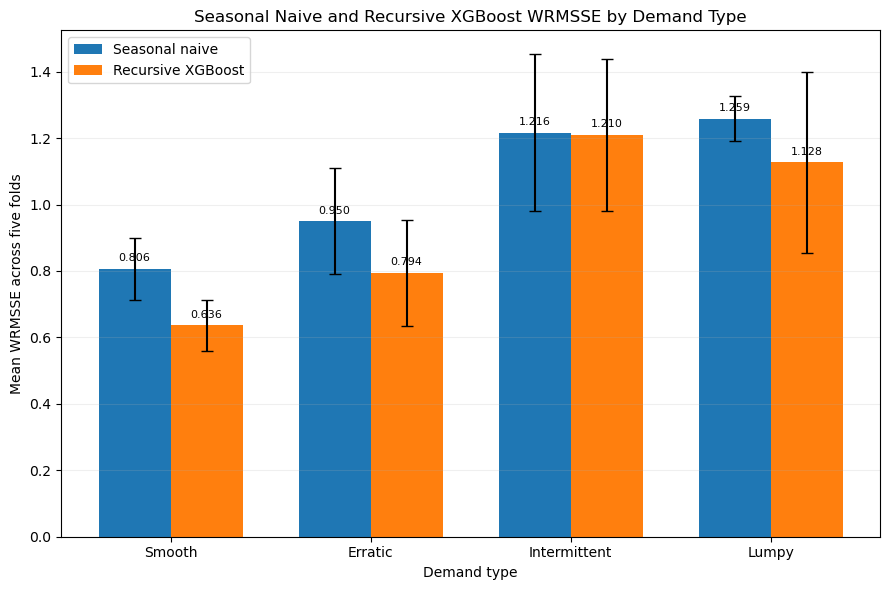

Saved: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_mean_wrmsse_by_demand_type.png


In [54]:
# Cell 49: Plot mean WRMSSE by model and demand type

import matplotlib.pyplot as plt

STEP16_FIGURE_DIR = FIGURE_DIR / "step16"

STEP16_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

plot_summary = (
    step16_report_summary
    .set_index(DEMAND_TYPE_COLUMN)
    .reindex(DEMAND_TYPES)
    .reset_index()
)

x_positions = np.arange(
    len(plot_summary)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(9, 6)
)

naive_bars = ax.bar(
    x_positions - bar_width / 2,
    plot_summary["mean_naive_wrmsse"],
    bar_width,
    yerr=plot_summary["std_naive_wrmsse"],
    capsize=4,
    label="Seasonal naive",
)

xgb_bars = ax.bar(
    x_positions + bar_width / 2,
    plot_summary["mean_xgb_wrmsse"],
    bar_width,
    yerr=plot_summary["std_xgb_wrmsse"],
    capsize=4,
    label="Recursive XGBoost",
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Mean WRMSSE across five folds")
ax.set_title(
    "Seasonal Naive and Recursive XGBoost "
    "WRMSSE by Demand Type"
)

ax.set_xticks(
    x_positions,
    [
        demand_type.capitalize()
        for demand_type in DEMAND_TYPES
    ],
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.2,
)

for bar_group in [
    naive_bars,
    xgb_bars,
]:
    for bar in bar_group:
        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(
                bar.get_x()
                + bar.get_width() / 2,
                height,
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

fig.tight_layout()

mean_wrmsse_figure = (
    STEP16_FIGURE_DIR
    / "step16_mean_wrmsse_by_demand_type.png"
)

fig.savefig(
    mean_wrmsse_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", mean_wrmsse_figure)

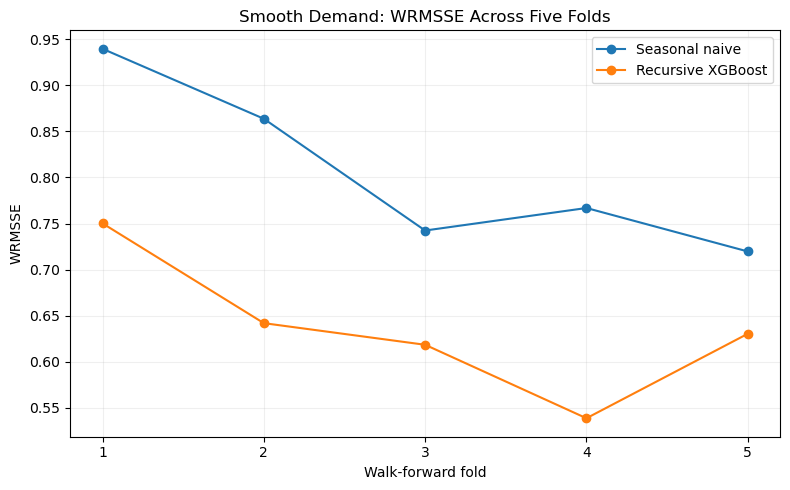

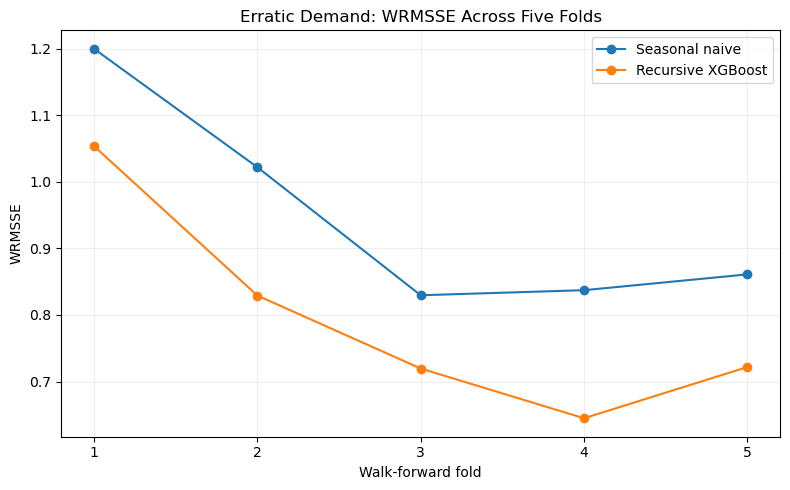

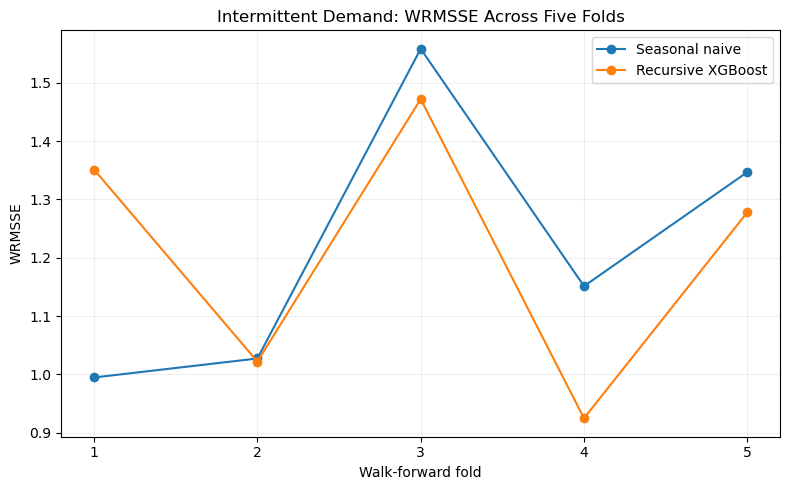

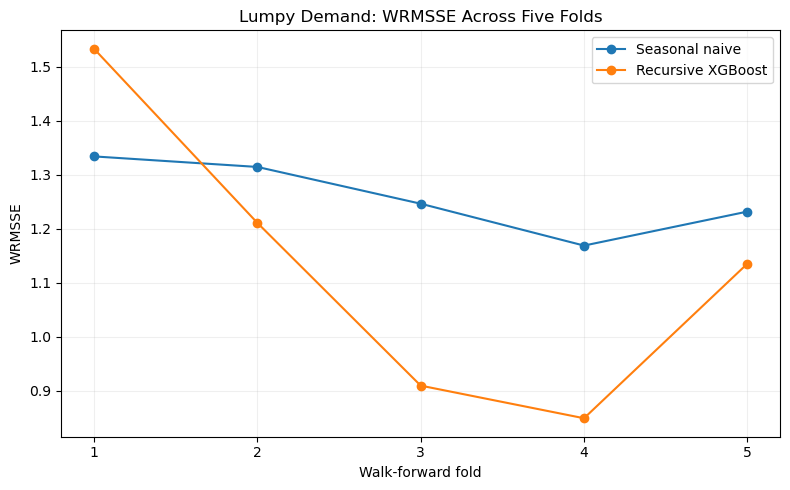

Saved fold-level figures:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_smooth_wrmsse_by_fold.png
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_erratic_wrmsse_by_fold.png
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_intermittent_wrmsse_by_fold.png
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_lumpy_wrmsse_by_fold.png


In [55]:
# Cell 50: Plot fold-level WRMSSE separately for each demand type

fold_figure_files = []

for demand_type in DEMAND_TYPES:
    demand_results = (
        final_xgb_results.loc[
            final_xgb_results[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .sort_values("fold")
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        demand_results["fold"],
        demand_results["naive_wrmsse"],
        marker="o",
        label="Seasonal naive",
    )

    ax.plot(
        demand_results["fold"],
        demand_results["xgb_wrmsse"],
        marker="o",
        label="Recursive XGBoost",
    )

    ax.set_xlabel("Walk-forward fold")
    ax.set_ylabel("WRMSSE")
    ax.set_title(
        f"{demand_type.capitalize()} Demand: "
        "WRMSSE Across Five Folds"
    )

    ax.set_xticks(
        demand_results["fold"]
    )

    ax.grid(alpha=0.2)
    ax.legend()

    fig.tight_layout()

    figure_file = (
        STEP16_FIGURE_DIR
        / (
            f"step16_{safe_file_label(demand_type)}"
            "_wrmsse_by_fold.png"
        )
    )

    fig.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    fold_figure_files.append(
        figure_file
    )

print("Saved fold-level figures:")

for figure_file in fold_figure_files:
    print(figure_file)

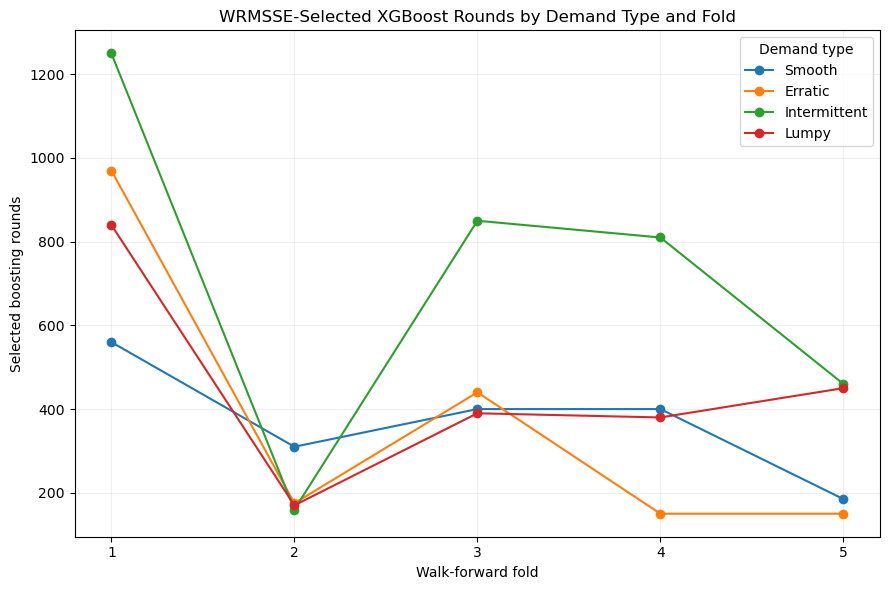

Saved: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step16\step16_selected_rounds_by_fold.png


In [56]:
# Cell 51: Plot selected boosting rounds by fold and demand type

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for demand_type in DEMAND_TYPES:
    round_data = (
        full_selection_summary.loc[
            full_selection_summary[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .sort_values("fold")
    )

    ax.plot(
        round_data["fold"],
        round_data["selected_rounds"],
        marker="o",
        label=demand_type.capitalize(),
    )

ax.set_xlabel("Walk-forward fold")
ax.set_ylabel("Selected boosting rounds")
ax.set_title(
    "WRMSSE-Selected XGBoost Rounds "
    "by Demand Type and Fold"
)

ax.set_xticks(
    sorted(
        full_selection_summary[
            "fold"
        ].unique()
    )
)

ax.grid(alpha=0.2)
ax.legend(title="Demand type")

fig.tight_layout()

rounds_figure = (
    STEP16_FIGURE_DIR
    / "step16_selected_rounds_by_fold.png"
)

fig.savefig(
    rounds_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", rounds_figure)

In [57]:
# Cell 52: Summarise hierarchy-level performance across folds

HIERARCHY_ORDER = {
    level_name: index
    for index, (
        level_name,
        _
    ) in enumerate(HIERARCHY_LEVELS)
}

step16_hierarchy_summary = (
    final_xgb_level_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "level",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_naive_level_wrmsse=(
            "naive_level_wrmsse",
            "mean",
        ),
        mean_xgb_level_wrmsse=(
            "xgb_level_wrmsse",
            "mean",
        ),
        xgb_better_folds=(
            "xgb_better",
            "sum",
        ),
    )
)

step16_hierarchy_summary[
    "mean_level_wrmsse_difference"
] = (
    step16_hierarchy_summary[
        "mean_naive_level_wrmsse"
    ]
    - step16_hierarchy_summary[
        "mean_xgb_level_wrmsse"
    ]
)

step16_hierarchy_summary[
    "demand_order"
] = (
    step16_hierarchy_summary[
        DEMAND_TYPE_COLUMN
    ].map(DEMAND_ORDER)
)

step16_hierarchy_summary[
    "hierarchy_order"
] = (
    step16_hierarchy_summary[
        "level"
    ].map(HIERARCHY_ORDER)
)

step16_hierarchy_summary = (
    step16_hierarchy_summary
    .sort_values(
        [
            "demand_order",
            "hierarchy_order",
        ]
    )
    .drop(
        columns=[
            "demand_order",
            "hierarchy_order",
        ]
    )
    .reset_index(drop=True)
)

display(
    step16_hierarchy_summary.round(6)
)

assert len(step16_hierarchy_summary) == 48
assert (
    step16_hierarchy_summary["folds"]
    == 5
).all()

step16_hierarchy_summary.to_csv(
    STEP16_TABLE_DIR
    / "step16_hierarchy_summary_by_demand_type.csv",
    index=False,
)

print("Hierarchy-level summary saved.")

,demand_type,level,folds,mean_naive_level_wrmsse,mean_xgb_level_wrmsse,xgb_better_folds,mean_level_wrmsse_difference
0,smooth,L1_Total,5,0.590936,0.483884,4,0.107052
1,smooth,L2_State,5,0.635142,0.539925,4,0.095216
2,smooth,L3_Store,5,0.768623,0.632208,5,0.136415
3,smooth,L4_Category,5,0.694855,0.551714,5,0.143141
4,smooth,L5_Department,5,0.727650,0.575191,5,0.152459
5,smooth,L6_State_Category,5,0.762351,0.615014,5,0.147337
6,smooth,L7_State_Department,5,0.790969,0.635407,5,0.155562
7,smooth,L8_Store_Category,5,0.866105,0.678081,5,0.188025
8,smooth,L9_Store_Department,5,0.891367,0.693929,5,0.197438
9,smooth,L10_Item,5,0.977543,0.735102,5,0.242441


Hierarchy-level summary saved.


In [58]:
# Cell 53: Final Step 16 completion and output audit

saved_model_files = sorted(
    MODEL_SAVE_DIR.glob(
        "xgb_fold*_*.ubj"
    )
)

required_step16_outputs = [
    STEP16_TABLE_DIR
    / "step16_inner_selection_summary.csv",

    STEP16_TABLE_DIR
    / "step16_inner_selection_trace.csv",

    STEP16_TABLE_DIR
    / "step16_xgb_fold_results.csv",

    STEP16_TABLE_DIR
    / "step16_xgb_level_results.csv",

    STEP16_TABLE_DIR
    / "step16_summary_by_demand_type.csv",

    STEP16_TABLE_DIR
    / "step16_report_summary_by_demand_type.csv",

    STEP16_TABLE_DIR
    / "step16_wrmsse_underperformance_folds.csv",

    STEP16_TABLE_DIR
    / "step16_hierarchy_summary_by_demand_type.csv",

    STEP16_TABLE_DIR
    / "step16_configuration.json",

    MODEL_RESULTS_DIR
    / "step16_xgb_predictions.parquet",

    STEP16_FIGURE_DIR
    / "step16_mean_wrmsse_by_demand_type.png",

    STEP16_FIGURE_DIR
    / "step16_selected_rounds_by_fold.png",
]

required_step16_outputs.extend(
    fold_figure_files
)

missing_step16_outputs = [
    path
    for path in required_step16_outputs
    if not path.exists()
]

step16_completion_checks = {
    "20 inner selections validated": (
        len(full_selection_summary) == 20
        and full_selection_summary[
            "selection_valid"
        ].all()
    ),

    "20 final fold-type results": (
        len(final_xgb_results) == 20
    ),

    "112,000 final predictions": (
        len(final_xgb_predictions)
        == 112_000
    ),

    "240 hierarchy-level results": (
        len(final_xgb_level_results)
        == 240
    ),

    "4 demand-type report rows": (
        len(step16_report_summary) == 4
    ),

    "48 hierarchy summary rows": (
        len(step16_hierarchy_summary)
        == 48
    ),

    "20 saved XGBoost models": (
        len(saved_model_files) == 20
    ),

    "No required output missing": (
        len(missing_step16_outputs) == 0
    ),

    "No missing final forecasts": (
        final_xgb_predictions[
            "xgb_forecast"
        ].isna().sum() == 0
    ),

    "No negative final forecasts": (
        (
            final_xgb_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),

    "All baseline scores reproduced": (
        final_xgb_results[
            "naive_reproduction_difference"
        ].max() < 1e-10
    ),

    "XGBoost improved MAE in all 20 comparisons": (
        final_xgb_results[
            "xgb_better_mae"
        ].all()
    ),

    "XGBoost improved RMSE in all 20 comparisons": (
        final_xgb_results[
            "xgb_better_rmse"
        ].all()
    ),
}

step16_completion_table = pd.DataFrame(
    {
        "check": (
            step16_completion_checks.keys()
        ),
        "passed": (
            step16_completion_checks.values()
        ),
    }
)

display(step16_completion_table)

if missing_step16_outputs:
    print("Missing outputs:")

    for path in missing_step16_outputs:
        print(path)

failed_completion_checks = [
    check
    for check, passed
    in step16_completion_checks.items()
    if not passed
]

if failed_completion_checks:
    raise AssertionError(
        "Step 16 completion audit failed:\n- "
        + "\n- ".join(
            failed_completion_checks
        )
    )

step16_completion_table.to_csv(
    STEP16_TABLE_DIR
    / "step16_completion_audit.csv",
    index=False,
)

print("Step 16 completion audit passed.")
print(
    f"Saved models: "
    f"{len(saved_model_files)}"
)
print(
    f"Required output files checked: "
    f"{len(required_step16_outputs)}"
)
print(
    "WRMSSE fold-type comparisons won: "
    f"{(final_xgb_results['wrmsse_difference'] > 0).sum()} "
    f"of {len(final_xgb_results)}"
)
print(
    "MAE comparisons won: "
    f"{final_xgb_results['xgb_better_mae'].sum()} "
    f"of {len(final_xgb_results)}"
)
print(
    "RMSE comparisons won: "
    f"{final_xgb_results['xgb_better_rmse'].sum()} "
    f"of {len(final_xgb_results)}"
)

,check,passed
0,20 inner selections validated,True
1,20 final fold-type results,True
2,"112,000 final predictions",True
3,240 hierarchy-level results,True
4,4 demand-type report rows,True
5,48 hierarchy summary rows,True
6,20 saved XGBoost models,True
7,No required output missing,True
8,No missing final forecasts,True
9,No negative final forecasts,True


Step 16 completion audit passed.
Saved models: 20
Required output files checked: 16
WRMSSE fold-type comparisons won: 18 of 20
MAE comparisons won: 20 of 20
RMSE comparisons won: 20 of 20
